# Hatteras Island CASCADE Hindcast
Step through each section, run it, look at the plot, confirm it's right before moving on.
Single configuration only (one `START_YEAR`, one `Hs`) — the sensitivity sweep stays in `HAT_groin_sensitivity_sweep.py`.

Pseudocode only below — move your own working code in from `HAT_hindcast_1984_2024_groinTest.py` section by section. Line numbers referenced are from that file.

## 1. Imports

In [1]:
import base64
import os
import sys
from pathlib import Path

# cascade_pipeline and hatteras_site_config live in scripts/, which isn't installed
_here = Path.cwd().resolve()
_repo_root = next((p for p in (_here, *_here.parents) if (p / "pyproject.toml").exists()), None)
if _repo_root is None:
    raise RuntimeError(f"CASCADE repo root not found above {_here}")
SCRIPTS_DIR = _repo_root / "scripts"
# HAT_hindcast_config lives in scripts/hatteras_ms/ beside the runner. The .py
# gets that directory on sys.path for free; the notebook has to add it, and
# both files must reach the module the same way.
HATTERAS_MS_DIR = SCRIPTS_DIR / "hatteras_ms"
for _path in (SCRIPTS_DIR, HATTERAS_MS_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# True: sandbox copy with the pre-AST groin hook. False: real package, hook folded in.
USE_SANDBOX_CASCADE = True
if USE_SANDBOX_CASCADE:
    from cascade.cascade_groin import Cascade
else:
    from cascade.cascade import Cascade

from cascade_pipeline.annotations import AnnotationConfig
from cascade_pipeline.coastsat_loess import (
    DEFAULT_LOESS,
    CoastSatDataset,
    LoessConfig,
    build_coastsat_series,
)
from cascade_pipeline.plotting.rate_comparison import (
    plot_annotated_rate_comparison,
    plot_rate_comparison,
)
from cascade_pipeline.plotting.shoreline_gif import (
    GifConfig,
    make_all_shoreline_gifs,
    make_shoreline_gif,
)
from cascade_pipeline.run_info import RunInfo
from cascade_pipeline.run_registry import (
    append_run_index,
    git_provenance,
    guard_run_dir,
    run_dir_contents,
    skill_vs_target,
    values_digest,
    timestamp,
    RUN_INDEX_FILENAME,
    write_run_metadata,
)
from cascade_pipeline.shoreline import build_shoreline_matrix, compute_change_rate
import PIL.Image
from IPython.display import HTML, display

from hatteras_site_config import (
    HATTERAS_ANNOTATIONS,
    HATTERAS_BE_PRESETS,
    HATTERAS_BE_EDGE_DOMAINS,
    HATTERAS_BE_RATES_2004_IS_PLACEHOLDER,
    HATTERAS_DOMAINS,
    HATTERAS_PERIODS,
    resolve_be_preset,
)

print(f"Imports OK from {SCRIPTS_DIR}")
print(f"USE_SANDBOX_CASCADE = {USE_SANDBOX_CASCADE}")
print(f"HATTERAS_DOMAINS.total_domains = {HATTERAS_DOMAINS.total_domains}")


Imports OK from C:\Users\hanna\PycharmProjects\CASCADE\scripts
USE_SANDBOX_CASCADE = True
HATTERAS_DOMAINS.total_domains = 120


## 2. Fixed dune/topo (period-independent) — QC plot
Same 2009 init surface for both periods, doesn't depend on `START_YEAR`.

Broken into steps so each can be confirmed before moving on:

| Step | What it does | What to check |
| --- | --- | --- |
| 2.1 | Resolve project paths | printed dirs all say `ok` |
| 2.2 | Build the 120 padded file paths | buffer/real/buffer order, 120 each |
| 2.3 | Verify every file exists | no exception |
| 2.4 | Units check vs Barrier3D contract | every check reports 90/90 |
| 2.5 | Browse per-domain extractor figures | dune picks and water trim, domain by domain |

### 2.1 Project paths

Everything derives from `SCRIPTS_DIR` (Section 1), so no absolute paths are
hardcoded. Layout under `data/hatteras_init/1-barrier3d-domains/`:

```
2009-dune-topo/<version>/topography/domain_<gis>_topography_<year>.npy
2009-dune-topo/<version>/dunes/domain_<gis>_dune_<year>.npy
2009-buffer/sample_1_topography.npy      # one profile, reused by every buffer
2009-buffer/sample_1_dune.npy
```

`TOPO_DUNE_VERSION` is **resolved, not pinned**: `topo_dirs()` reads `VERSION`
out of `HAT_dune_topo_extractor.py`, so the runner, the dune-start road
setbacks and the audits always describe the same extraction. Bump `VERSION` in
the extractor and everything follows; pass `topo_dirs(override="2009_v3")` to
reproduce an older run on purpose.

It has to work that way. The setback is measured from interior row 0, so a
runner pinned to one extraction while the setbacks are built on another places
the road against a row that does not exist on the grid being run. That is
exactly what happened from 2026-08-19, when the setbacks moved to `2009_v4` and
then `2009_v5` while this pin stayed on `2009_v3`.

`2009_v1` and `2009_v2` are in `2009-dune-topo/incorrect/`; `topo_dirs()` raises
if the resolved version is not on disk, before the check in 2.3 runs.

In [2]:
TOPO_DUNE_INIT_YEAR = "2009"     # year label inside the filenames

# WHICH EXTRACTION -- resolved, not pinned. topo_dirs() reads VERSION out of
# HAT_dune_topo_extractor.py, so the runner, the dune-start road setbacks and
# the audits always describe the same extraction, and a version missing from
# disk is a loud error rather than a silently stale read.
#
# Pinning it by hand is what let this runner sit on 2009_v3 while the setbacks
# were rebuilt on v4 (2026-08-19) and then v5 (2026-08-20). The setback is
# measured from interior row 0, so that combination places the road against a
# row that does not exist on the grid being run.
#
# To reproduce an older run deliberately: topo_dirs(override="2009_v3").
from hat_topo_version import topo_dirs   # scripts/, on sys.path from section 1

_TOPO_DIR, _DUNE_DIR, TOPO_DUNE_VERSION = topo_dirs()
print(f"topography            {TOPO_DUNE_VERSION}  (resolved from the extractor)")

PROJECT_BASE_DIR = SCRIPTS_DIR.parent
HATTERAS_DATA_BASE = PROJECT_BASE_DIR / "data" / "hatteras_init"
OUTPUT_ROOT = PROJECT_BASE_DIR / "output" / "raw_runs"
COASTSAT_BASE_DIR = (PROJECT_BASE_DIR / "scripts" / "input_prep"
                     / "5-scr" / "CoastSat")
PARAMETER_FILE = "Hatteras-CASCADE-parameters.yaml"  # resolved by CASCADE

BARRIER3D_DIR = HATTERAS_DATA_BASE / "1-barrier3d-domains"
DUNE_TOPO_DIR = BARRIER3D_DIR / "2009-dune-topo" / TOPO_DUNE_VERSION
BUFFER_DIR = BARRIER3D_DIR / "2009-buffer"

os.chdir(PROJECT_BASE_DIR)
# Runs are filed per period: section 3 builds OUTPUT_BASE_DIR =
# OUTPUT_ROOT / "<start>_<end>" once START_YEAR is expanded, so a
# 1984-2004 run and a 2004-2024 run of one scenario cannot land beside
# each other. run_index.csv stays at the root, covering both periods.
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

for _name, _path in [
    ("PROJECT_BASE_DIR", PROJECT_BASE_DIR),
    ("HATTERAS_DATA_BASE", HATTERAS_DATA_BASE),
    ("DUNE_TOPO_DIR", DUNE_TOPO_DIR),
    ("BUFFER_DIR", BUFFER_DIR),
    ("COASTSAT_BASE_DIR", COASTSAT_BASE_DIR),
    ("OUTPUT_ROOT", OUTPUT_ROOT),
]:
    print(f"{_name:<20} {'ok' if _path.exists() else 'MISSING':<8} {_path}")

PROJECT_BASE_DIR     ok       C:\Users\hanna\PycharmProjects\CASCADE
HATTERAS_DATA_BASE   ok       C:\Users\hanna\PycharmProjects\CASCADE\data\hatteras_init
DUNE_TOPO_DIR        ok       C:\Users\hanna\PycharmProjects\CASCADE\data\hatteras_init\1-barrier3d-domains\2009-dune-topo\2009_v3
BUFFER_DIR           ok       C:\Users\hanna\PycharmProjects\CASCADE\data\hatteras_init\1-barrier3d-domains\2009-buffer
COASTSAT_BASE_DIR    ok       C:\Users\hanna\PycharmProjects\CASCADE\scripts\input_prep\5-scr\CoastSat
OUTPUT_ROOT          ok       C:\Users\hanna\PycharmProjects\CASCADE\output\raw_runs


### 2.2 Build the padded file lists

CASCADE takes one elevation file and one dune file per padded domain, in
alongshore order: 15 buffers, then real GIS 1–90, then 15 buffers (120 total).
Both buffer ends reuse the same sample profile, so only the real domains vary.

The returned lists are index-aligned with the padded array, so
`HATTERAS_DOMAINS.gis_to_pad(gis_id)` indexes straight into them.

In [3]:
def build_domain_file_paths(geometry, dune_topo_dir, buffer_dir, init_year):
    """Builds one elevation and one dune file path per padded domain.

    Args:
        geometry: DomainGeometry describing the padded domain array.
        dune_topo_dir: Directory holding the topography/ and dunes/ subdirs.
        buffer_dir: Directory holding the buffer sample profiles.
        init_year: Year label embedded in the real-domain filenames.

    Returns:
        An (elevation_paths, dune_paths) tuple of string lists. Each list is
        geometry.total_domains long and index-aligned with the padded array.
    """
    buffer_elevation = str(buffer_dir / "sample_1_topography.npy")
    buffer_dune = str(buffer_dir / "sample_1_dune.npy")

    elevation_paths = [buffer_elevation] * geometry.num_buffer_domains
    dune_paths = [buffer_dune] * geometry.num_buffer_domains

    for gis_id in range(geometry.first_gis_id, geometry.last_gis_id + 1):
        elevation_paths.append(str(
            dune_topo_dir / "topography"
            / f"domain_{gis_id}_topography_{init_year}.npy"))
        dune_paths.append(str(
            dune_topo_dir / "dunes"
            / f"domain_{gis_id}_dune_{init_year}.npy"))

    elevation_paths += [buffer_elevation] * geometry.num_buffer_domains
    dune_paths += [buffer_dune] * geometry.num_buffer_domains

    return elevation_paths, dune_paths


ELEVATION_FILE_PATHS, DUNE_FILE_PATHS = build_domain_file_paths(
    HATTERAS_DOMAINS, DUNE_TOPO_DIR, BUFFER_DIR, TOPO_DUNE_INIT_YEAR)

_first_real = HATTERAS_DOMAINS.start_real_index
_last_real = HATTERAS_DOMAINS.end_real_index - 1

print(f"{len(ELEVATION_FILE_PATHS)} elevation + {len(DUNE_FILE_PATHS)} dune "
      f"paths (expect {HATTERAS_DOMAINS.total_domains} each)\n")
print("Padded array boundaries:")
for _label, _pad in [
    ("pad 0 (buffer)", 0),
    (f"pad {_first_real} (GIS {HATTERAS_DOMAINS.first_gis_id})", _first_real),
    (f"pad {_last_real} (GIS {HATTERAS_DOMAINS.last_gis_id})", _last_real),
    (f"pad {HATTERAS_DOMAINS.total_domains - 1} (buffer)",
     HATTERAS_DOMAINS.total_domains - 1),
]:
    print(f"  {_label:<22} {Path(ELEVATION_FILE_PATHS[_pad]).name}")

120 elevation + 120 dune paths (expect 120 each)

Padded array boundaries:
  pad 0 (buffer)         sample_1_topography.npy
  pad 15 (GIS 1)         domain_1_topography_2009.npy
  pad 104 (GIS 90)       domain_90_topography_2009.npy
  pad 119 (buffer)       sample_1_topography.npy


### 2.3 Verify every file exists

Checks all 240 paths up front. A stale `TOPO_DUNE_VERSION` or a moved data
folder fails here with a count and the first offender, rather than surfacing
as an empty plot or an opaque traceback inside Barrier3D's init.

In [4]:
_expected_files = 2 * HATTERAS_DOMAINS.total_domains
_missing = [path for path in ELEVATION_FILE_PATHS + DUNE_FILE_PATHS
            if not Path(path).exists()]

if _missing:
    raise FileNotFoundError(
        f"{len(_missing)} of {_expected_files} init files missing. Check "
        f"TOPO_DUNE_VERSION ({TOPO_DUNE_VERSION!r}) and DUNE_TOPO_DIR.\n"
        f"  First missing: {_missing[0]}")

print(f"All {_expected_files} init files present.")

All 240 init files present.


### 2.4 Units check against Barrier3D's input contract

Barrier3D's `load_input.py` converts the *scalar* YAML parameters but loads the
elevation and dune `.npy` files **verbatim** — `InteriorDomain` is whatever the
file contains, with no unit conversion applied:

```python
params["MHW"] /= 10.0                                  # m   -> dam
params["BarrierLength"] = int(params["BarrierLength"] / 10.0)   # m -> cells
params["BermEl"] = params["BermEl"] / 10.0 - params["MHW"]      # m -> dam above MHW
params["InteriorDomain"] = load_elevation(...)         # <- no conversion
```

So the arrays on disk must *already* be in decameters relative to MHW. A file
written in metres would run without error and silently model an island 10x too
tall. This step verifies that, plus the shape contract `load_input.py` relies
on, across all 90 real domains — deliberately on the **raw** arrays, before any
`DAM_TO_M` scaling.

What `load_input.py` assumes:

- `InteriorDomain.shape[1]` is alongshore. If it exceeds `BarrierLength` the
  array is silently truncated; if it is smaller, `BarrierLength` is silently
  reduced to match. Either way the mismatch is never reported.
- `DuneStart` is sliced `[0:BarrierLength]`, so the dune array must be at
  least that long.
- Dune values are heights *above the berm*, not elevations
  (`newDuneHeight = newDuneElev - BermEl`), so they must be positive.

In [5]:
import yaml

WATER_CLAMP_DAM = -0.3   # SENTINEL_WATER_M / WATER_CLAMP_M from RUN_MANIFEST.txt
MAX_PLAUSIBLE_DAM = 2.0  # 20 m; a barrier island in metres would blow past this


def load_barrier3d_contract(parameter_path):
    """Reads the unit-relevant Barrier3D parameters from the CASCADE YAML.

    Mirrors the conversions in barrier3d/load_input.py so the values can be
    compared against the raw arrays on disk.

    Args:
        parameter_path: Path to the CASCADE parameter YAML.

    Returns:
        A dict with barrier_length_cells, mhw_dam and berm_el_dam.
    """
    with open(parameter_path, encoding="utf-8") as handle:
        params = yaml.safe_load(handle)

    mhw_dam = params["MHW"] / 10.0
    return {
        "barrier_length_cells": int(params["BarrierLength"] / 10.0),
        "mhw_dam": mhw_dam,
        "berm_el_dam": params["BermEl"] / 10.0 - mhw_dam,
    }


def check_domain_units(elevation_dam, dune_dam, contract):
    """Checks one domain's raw arrays against the Barrier3D input contract.

    Args:
        elevation_dam: Raw elevation array as stored on disk.
        dune_dam: Raw dune array as stored on disk.
        contract: Mapping from load_barrier3d_contract.

    Returns:
        A dict of check name -> bool, True when the array satisfies the check.
    """
    alongshore_cells = (elevation_dam.shape[1] if elevation_dam.ndim == 2
                        else None)
    return {
        "elevation is 2-D (cross_shore, alongshore)": elevation_dam.ndim == 2,
        "dune is 1-D (one crest per alongshore cell)": dune_dam.ndim == 1,
        "alongshore cells match dune length":
            alongshore_cells == dune_dam.size,
        f"alongshore >= BarrierLength ({contract['barrier_length_cells']})":
            alongshore_cells is not None
            and alongshore_cells >= contract["barrier_length_cells"],
        "dtype is floating point":
            np.issubdtype(elevation_dam.dtype, np.floating)
            and np.issubdtype(dune_dam.dtype, np.floating),
        "magnitudes are decameters, not metres":
            np.abs(elevation_dam).max() <= MAX_PLAUSIBLE_DAM,
        f"seaward floor at water clamp ({WATER_CLAMP_DAM} dam)":
            np.isclose(elevation_dam.min(), WATER_CLAMP_DAM),
        "dune heights positive (above berm)": dune_dam.min() > 0,
    }


BARRIER3D_CONTRACT = load_barrier3d_contract(HATTERAS_DATA_BASE / PARAMETER_FILE)

print(f"Contract from {PARAMETER_FILE}:")
print(f"  BarrierLength -> {BARRIER3D_CONTRACT['barrier_length_cells']} "
      f"alongshore cells")
print(f"  MHW           -> {BARRIER3D_CONTRACT['mhw_dam']:.3f} dam")
print(f"  BermEl        -> {BARRIER3D_CONTRACT['berm_el_dam']:.3f} dam "
      f"above MHW\n")

_results = {}
for _gis_id in range(HATTERAS_DOMAINS.first_gis_id,
                     HATTERAS_DOMAINS.last_gis_id + 1):
    _pad = HATTERAS_DOMAINS.gis_to_pad(_gis_id)
    _checks = check_domain_units(np.load(ELEVATION_FILE_PATHS[_pad]),
                                 np.load(DUNE_FILE_PATHS[_pad]),
                                 BARRIER3D_CONTRACT)
    for _name, _passed in _checks.items():
        _results.setdefault(_name, []).append((_gis_id, _passed))

print(f"{'Check':<46} {'domains passing':>15}")
_failed_any = False
for _name, _outcomes in _results.items():
    _failures = [gis_id for gis_id, passed in _outcomes if not passed]
    _failed_any = _failed_any or bool(_failures)
    print(f"  {_name:<44} {len(_outcomes) - len(_failures):>6}"
          f"/{len(_outcomes)}"
          + (f"   FAILED: {_failures[:8]}" if _failures else ""))

print("\n" + ("SOME CHECKS FAILED - do not run the model on these arrays"
               if _failed_any else
               "All units and shapes match what Barrier3D expects."))

Contract from Hatteras-CASCADE-parameters.yaml:
  BarrierLength -> 50 alongshore cells
  MHW           -> 0.036 dam
  BermEl        -> 0.134 dam above MHW

Check                                          domains passing
  elevation is 2-D (cross_shore, alongshore)       90/90
  dune is 1-D (one crest per alongshore cell)      90/90
  alongshore cells match dune length               90/90
  alongshore >= BarrierLength (50)                 90/90
  dtype is floating point                          90/90
  magnitudes are decameters, not metres            90/90
  seaward floor at water clamp (-0.3 dam)          90/90
  dune heights positive (above berm)               90/90

All units and shapes match what Barrier3D expects.


### 2.5 Browse the extractor's per-domain figures

2.4 samples five domains. This steps through all 90 using the figures
`HAT_dune_topo_extractor.py` wrote alongside the arrays, so a bad dune pick or
a mis-trimmed water edge is visible domain by domain.

Two sets are available, both under `<version>/figures/`:

- **`gis_vs_processed`** — three panels: raw GIS input (m NAVD88), the
  straightened picking frame with the dune search window and picked crest, and
  the processed CASCADE input actually written to disk, with the dune-height
  strip below. This is the one that shows what the extractor *did*.
- **`qc`** — the dune-detection QC panel for the same domain.

Drag the slider or focus it and use the arrow keys to cycle. The figure title
carries that domain's settings (search window, dunes found, mean dune height,
obliquity), which match the row for that domain in
`HAT_dune_topo_settings_<version>.csv`.

Note: `ipywidgets` is imported here rather than in Section 1 because it is an
optional dependency used only by this step — if it is missing, the rest of the
notebook still runs and you can call `show_domain_figure(gis_id)` directly.

In [6]:
FIGURES_DIR = DUNE_TOPO_DIR / "figures"
FIGURE_SETS = {
    "gis_vs_processed": "domain_{gis_id:03d}_gis_vs_processed.png",
    "qc": "domain_{gis_id:03d}_qc.png",
}
FIGURE_DISPLAY_WIDTH = 650  # rendered width; source PNGs are ~2060 px


def domain_figure_path(gis_id, figure_set):
    """Builds the path to one domain's extractor QC figure.

    Args:
        gis_id: GIS domain ID.
        figure_set: Key of FIGURE_SETS naming which figure set to use.

    Returns:
        A pathlib.Path to the PNG for that domain.

    Raises:
        KeyError: If figure_set is not a key of FIGURE_SETS.
        FileNotFoundError: If no figure exists for that domain.
    """
    filename = FIGURE_SETS[figure_set].format(gis_id=gis_id)
    path = FIGURES_DIR / figure_set / filename
    if not path.exists():
        raise FileNotFoundError(f"No {figure_set} figure for GIS {gis_id}: {path}")
    return path


def show_domain_figure(gis_id, figure_set="gis_vs_processed",
                       width=FIGURE_DISPLAY_WIDTH):
    """Displays one domain's extractor QC figure inline, downscaled to width.

    IPython.display.Image embeds local files and passes width only as output
    metadata, which some frontends ignore -- so the image is resampled to the
    requested width instead of being tagged with it.

    Args:
        gis_id: GIS domain ID.
        figure_set: Key of FIGURE_SETS naming which figure set to use.
        width: Display width in pixels.
    """
    path = domain_figure_path(gis_id, figure_set)
    with PIL.Image.open(path) as figure:
        height = round(figure.height * width / figure.width)
        preview = figure.convert("RGB").resize((width, height))

    print(f"GIS {gis_id}  ->  {path.name}  ({width}x{height} px)")
    display(preview)


for _figure_set in FIGURE_SETS:
    _missing = [gis_id
                for gis_id in range(HATTERAS_DOMAINS.first_gis_id,
                                    HATTERAS_DOMAINS.last_gis_id + 1)
                if not (FIGURES_DIR / _figure_set
                        / FIGURE_SETS[_figure_set].format(gis_id=gis_id)).exists()]
    print(f"{_figure_set:<18} "
          f"{HATTERAS_DOMAINS.num_real_domains - len(_missing)}"
          f"/{HATTERAS_DOMAINS.num_real_domains} figures"
          + (f"  MISSING: {_missing}" if _missing else ""))

try:
    import ipywidgets as widgets

    widgets.interact(
        show_domain_figure,
        gis_id=widgets.IntSlider(
            min=HATTERAS_DOMAINS.first_gis_id,
            max=HATTERAS_DOMAINS.last_gis_id,
            value=HATTERAS_DOMAINS.first_gis_id,
            step=1,
            description="GIS domain",
            continuous_update=False),
        figure_set=widgets.Dropdown(
            options=list(FIGURE_SETS),
            value="gis_vs_processed",
            description="figure set"),
        width=widgets.fixed(FIGURE_DISPLAY_WIDTH),
    )
except ImportError:
    print("\nipywidgets not installed -- call show_domain_figure(gis_id) "
          "directly, e.g. show_domain_figure(45)")

gis_vs_processed   90/90 figures
qc                 90/90 figures


interactive(children=(IntSlider(value=1, continuous_update=False, description='GIS domain', max=90, min=1), Dr…

## 3. Island orientation — set `START_YEAR`

`START_YEAR` is the one flip in this notebook. It selects a period from
`HATTERAS_PERIODS` (in `hatteras_site_config.py`), and everything in Section 4
follows from it: run length, RSLR rate, storm series, background-erosion
preset, plus the road-setback and nourishment settings used later.

The island offset is what "orientation" means here — one value per padded
domain giving that domain's cross-shore starting position. It becomes
`shoreline_offset` on the `Cascade()` call, so it sets where the shoreline
starts, and a wrong `START_YEAR` shows up as the wrong island shape.

### `SCENARIO` — the one place a run is defined

The cell below is where you choose what to simulate. `SCENARIO` names a
management combination and expands to the four `ENABLE_*` switches that
sections 5 and 6 read:

| `SCENARIO` | roadway | beach/dune | fills | what it isolates |
|---|---|---|---|---|
| `natural` | off | off | off | the counterfactual |
| `roadway_only` | **on** | off | off | the NC-12 program alone |
| `beachdune_only` | off | **on** | **on** | the beach program alone |
| `full_management` | **on** | **on** | **on** | the status-quo hindcast |
| `full_no_fill` | **on** | **on** | off | the fill, against `full_management` |

`GROIN_ENABLED` sits in the same cell but outside the table, because §12.3
measures the groin against a paired no-groin baseline identical in every other
token. Every scenario is run twice: `False` first to write the baseline, then
`True`.

Named scenarios are the intended route, but the commented override lines below
them let you depart for a single run. A departure is detected and printed, and
the run name follows the **switches**, never the label — so an overridden run
cannot be filed under the scenario it departed from.

Two combinations cannot both hold, and are resolved in the cell rather than
left to fail later: fills need a `beach_dune_manager` to spend them, and a
relocation event needs a `roadway_manager` to read the setback it moves.

The cell prints the run name it will produce. That preview is advisory — §7.5
derives the real name from the modules sections 5 and 6 actually built and
raises if the two disagree, so a switch that fails to reach its module is an
error rather than a mislabelled directory.


In [8]:
from cascade_pipeline import nourishment
from hatteras_site_config import HATTERAS_NOURISHMENT_PROJECTS

# The run-selecting values in this section come from HAT_hindcast_config, so a
# driver can set them through the environment without editing tracked source.
# Interactively, type over any assignment below -- the imported value is only
# the default, and the assignment is still the last word.

from HAT_hindcast_config import RUN_CONFIG
from HAT_hindcast_config import describe as _describe_run_config

START_YEAR = RUN_CONFIG.start_year   # 1984 or 2004

# The source/sink axis of the run matrix. Each name states a hypothesis about
# where the alongshore sediment budget is unresolved:
#   "zeroBE"   nothing imposed anywhere
#   "edgeBE"   only the two end domains, absorbing the open-boundary artifact
#   "calibBE"  the full per-domain fit against the CoastSat LRR
SOURCE_SINK_PRESET = RUN_CONFIG.source_sink_preset

# =============================================================================
# SCENARIO -- the management combination this run simulates
# =============================================================================
# The management axis of the run matrix, named rather than typed as four
# booleans, so a scenario is chosen in one word and cannot be assembled wrong
# by accident. What each switch controls:
#
#   roadway      roadway_manager: bulldozing, dune rebuild to the design
#                elevation, setback tracking, road drowning. Off leaves NC-12
#                as forcing that nothing acts on -- still loaded, still
#                audited in 5.1, never handed to a RoadwayManager.
#   beach_dune   beach_dune_manager, module and all: overwash filtering, the
#                fixed dune line (dune_migration_on = False), the 50 m
#                community-width drowning check, and fills. Off is the ONLY
#                way to get natural shoreline behaviour in the village
#                domains -- see the section 6 markdown on what is always-on.
#   fills        Within an enabled beach_dune_manager, whether the historical
#                fill is actually spent. False leaves the module and its
#                footprint exactly as they are, so a fills-on / fills-off pair
#                differs in the fill and nothing else.
#   relocations  Historical NC-12 relocation events. False in every named
#                scenario; read 5.1 before overriding it on.
SCENARIOS = {
    # nothing human acts on the island: the counterfactual
    "natural": dict(roadway=False, beach_dune=False,
                    fills=False, relocations=False),
    # NC-12 defended, villages left to behave naturally
    "roadway_only": dict(roadway=True, beach_dune=False,
                         fills=False, relocations=False),
    # villages managed and nourished, the road passive
    "beachdune_only": dict(roadway=False, beach_dune=True,
                           fills=True, relocations=False),
    # everything: the status-quo hindcast
    "full_management": dict(roadway=True, beach_dune=True,
                            fills=True, relocations=False),
    # everything except the sand -- isolates the fills against full_management
    "full_no_fill": dict(roadway=True, beach_dune=True,
                         fills=False, relocations=False),
}

SCENARIO = RUN_CONFIG.scenario

# The groin is NOT part of the scenario, deliberately. 12.3 measures its effect
# against a paired no-groin baseline identical in every other token, so every
# scenario is run twice -- False first to create the baseline, then True.
# Folding it into the table would double the table to say the same thing.
GROIN_ENABLED = RUN_CONFIG.groin_enabled

print("\n" + _describe_run_config())

# --- expand ------------------------------------------------------------------
if SCENARIO not in SCENARIOS:
    raise ValueError(f"SCENARIO must be one of {sorted(SCENARIOS)}, "
                     f"got {SCENARIO!r}")
_SCENARIO_PRESET = SCENARIOS[SCENARIO]
ENABLE_ROADWAY_MANAGEMENT = _SCENARIO_PRESET["roadway"]
ENABLE_BEACH_DUNE_MANAGEMENT = _SCENARIO_PRESET["beach_dune"]
ENABLE_NOURISHMENT_FILLS = _SCENARIO_PRESET["fills"]
ENABLE_HISTORICAL_ROAD_RELOCATIONS = _SCENARIO_PRESET["relocations"]

# --- one-off overrides -------------------------------------------------------
# Uncomment to depart from the named scenario for a single run. The departure
# is detected and printed below, and the run name is still derived from the
# switches rather than from SCENARIO, so an overridden run cannot be filed
# under the scenario label it departed from.
# ENABLE_ROADWAY_MANAGEMENT = False
# ENABLE_BEACH_DUNE_MANAGEMENT = False
# ENABLE_NOURISHMENT_FILLS = False
# ENABLE_HISTORICAL_ROAD_RELOCATIONS = True

_SCENARIO_DEPARTURES = {
    key: (want, got) for key, want, got in (
        ("roadway", _SCENARIO_PRESET["roadway"], ENABLE_ROADWAY_MANAGEMENT),
        ("beach_dune", _SCENARIO_PRESET["beach_dune"],
         ENABLE_BEACH_DUNE_MANAGEMENT),
        ("fills", _SCENARIO_PRESET["fills"], ENABLE_NOURISHMENT_FILLS),
        ("relocations", _SCENARIO_PRESET["relocations"],
         ENABLE_HISTORICAL_ROAD_RELOCATIONS),
    ) if want != got
}

DAM_TO_M = 10.0   # Barrier3D works in decameters

if START_YEAR not in HATTERAS_PERIODS:
    raise ValueError(f"START_YEAR must be one of {sorted(HATTERAS_PERIODS)}, "
                     f"got {START_YEAR}")

# Normalised to the canonical key. The deprecated aliases ("base",
# "calibrated") still run, but it is the canonical name that reaches
# RUN_NAME in 7.5 -- an alias can never put a stale token in a directory name.
SOURCE_SINK_PRESET, _PRESET_BY_PERIOD = resolve_be_preset(SOURCE_SINK_PRESET)

PERIOD = HATTERAS_PERIODS[START_YEAR]
END_YEAR = PERIOD["end_year"]
RUN_YEARS = END_YEAR - START_YEAR

SEA_LEVEL_RISE_RATE = PERIOD["sea_level_rise_rate"]
ENABLE_NOURISHMENT = PERIOD["enable_nourishment"]
NOURISHMENT_VOLUME = PERIOD["nourishment_volume"]
ISLAND_OFFSET_FILE = HATTERAS_DATA_BASE / PERIOD["island_offset_file"]
STORM_FILE = HATTERAS_DATA_BASE / PERIOD["storm_file"]
ROAD_SETBACK_FILE = HATTERAS_DATA_BASE / PERIOD["road_setback_file"]

# --- resolve the combinations that cannot both be true -----------------------
# A fill cannot land in a domain with no BeachDuneManager: 6.3 would report it
# as dropped and the run would nourish nothing. A relocation event cannot move
# a setback nothing reads. Both are resolved here and announced below, rather
# than left as a contradiction for a later cell to trip over.
_FILLS_FORCED_OFF = (ENABLE_NOURISHMENT_FILLS
                     and not ENABLE_BEACH_DUNE_MANAGEMENT)
if _FILLS_FORCED_OFF:
    ENABLE_NOURISHMENT_FILLS = False
_RELOCATIONS_FORCED_OFF = (ENABLE_HISTORICAL_ROAD_RELOCATIONS
                           and not ENABLE_ROADWAY_MANAGEMENT)
if _RELOCATIONS_FORCED_OFF:
    ENABLE_HISTORICAL_ROAD_RELOCATIONS = False

# Run name: the period stem only. The scenario suffix is derived
# from the active management switches in 7.5, once they all
# exist -- a hand-typed label is how a groin-off run ends up in a
# directory named for a groin-on one.
RUN_NAME_STEM = f"HAT_{START_YEAR}_{END_YEAR}"

# Run directories are filed by period. Resolved here, not in section 1,
# because the period is not known until START_YEAR is expanded above.
# Every later section derives its paths from OUTPUT_BASE_DIR -- RUN_DIR
# in 9, the paired groin baseline in 12.3 -- so scoping it here scopes
# all of them, and the baseline lookup can no longer resolve to a run
# from the other period.
PERIOD_TAG = f"{START_YEAR}_{END_YEAR}"
OUTPUT_BASE_DIR = OUTPUT_ROOT / PERIOD_TAG
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

print(f"START_YEAR = {START_YEAR}  ->  {START_YEAR}-{END_YEAR}, "
      f"{RUN_YEARS} model years")
print(f"RUN_NAME_STEM = {RUN_NAME_STEM!r}"
      "   (scenario suffix derived in 7.5)")
print(f"SOURCE_SINK_PRESET = {SOURCE_SINK_PRESET!r}")
print(f"OUTPUT_BASE_DIR = {OUTPUT_BASE_DIR}")

# --- the name this scenario will produce, predicted from the switches --------
# Advisory only. 7.5 derives the authoritative RUN_NAME_BASE from what sections
# 5 and 6 actually built and raises if the two disagree, so this preview can
# never quietly become the thing that names the directory. Token order matches
# SCENARIO_SWITCHES in 7.5 exactly -- that is what makes the comparison valid.
# The period's fill is resolved with build_schedule, the same call 6 makes,
# rather than by re-implementing the date filter here.
_PERIOD_HAS_FILL = bool(nourishment.build_schedule(
    HATTERAS_NOURISHMENT_PROJECTS, HATTERAS_DOMAINS,
    START_YEAR, END_YEAR).projects)
_PREVIEW_TOKENS = [
    SOURCE_SINK_PRESET,
    "road" if ENABLE_ROADWAY_MANAGEMENT else "noroad",
    "reloc" if ENABLE_HISTORICAL_ROAD_RELOCATIONS else None,
    "bdm" if ENABLE_BEACH_DUNE_MANAGEMENT else "nobdm",
    ("nourish" if (ENABLE_NOURISHMENT_FILLS and _PERIOD_HAS_FILL)
     else ("nonourish" if _PERIOD_HAS_FILL and ENABLE_BEACH_DUNE_MANAGEMENT
           else None)),
    "groin" if GROIN_ENABLED else "nogroin",
]
RUN_NAME_PREVIEW = (f"{RUN_NAME_STEM}_"
                    + "_".join(t for t in _PREVIEW_TOKENS if t))

print(f"\nSCENARIO              {SCENARIO!r}"
      + (f"   OVERRIDDEN: {', '.join(sorted(_SCENARIO_DEPARTURES))}"
         if _SCENARIO_DEPARTURES else ""))
for _key, _preset in SCENARIOS.items():
    print(f"  {'->' if _key == SCENARIO else '  '} {_key:<18}"
          f"road={str(_preset['roadway']):<5} "
          f"bdm={str(_preset['beach_dune']):<5} "
          f"fills={str(_preset['fills'])}")
for _key, (_want, _got) in sorted(_SCENARIO_DEPARTURES.items()):
    print(f"  override            {_key}: scenario says {_want}, "
          f"this run uses {_got}")

print("\nMANAGEMENT            what the scenario above expands to")
print(f"  roadway_manager     "
      f"{'on' if ENABLE_ROADWAY_MANAGEMENT else 'OFF'}")
print(f"    relocations       "
      f"{'on' if ENABLE_HISTORICAL_ROAD_RELOCATIONS else 'off'}"
      + ("   FORCED off: roadway_manager is off"
         if _RELOCATIONS_FORCED_OFF else ""))
print(f"  beach_dune_manager  "
      f"{'on' if ENABLE_BEACH_DUNE_MANAGEMENT else 'OFF'}")
print(f"    nourishment fills "
      f"{'on' if ENABLE_NOURISHMENT_FILLS else 'off'}"
      + ("   FORCED off: beach_dune_manager is off"
         if _FILLS_FORCED_OFF else ""))
# PERIOD["enable_nourishment"] describes the period; nothing reads it. It is
# printed beside the switch that does reach the model so the two cannot quietly
# disagree -- the volume there is a legacy default that section 6 overwrites.
# Flagged in one direction only: a period that expects fill and is not getting
# it is a scenario choice worth restating, whereas fills left on in a period
# with no projects withholds nothing. 6.3 reports what was actually applied.
print(f"    period expects    {ENABLE_NOURISHMENT}"
      + ("   <- the period has fill and this run suppresses it"
         if ENABLE_NOURISHMENT and not ENABLE_NOURISHMENT_FILLS else ""))
print(f"  groin               {'on' if GROIN_ENABLED else 'off'}"
      f"   (paired baseline: run each scenario with False first)")

print(f"\nRUN_NAME (predicted)  {RUN_NAME_PREVIEW!r}")
print(f"                      confirmed against the built modules in 7.5")
print()

for _name, _path in [("island offset", ISLAND_OFFSET_FILE),
                     ("storms", STORM_FILE),
                     ("road setback", ROAD_SETBACK_FILE)]:
    print(f"  {_name:<14} {'ok' if _path.exists() else 'MISSING':<8} {_path.name}")


START_YEAR = 1984  ->  1984-2004, 20 model years
RUN_NAME_STEM = 'HAT_1984_2004'   (scenario suffix derived in 7.5)
SOURCE_SINK_PRESET = 'zeroBE'
OUTPUT_BASE_DIR = C:\Users\hanna\PycharmProjects\CASCADE\output\raw_runs\1984_2004

SCENARIO              'natural'
  -> natural           road=False bdm=False fills=False
     roadway_only      road=True  bdm=False fills=False
     beachdune_only    road=False bdm=True  fills=True
     full_management   road=True  bdm=True  fills=True
     full_no_fill      road=True  bdm=True  fills=False

MANAGEMENT            what the scenario above expands to
  roadway_manager     OFF
    relocations       off
  beach_dune_manager  OFF
    nourishment fills off
    period expects    False
  groin               on   (paired baseline: run each scenario with False first)

RUN_NAME (predicted)  'HAT_1984_2004_zeroBE_noroad_nobdm_groin'
                      confirmed against the built modules in 7.5

  island offset  ok       Island_Dune_Offsets_1984_PADDED_

### 3.1 Island orientation QC plot

Both periods are drawn so the active one is visible *in context* — the 1984
and 2004 lines should have the same overall shape (it is the same island) but
sit at different cross-shore positions. The lower panel is the difference
between the two files. It is **not** shoreline change:
`island_offset_hybrid.py:125` zeroes each year on its own most-seaward domain,
and that domain moved between the two surveys, so the difference carries a
constant offset (56.4 m for 1984-2004, enough to flip the sign of the mean).
Read it for the alongshore *pattern* only. Section 9.4 rebuilds the real change
from the raw transect files, which share a fixed datum.

Buffer domains are excluded here; their offsets are extrapolated ramps rather
than measured, so they would dominate the y-range. See the poster figure in
`scripts/figure_making/init_figure/` for the buffered plan view.

1984 offsets: 120 padded domains | real span 0-6301 m


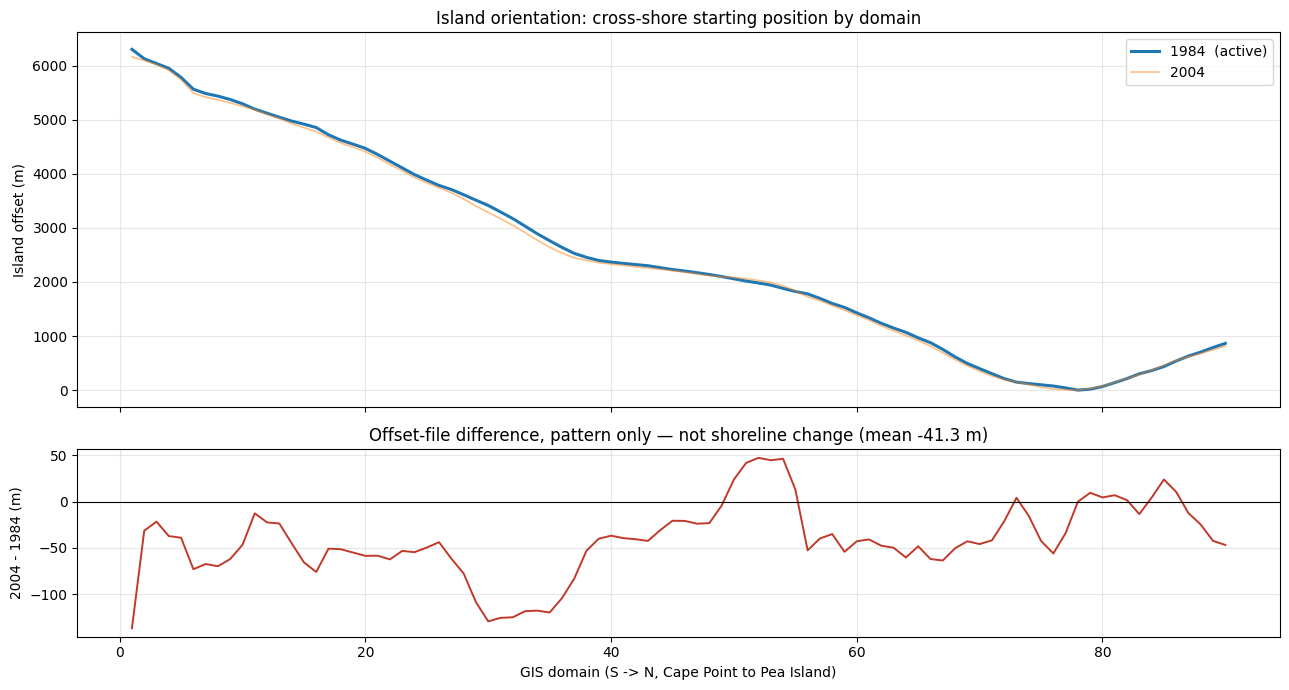

In [9]:
def load_island_offset_dam(offset_path, geometry):
    """Loads a padded BRIE island-offset file and converts it to decameters.

    Args:
        offset_path: Path to a single-column padded offset CSV, in meters.
        geometry: DomainGeometry the file must match in length.

    Returns:
        A 1-D array of offsets in decameters, one per padded domain, ready to
        pass to Cascade() as shoreline_offset.

    Raises:
        ValueError: If the file is not one value per padded domain.
    """
    offset_m = np.loadtxt(offset_path, skiprows=1, delimiter=",")
    if offset_m.ndim != 1 or offset_m.size != geometry.total_domains:
        raise ValueError(f"{offset_path.name}: expected "
                         f"{geometry.total_domains} values, got shape "
                         f"{offset_m.shape}")
    return offset_m / DAM_TO_M


def plot_island_orientation(offsets_by_year, active_year, geometry):
    """Plots island offset by GIS domain for every period, active one bold.

    Args:
        offsets_by_year: Mapping of start year to a padded offset array (dam).
        active_year: The start year currently selected.
        geometry: DomainGeometry used to slice out the real domains.

    Returns:
        The matplotlib Figure.
    """
    real = slice(geometry.start_real_index, geometry.end_real_index)
    gis_ids = np.arange(geometry.first_gis_id, geometry.last_gis_id + 1)

    fig, (ax_offset, ax_diff) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]})

    for year in sorted(offsets_by_year):
        is_active = year == active_year
        ax_offset.plot(gis_ids, offsets_by_year[year][real] * DAM_TO_M,
                       lw=2.2 if is_active else 1.2,
                       alpha=1.0 if is_active else 0.5,
                       label=f"{year}" + ("  (active)" if is_active else ""))

    ax_offset.set_ylabel("Island offset (m)")
    ax_offset.set_title("Island orientation: cross-shore starting position "
                        "by domain")
    ax_offset.legend()

    years = sorted(offsets_by_year)
    if len(years) == 2:
        earlier, later = years
        difference_m = ((offsets_by_year[later][real]
                         - offsets_by_year[earlier][real]) * DAM_TO_M)
        ax_diff.plot(gis_ids, difference_m, color="#c0392b", lw=1.4)
        ax_diff.axhline(0, color="k", lw=0.8)
        ax_diff.set_ylabel(f"{later} - {earlier} (m)")
        # NOT shoreline change: each year is zeroed on its own most-seaward
        # domain, so this carries a constant offset. Pattern only; section
        # 9.4 rebuilds the real change from the raw transect files.
        ax_diff.set_title(f"Offset-file difference, pattern only — not "
                          f"shoreline change (mean {difference_m.mean():+.1f} m)")

    ax_diff.set_xlabel("GIS domain (S -> N, Cape Point to Pea Island)")
    for ax in (ax_offset, ax_diff):
        ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


island_offset_dam = load_island_offset_dam(ISLAND_OFFSET_FILE, HATTERAS_DOMAINS)
_offsets_by_year = {
    year: load_island_offset_dam(
        HATTERAS_DATA_BASE / period["island_offset_file"], HATTERAS_DOMAINS)
    for year, period in HATTERAS_PERIODS.items()
}

_real = slice(HATTERAS_DOMAINS.start_real_index, HATTERAS_DOMAINS.end_real_index)
print(f"{START_YEAR} offsets: {island_offset_dam.size} padded domains | "
      f"real span {island_offset_dam[_real].min() * DAM_TO_M:.0f}-"
      f"{island_offset_dam[_real].max() * DAM_TO_M:.0f} m")

_ = plot_island_orientation(_offsets_by_year, START_YEAR, HATTERAS_DOMAINS)
plt.show()

### 3.2 Initialization plan view

Section 2's topography and Section 3's offsets combined: every domain's
elevation array shifted cross-shore by its island offset, so the initial
island reads as a map. This is the last check before the forcings — if the
orientation year is wrong, or a domain's topography is misaligned, it shows
up here as a kink in the island rather than as a number.

Both variants are drawn. The buffered one shows the 15 interpolated domains
on each end; they repeat one sample profile stepped along the extrapolated
offset ramp, which is what makes the ramp itself visible.

Compositing — cross-shore padding, unit conversion, canvas assembly — comes
from `cascade_pipeline.plotting.init_planview`, which
`scripts/figure_making/init_figure/plot_initialization_poster_no_border.py`
also uses, so the two cannot disagree about the surface. Only the styling
differs: the poster is tuned for print, this is tuned for a notebook cell.

real only  : canvas (835, 4500)
with buffers: canvas (950, 6000)


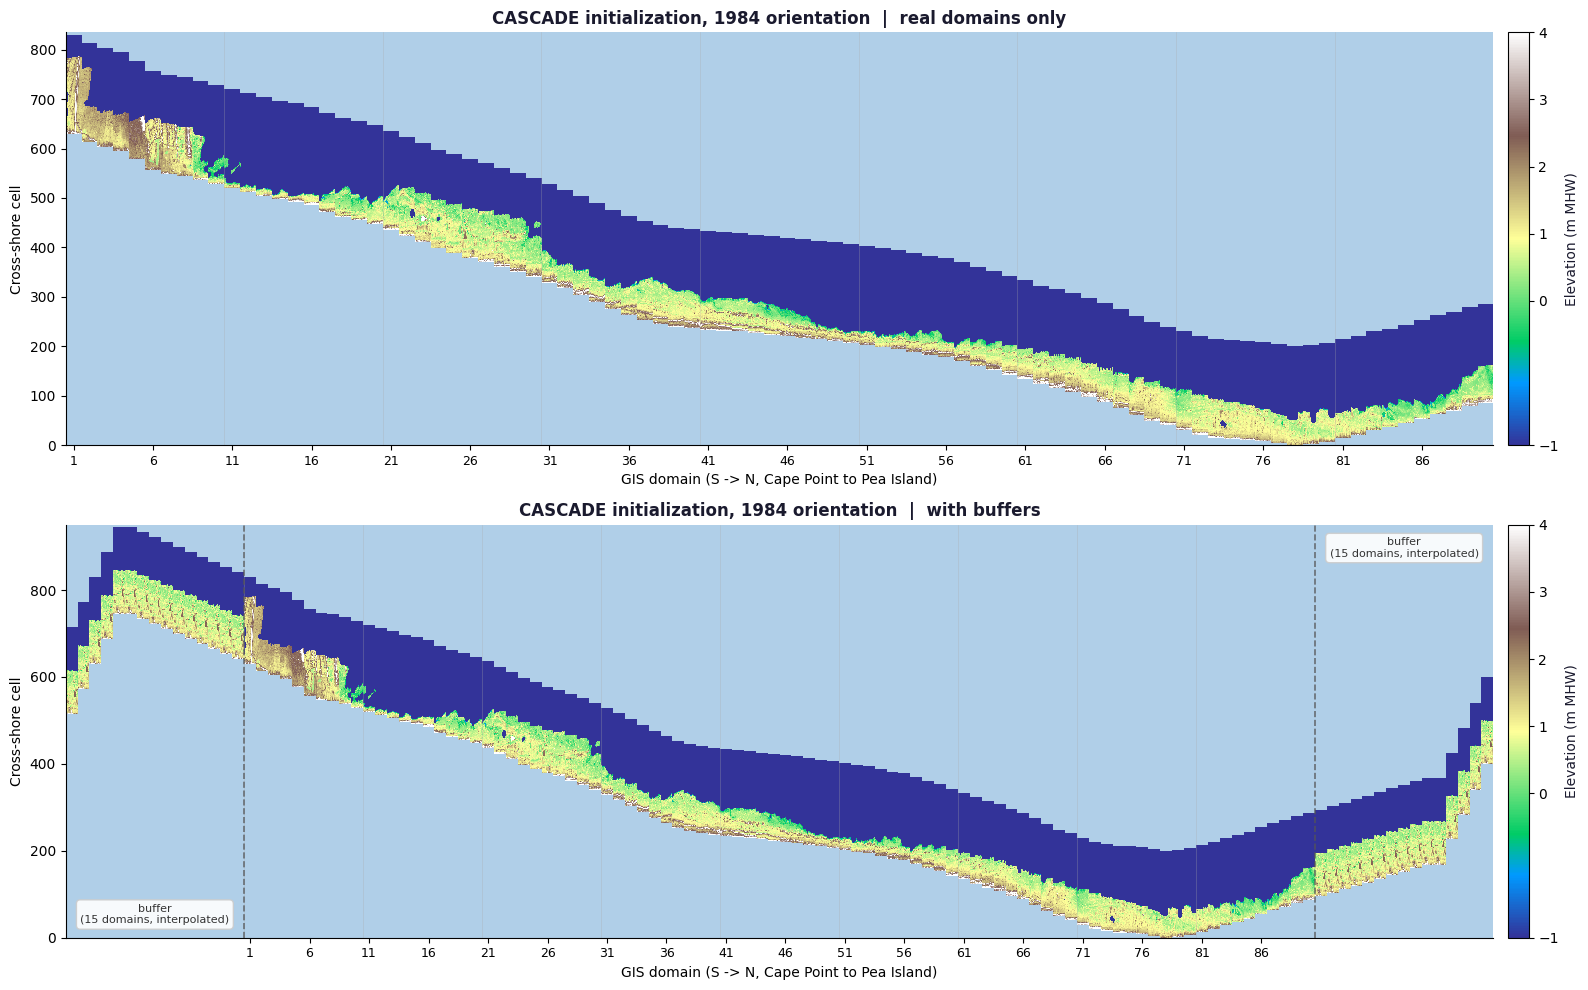

In [10]:
from cascade_pipeline.plotting import init_planview

PLAN_VIEW = init_planview.PlanViewConfig()  # extractor defaults: 200 rows, -3.0 m water

_offset_cells = np.round(
    island_offset_dam * DAM_TO_M / PLAN_VIEW.cell_size_m).astype(int)
_domain_grids = init_planview.load_domain_grids(ELEVATION_FILE_PATHS, PLAN_VIEW)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, with_buffers in zip(axes, (False, True)):
    canvas, col_starts, cells, first_real = init_planview.build_canvas(
        _domain_grids, _offset_cells, HATTERAS_DOMAINS,
        include_buffers=with_buffers, config=PLAN_VIEW)
    init_planview.plot_canvas(
        canvas, col_starts, cells, first_real, HATTERAS_DOMAINS,
        title=f"CASCADE initialization, {START_YEAR} orientation"
              + ("  |  with buffers" if with_buffers else "  |  real domains only"),
        ax=ax, include_buffers=with_buffers,
        xlabel="GIS domain (S -> N, Cape Point to Pea Island)",
        config=PLAN_VIEW)
    print(f"{'with buffers' if with_buffers else 'real only  '}: "
          f"canvas {canvas.shape}")

fig.tight_layout()
plt.show()

## 4. Period forcings — RSLR, storms, source/sink

Everything in this section is resolved by the `START_YEAR` set in Section 3.
Re-run Section 3 with the other year and re-run these cells: every number and
plot below should change together. That is the check — a forcing that does
*not* change is one that is not actually period-dependent.

### 4.1 Relative sea level rise

A single rate in m/yr, applied every model year. Both periods are plotted from
their own start year so the fork is visible: the 2004 period rises faster
(0.006 vs 0.004 m/yr) over the same 20-year run length.

SEA_LEVEL_RISE_RATE = 0.004 m/yr
  over 20 years -> 0.080 m total rise


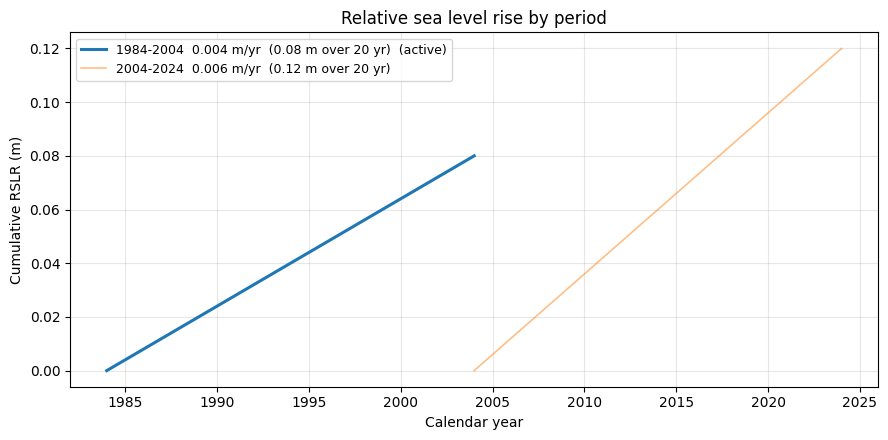

In [11]:
def plot_sea_level_rise(periods, active_year):
    """Plots cumulative RSLR for each period from its own start year.

    Args:
        periods: Mapping of start year to a period config dict.
        active_year: The start year currently selected.

    Returns:
        The matplotlib Figure.
    """
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for year in sorted(periods):
        period = periods[year]
        run_years = period["end_year"] - year
        calendar_years = np.arange(year, period["end_year"] + 1)
        cumulative_m = (calendar_years - year) * period["sea_level_rise_rate"]
        is_active = year == active_year
        ax.plot(calendar_years, cumulative_m,
                lw=2.2 if is_active else 1.2,
                alpha=1.0 if is_active else 0.5,
                label=f"{year}-{period['end_year']}  "
                      f"{period['sea_level_rise_rate']} m/yr  "
                      f"({cumulative_m[-1]:.2f} m over {run_years} yr)"
                      + ("  (active)" if is_active else ""))

    ax.set_xlabel("Calendar year")
    ax.set_ylabel("Cumulative RSLR (m)")
    ax.set_title("Relative sea level rise by period")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig


print(f"SEA_LEVEL_RISE_RATE = {SEA_LEVEL_RISE_RATE} m/yr")
print(f"  over {RUN_YEARS} years -> "
      f"{SEA_LEVEL_RISE_RATE * RUN_YEARS:.3f} m total rise")

_ = plot_sea_level_rise(HATTERAS_PERIODS, START_YEAR)
plt.show()

### 4.2 Storm series

Barrier3D's storm file is one row per storm with columns
`time, Rhigh, Rlow, period, duration`. `time` is the model time step the storm
lands on (1-based), `Rhigh`/`Rlow` are runup elevations in **decameters**, and
`duration` is in hours.

Two things to check: the time axis should span the run (roughly 1 to
`RUN_YEARS`, with no storms past the end), and `Rhigh` should look like metres
of runup once converted — a file left in metres would show up here as values
ten times too large.

1984_2004_storms_v3_72.npy: 141 storms
  time steps    1 to 21  (run is 20 years)
  Rhigh         1.51 to 3.76 m
  duration      8 to 66 hours
  storms/year   7.0 mean


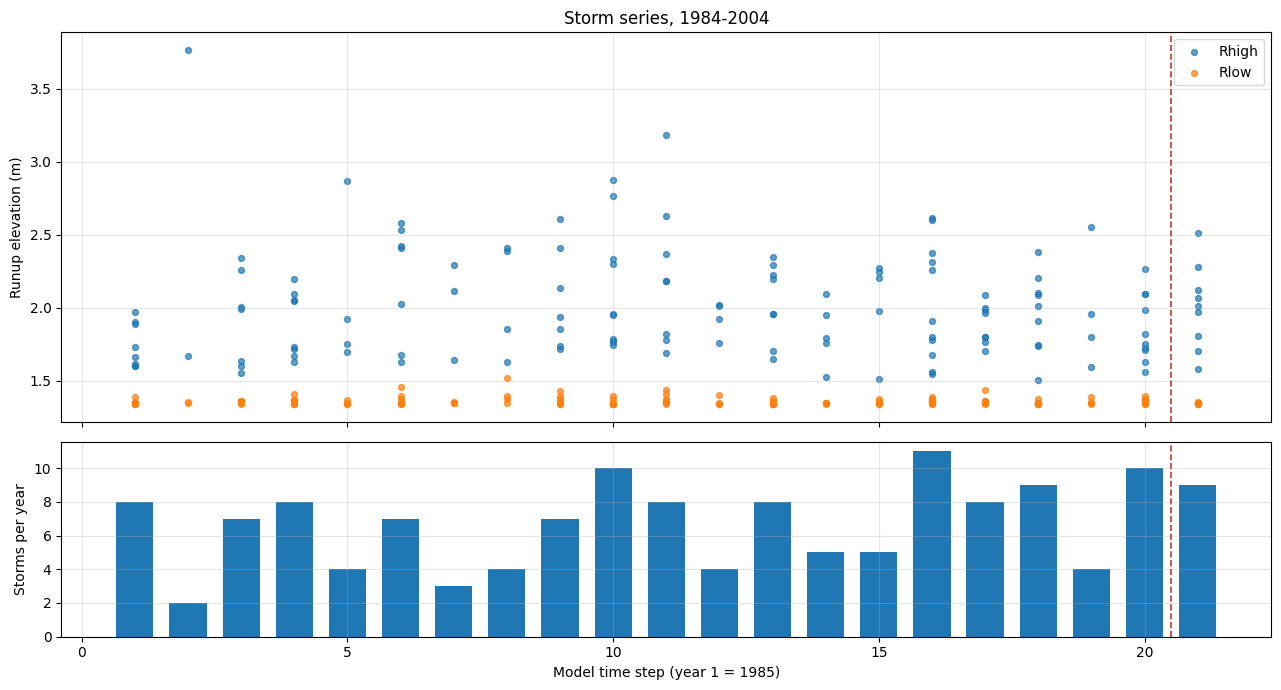

In [12]:
STORM_COLUMNS = ("time", "Rhigh", "Rlow", "period", "duration")


def load_storm_series(storm_path):
    """Loads a Barrier3D storm series into a DataFrame.

    Args:
        storm_path: Path to the storm .npy file.

    Returns:
        A DataFrame with the raw columns plus Rhigh_m and Rlow_m in meters.

    Raises:
        ValueError: If the file does not have the expected column count.
    """
    storms = np.load(storm_path)
    if storms.ndim != 2 or storms.shape[1] != len(STORM_COLUMNS):
        raise ValueError(f"{storm_path.name}: expected "
                         f"(n, {len(STORM_COLUMNS)}), got {storms.shape}")

    series = pd.DataFrame(storms, columns=STORM_COLUMNS)
    series["Rhigh_m"] = series["Rhigh"] * DAM_TO_M
    series["Rlow_m"] = series["Rlow"] * DAM_TO_M
    return series


def plot_storm_series(series, start_year, run_years):
    """Plots storm runup and storm counts against the model time axis.

    Args:
        series: DataFrame from load_storm_series.
        start_year: Calendar year of model time step 0.
        run_years: Number of model years in the run.

    Returns:
        The matplotlib Figure.
    """
    fig, (ax_runup, ax_count) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]})

    ax_runup.scatter(series["time"], series["Rhigh_m"], s=18, alpha=0.7,
                     label="Rhigh")
    ax_runup.scatter(series["time"], series["Rlow_m"], s=18, alpha=0.7,
                     label="Rlow")
    ax_runup.set_ylabel("Runup elevation (m)")
    ax_runup.set_title(f"Storm series, {start_year}-{start_year + run_years}")
    ax_runup.legend()

    counts = series["time"].value_counts().sort_index()
    ax_count.bar(counts.index, counts.values, width=0.7)
    ax_count.set_ylabel("Storms per year")
    ax_count.set_xlabel("Model time step (year 1 = "
                        f"{start_year + 1})")

    for ax in (ax_runup, ax_count):
        ax.axvline(run_years + 0.5, color="#c0392b", ls="--", lw=1.2,
                   label="_run end")
        ax.grid(alpha=0.3)

    fig.tight_layout()
    return fig


STORM_SERIES = load_storm_series(STORM_FILE)

print(f"{STORM_FILE.name}: {len(STORM_SERIES)} storms")
print(f"  time steps    {STORM_SERIES['time'].min():.0f} to "
      f"{STORM_SERIES['time'].max():.0f}  (run is {RUN_YEARS} years)")
print(f"  Rhigh         {STORM_SERIES['Rhigh_m'].min():.2f} to "
      f"{STORM_SERIES['Rhigh_m'].max():.2f} m")
print(f"  duration      {STORM_SERIES['duration'].min():.0f} to "
      f"{STORM_SERIES['duration'].max():.0f} hours")
print(f"  storms/year   {len(STORM_SERIES) / RUN_YEARS:.1f} mean")

_beyond_run = (STORM_SERIES["time"] > RUN_YEARS + 1).sum()
if _beyond_run:
    print(f"  NOTE: {_beyond_run} storms land past model year {RUN_YEARS + 1}")

_ = plot_storm_series(STORM_SERIES, START_YEAR, RUN_YEARS)
plt.show()

### 4.3 Source/sink (background erosion)

Background erosion is CASCADE's stand-in for shoreline change driven by
alongshore transport gradients that the model does not resolve. It is a per
domain rate in m/yr, passed to Barrier3D as `Rat`. Sign convention, from
`cascade/brie_coupler.py`: **(-) = erosion, (+) = accretion**.

The presets live in `hatteras_site_config.py` and are sparse -- a domain absent
from a preset gets 0.0 m/yr. Each is one hypothesis about where the sediment
budget is unresolved, and they are the source/sink axis of the run matrix:

- **`zeroBE`** imposes nothing anywhere. Whatever the shoreline does is what
  Barrier3D and BRIE produce unaided.
- **`edgeBE`** pins only the two end domains (GIS 1 and 90), which absorb the
  open-boundary artifact at the ends of the modelled reach. Nothing is imposed
  on the interior, so an interior misfit is the model's own. Its values are
  *sliced* from `calibBE`, not retyped, so the two cannot disagree about the
  ends.
- **`calibBE`** is the per-domain fit against the CoastSat LRR target rates in
  Section 8.

All three are plotted so the selected preset is visible against the
alternatives. The old names `base` and `calibrated` still work as deprecated
aliases for `zeroBE` and `calibBE`; Section 3 normalises them to the canonical
key, so a run directory is always named for the canonical preset. Note that
`base` was **all zeros**, with the edge values sitting beside them as
comments -- it was `zeroBE` all along, despite the name.


preset 'zeroBE', period 1984: 0 domains specified, 0 non-zero of 120
  rate range     no domains specified -- 0.0 m/yr everywhere
  USE_BACKGROUND_EROSION = False


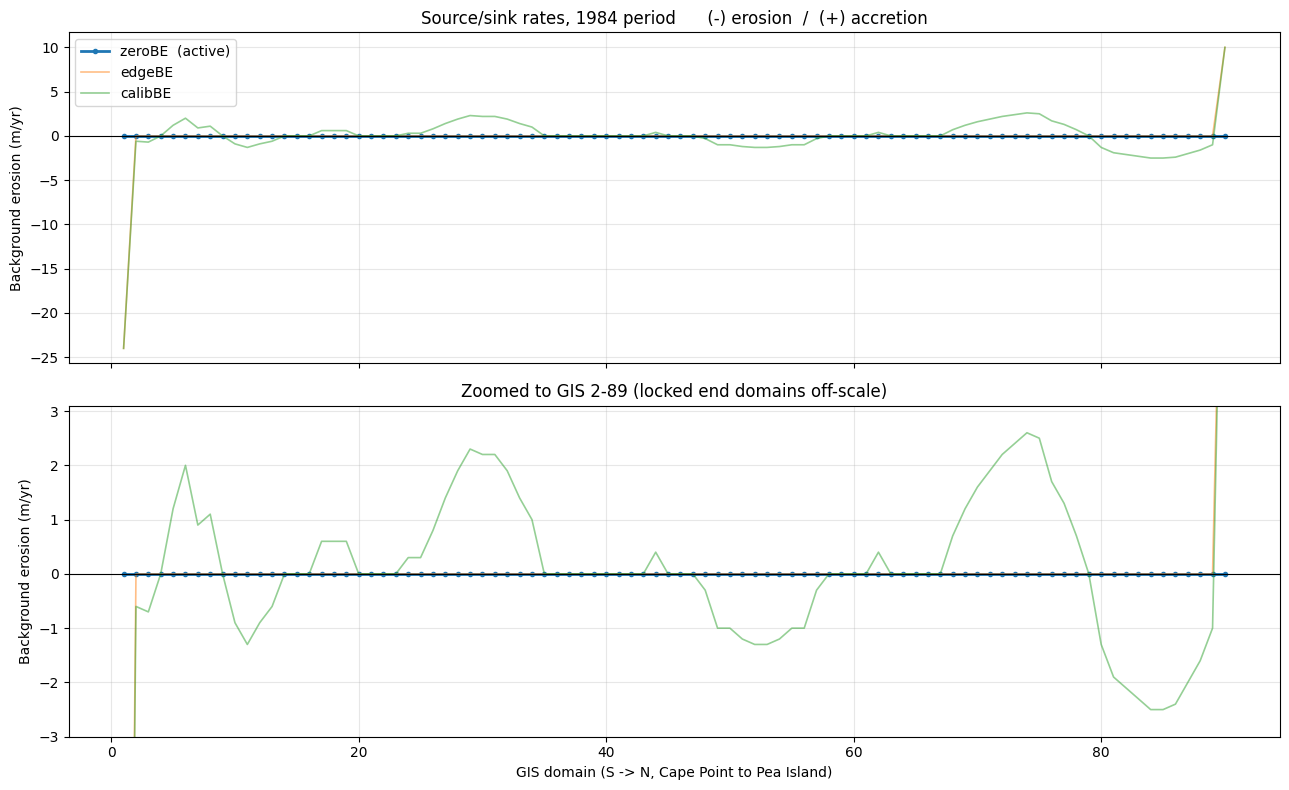

In [13]:
def build_background_erosion(be_rates, geometry):
    """Expands sparse per-GIS background-erosion rates onto the padded array.

    Args:
        be_rates: Mapping of GIS domain ID to rate in m/yr. Domains absent
            from the mapping get 0.0.
        geometry: DomainGeometry describing the padded array.

    Returns:
        A list of geometry.total_domains rates, ready to pass to Cascade().

    Raises:
        ValueError: If a GIS ID falls outside the padded array.
    """
    rates = [0.0] * geometry.total_domains
    for gis_id, rate in be_rates.items():
        pad_index = geometry.gis_to_pad(gis_id)
        if not 0 <= pad_index < geometry.total_domains:
            raise ValueError(f"GIS {gis_id} -> pad index {pad_index}, outside "
                             f"0-{geometry.total_domains - 1}")
        rates[pad_index] = float(rate)
    return rates


def plot_background_erosion(presets, start_year, active_preset, geometry):
    """Plots every background-erosion preset for one period.

    Args:
        presets: Mapping of preset name to {start_year: {gis_id: rate}}.
        start_year: The period to plot.
        active_preset: Name of the preset currently selected.
        geometry: DomainGeometry used to slice out the real domains.

    Returns:
        The matplotlib Figure.
    """
    real = slice(geometry.start_real_index, geometry.end_real_index)
    gis_ids = np.arange(geometry.first_gis_id, geometry.last_gis_id + 1)

    fig, (ax_full, ax_zoom) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    interior = slice(1, -1)   # drop the locked end domains for the zoom range
    interior_rates = []

    for name, by_period in presets.items():
        rates = np.array(build_background_erosion(
            by_period[start_year], geometry))[real]
        interior_rates.append(rates[interior])
        is_active = name == active_preset
        style = dict(lw=2.0 if is_active else 1.2,
                     alpha=1.0 if is_active else 0.5,
                     marker="o" if is_active else None, ms=3,
                     label=f"{name}" + ("  (active)" if is_active else ""))
        ax_full.plot(gis_ids, rates, **style)
        ax_zoom.plot(gis_ids, rates, **style)

    # GIS 1 and 90 are locked to large solved values that would otherwise
    # flatten the interior detail, so the lower panel excludes them.
    margin = 0.5
    ax_zoom.set_ylim(min(r.min() for r in interior_rates) - margin,
                     max(r.max() for r in interior_rates) + margin)

    ax_full.set_title(f"Source/sink rates, {start_year} period "
                      "     (-) erosion  /  (+) accretion")
    ax_full.set_ylabel("Background erosion (m/yr)")
    ax_full.legend()

    ax_zoom.set_title(f"Zoomed to GIS {geometry.first_gis_id + 1}-"
                      f"{geometry.last_gis_id - 1} (locked end domains "
                      "off-scale)")
    ax_zoom.set_ylabel("Background erosion (m/yr)")
    ax_zoom.set_xlabel("GIS domain (S -> N, Cape Point to Pea Island)")

    for ax in (ax_full, ax_zoom):
        ax.axhline(0, color="k", lw=0.8)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


DOMAIN_BE_RATES = HATTERAS_BE_PRESETS[SOURCE_SINK_PRESET][START_YEAR]
BACKGROUND_EROSION_RATES = build_background_erosion(
    DOMAIN_BE_RATES, HATTERAS_DOMAINS)
USE_BACKGROUND_EROSION = any(rate != 0.0 for rate in BACKGROUND_EROSION_RATES)

# A derived fact, not a switch: the preset decides it. Checked because the two
# used to be separate knobs that could disagree, and the run name carried both.
_EXPECT_BE_ON = SOURCE_SINK_PRESET != "zeroBE"
if USE_BACKGROUND_EROSION != _EXPECT_BE_ON:
    raise ValueError(
        f"preset {SOURCE_SINK_PRESET!r} implies "
        f"USE_BACKGROUND_EROSION={_EXPECT_BE_ON}, but the expanded rates give "
        f"{USE_BACKGROUND_EROSION}. The preset in hatteras_site_config.py does "
        f"not match its name.")

print(f"preset {SOURCE_SINK_PRESET!r}, period {START_YEAR}: "
      f"{len(DOMAIN_BE_RATES)} domains specified, "
      f"{sum(1 for r in BACKGROUND_EROSION_RATES if r != 0)} non-zero of "
      f"{HATTERAS_DOMAINS.total_domains}")
if DOMAIN_BE_RATES:
    print(f"  rate range     {min(DOMAIN_BE_RATES.values()):+.1f} to "
          f"{max(DOMAIN_BE_RATES.values()):+.1f} m/yr")
else:
    print("  rate range     no domains specified -- 0.0 m/yr everywhere")
print(f"  USE_BACKGROUND_EROSION = {USE_BACKGROUND_EROSION}")
if (START_YEAR == 2004 and SOURCE_SINK_PRESET == "calibBE"
        and HATTERAS_BE_RATES_2004_IS_PLACEHOLDER):
    print("  WARNING: 2004 calibrated rates are a copy of the 1984 fit")

_ = plot_background_erosion(HATTERAS_BE_PRESETS, START_YEAR,
                            SOURCE_SINK_PRESET, HATTERAS_DOMAINS)
plt.show()

## 5. `roadway_manager` — setbacks, per-domain elevation, historical events

NC-12's forcing is three things: **where** the road sits (setback, by period),
**how high** it is (elevation, period-independent), and **which domains are
managed** at all.

The setback is measured landward of the digitised dune line of its own year,
then spent against a grid whose row 0 is the 2009 dune crest. Where the island
narrowed between those dates the road can land behind the barrier, so §5.1
audits every setback against the interior *before* the run and names the
domains whose road drowns in year one.

Two conventions worth stating, both Barrier3D's:

- `road_ele` is **metres MHW-relative**, not NAVD88 — `bulldoze` writes it
  straight into the interior grid, which the extractor stores MHW-relative.
- relocation events carry a **displacement**, not an absolute setback. CASCADE
  already decrements the setback by dune migration each year, so adding the
  measured displacement counts the retreat once; an absolute setback referenced
  to an older dune line counts it twice.

Whether any of this is *acted on* is `ENABLE_ROADWAY_MANAGEMENT`, in section 3.
Off, the road stays fully loaded, audited, and plotted, but no `RoadwayManager`
ever bulldozes, rebuilds a dune, or decrements a setback. The road becomes a
record of where NC-12 was, not a thing the model defends.


In [14]:
from cascade_pipeline import roadway
from hatteras_site_config import (
    HATTERAS_COMMUNITY_ZONES,
    HATTERAS_FIRST_ROAD_DOMAIN,
    HATTERAS_LAST_ROAD_DOMAIN,
    HATTERAS_ROAD_ELEVATION_FILE,
    HATTERAS_ROAD_EVENTS,
)

# ENABLE_ROADWAY_MANAGEMENT and ENABLE_HISTORICAL_ROAD_RELOCATIONS are set in
# section 3, with the other management switches. The forcing below is loaded
# either way: with management off the setbacks and elevations are still read,
# audited in 5.1 and drawn in 5.2, they simply never reach a RoadwayManager.

ROADWAY = roadway.RoadwayConfig()
_road_span = (HATTERAS_FIRST_ROAD_DOMAIN, HATTERAS_LAST_ROAD_DOMAIN)

# --- setback: by period ------------------------------------------------------
# ROAD_SETBACK_FILE is resolved from PERIOD in section 3.
road_setbacks_full, _missing_setbacks = roadway.load_road_setbacks(
    ROAD_SETBACK_FILE, HATTERAS_DOMAINS, *_road_span)

# --- elevation: one set for every period -------------------------------------
ROAD_ELEVATION_FILE = HATTERAS_DATA_BASE / HATTERAS_ROAD_ELEVATION_FILE
road_elevation_full, _missing_elevations = roadway.load_road_elevations(
    ROAD_ELEVATION_FILE, HATTERAS_DOMAINS, *_road_span, config=ROADWAY)

# --- which domains CASCADE actually manages ----------------------------------
ROADWAY_MANAGEMENT_ON = roadway.build_roadway_management_on(
    HATTERAS_DOMAINS, *_road_span,
    community_zones=HATTERAS_COMMUNITY_ZONES,
    enabled=ENABLE_ROADWAY_MANAGEMENT)

_road_slice = slice(HATTERAS_DOMAINS.gis_to_pad(HATTERAS_FIRST_ROAD_DOMAIN),
                    HATTERAS_DOMAINS.gis_to_pad(HATTERAS_LAST_ROAD_DOMAIN) + 1)
print(f"setback file    {ROAD_SETBACK_FILE.name}")
print(f"  {road_setbacks_full[_road_slice].min():.0f}"
      f"-{road_setbacks_full[_road_slice].max():.0f} m"
      + (f"   MISSING {_missing_setbacks}" if _missing_setbacks else ""))
print(f"elevation file  {ROAD_ELEVATION_FILE.name}  (period-independent)")
print(f"  {road_elevation_full[_road_slice].min():.2f}"
      f"-{road_elevation_full[_road_slice].max():.2f} m MHW"
      f"   buffers {ROADWAY.elevation_fallback_m} m"
      + (f"   MISSING {_missing_elevations}" if _missing_elevations else ""))
if ENABLE_ROADWAY_MANAGEMENT:
    print(f"managed         {sum(ROADWAY_MANAGEMENT_ON)} domains "
          f"({HATTERAS_LAST_ROAD_DOMAIN - HATTERAS_FIRST_ROAD_DOMAIN + 1} "
          f"carry road, minus community zones "
          f"{list(HATTERAS_COMMUNITY_ZONES)})")
else:
    print(f"managed         0 domains -- ENABLE_ROADWAY_MANAGEMENT is False "
          f"(section 3)")
    print(f"                no bulldozing, no dune rebuild, no setback "
          f"tracking, no road drowning")
for _event in HATTERAS_ROAD_EVENTS:
    print(f"event {_event.year}      {type(_event).__name__:<15} {_event.note}")
print(f"ENABLE_HISTORICAL_ROAD_RELOCATIONS = "
      f"{ENABLE_HISTORICAL_ROAD_RELOCATIONS}")


setback file    RoadSetback_1984_dunestart.csv
  0-600 m
elevation file  RoadElevation.csv  (period-independent)
  0.30-1.58 m MHW   buffers 1.45 m
managed         0 domains -- ENABLE_ROADWAY_MANAGEMENT is False (section 3)
                no bulldozing, no dune rebuild, no setback tracking, no road drowning
event 1989      RelocationEvent NC-12 relocated landward 1989, Pea Island (GIS 84-87)
event 1999      RelocationEvent NC-12 relocated landward 1999, inter-village south (GIS 9-15)
event 2022      BridgeEvent     Jug Handle Bridge 2022; road removed GIS 82-88 -> unmanaged
ENABLE_HISTORICAL_ROAD_RELOCATIONS = False


### 5.1 Pre-flight audit — which roads will not survive year one

`bulldoze` tests the two rows *flanking* the road — never the road's own cells
— and drowns it when either flank is more than 20 % water.

A drowned road is not a warning. `roadway_manager` sets `_drown_break` and
returns immediately on every later year, so the domain gets no overwash
removal, no dune rebuilding and no relocation for the rest of the run. It
becomes an **unmanaged barrier wearing a road label**, which is why these
domains are named here rather than discovered in the output: any
managed-versus-unmanaged comparison has to exclude them explicitly.


In [15]:
road_audit = roadway.audit_setbacks(
    ELEVATION_FILE_PATHS, road_setbacks_full, HATTERAS_DOMAINS, *_road_span,
    management_on=ROADWAY_MANAGEMENT_ON, config=ROADWAY)
audit_summary = roadway.summarise_audit(road_audit)

print(f"{audit_summary['n_domains']} road domains, "
      f"{audit_summary['n_managed']} managed\n")
if audit_summary["blocking"]:
    print("BLOCKING - these would corrupt the run rather than drown it:")
    for _gis, _wall in audit_summary["blocking"]:
        print(f"  GIS {_gis}: {_wall}")
    print()
print(f"drowns at t=0, managed   : {audit_summary['drowning']}")
print(f"drowns at t=0, unmanaged : {audit_summary['drowning_unmanaged']}"
      f"   (community zones; no manager runs there)\n")

_bad = [r for r in road_audit if r["drowns"] and r["managed"]]
if _bad:
    print(f"{'GIS':>4} {'setback':>9} {'road rows':>11} {'%sea':>6} "
          f"{'%bay':>6} {'%road wet':>10} {'land ends min/med':>18}")
    for _r in _bad:
        _rows = f"{_r['road_start']}-{_r['road_end'] - 1}"
        _ends = f"{_r['width_min']} / {_r['width_median']}"
        print(f"{_r['gis']:>4} {_r['setback_m']:>8.0f}m {_rows:>11} "
              f"{_r['sea_water'] * 100:>5.0f}% {_r['bay_water'] * 100:>5.0f}% "
              f"{_r['road_cells_water'] * 100:>9.0f}% {_ends:>18}")


82 road domains, 0 managed

drowns at t=0, managed   : []
drowns at t=0, unmanaged : [78, 79, 80]   (community zones; no manager runs there)



### 5.2 The roadway on the initialization surface

The same plan view as §3.2, with NC-12 drawn where CASCADE puts it. Each
domain gets a horizontal bar at `offset + setback`, because that is literally
what the model does — `road_start = int(setback / cell)` is one row index
applied to every alongshore profile in the domain.

The orange bar is the position after the prescribed relocations, evaluated at
t=0. That is the **upper bound**: CASCADE decrements the setback by dune
migration between now and the event year, so the real relocated position sits
seaward of the bar drawn here. Blue markers flag the domains whose road drowns
in year one.


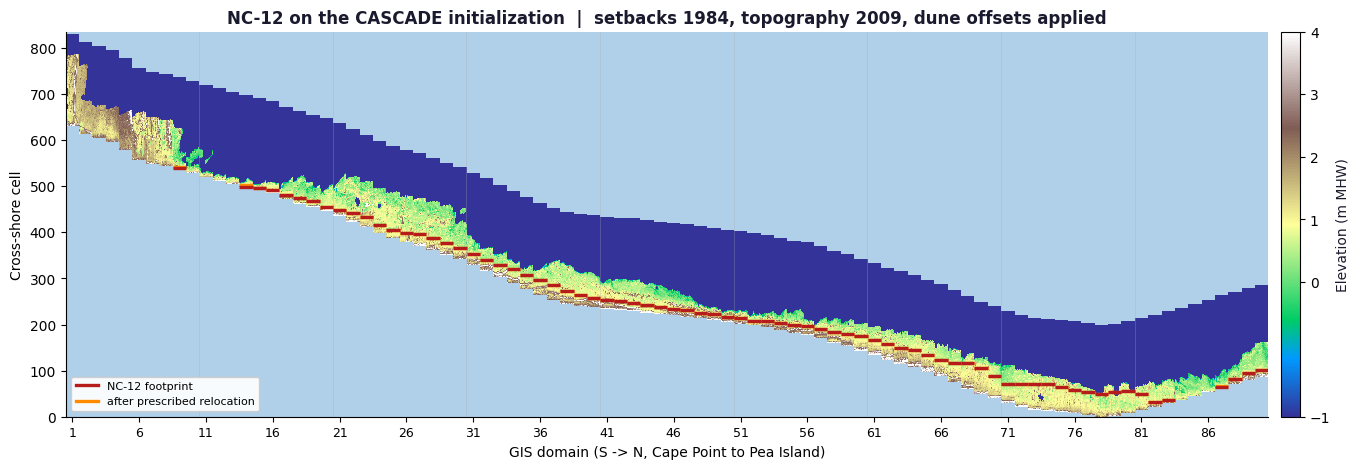

In [16]:
from cascade_pipeline.plotting.road_planview import plot_roadway_planview

# Display only - nothing in this cell feeds the run.
road_setbacks_relocated = road_setbacks_full.copy()
for _event in HATTERAS_ROAD_EVENTS:
    if isinstance(_event, roadway.RelocationEvent) and _event.enabled:
        road_setbacks_relocated = roadway.relocated_setbacks(
            road_setbacks_relocated, _event, HATTERAS_DOMAINS)

road_offset_cells = np.round(
    island_offset_dam * DAM_TO_M / PLAN_VIEW.cell_size_m).astype(int)

_fig = plot_roadway_planview(
    ELEVATION_FILE_PATHS,
    road_offset_cells,
    road_setbacks_full,
    HATTERAS_DOMAINS,
    title=(f"NC-12 on the CASCADE initialization  |  setbacks {START_YEAR}, "
           f"topography {TOPO_DUNE_INIT_YEAR}, dune offsets applied"),
    relocated_m=road_setbacks_relocated,
    drowning_gis=audit_summary["drowning"],
    config=PLAN_VIEW,
    xlabel="GIS domain (S -> N, Cape Point to Pea Island)",
)
plt.show()


## 6. `beach_dune_manager` — nourishment schedule + overwash filter

Two different things arrive bundled in one CASCADE module, and the distinction
matters more than the name suggests.

**Always-on**, in every domain where the module is enabled, for every year of
the run: a percentage of overwash deposition is removed from the interior and
returned to the shoreface, the dune line is held fixed in the cross-shore
(`dune_migration_on = False`), and the community is abandoned if the average
interior width falls below 50 m.

**Event-driven**, only where and when `nourish_now` says so: sand is added to
the shoreface, moving the shoreline seaward and widening the beach.

There is no way to get the second without the first. Turning the module on to
deliver a 2022 fill also turns on overwash filtering and a fixed dune line in
that domain from year one.

Three conventions, all of them places this pipeline has been wrong before:

- `overwash_filter` is a **percent**, not a fraction. `filter_overwash` divides
  it by 100, and Rogers et al. (2015) give 40–90 %, residential to commercial.
  A value of `0.4` filters 0.4 % of overwash, which is indistinguishable from
  no filtering. `BeachDuneConfig` now refuses the fraction scale.
- The per-year volume goes to **`cascade.nourishment_volume`**, which is where
  CASCADE reads it from. This is not a way around the module: `beach_dune_manager`
  still performs every fill, unmodified. Stock `Cascade.update()` copies its own
  `nourishment_volume` list into each manager on every step and then calls the
  manager, which spends it (`cascade_groin.py:781-789` ->
  `beach_dune_manager.py:788`). So a volume written onto the `BeachDuneManager`
  instance instead lands on the same attribute CASCADE overwrites one line before
  the manager reads it, and the fill quietly spends the `Cascade()` init default.
  `apply_to_cascade()` writes the two Cascade-level inputs -- `nourish_now` and
  `nourishment_volume` -- and nothing else.
- The manager's time series are **offset by one**. `update_dune_domain()`
  increments `time_index` before the management modules run, so a manager
  writing at `time_index - 1` lands on index `year - start_year + 1`.

### The footprint is a union of two different maps

`beach_dune_manager` runs on the permanent community zones **and** every domain
that receives fill. Those come from unrelated sources — settlement extents
versus engineering project extents — and the projects are wider than the
villages. Buxton 2022 runs north out of the village into the NC-12 corridor,
and the Rodanthe 2014 emergency fill sits north of Tri-Village entirely.

Where that union overlaps the roadway footprint, **both managers run on the
same domain in the same year**. CASCADE permits this — the two loops in
`cascade.update()` are independent — but it is outside what Anarde et al.
published, and it has two consequences the cell below names explicitly:
overwash is removed twice over (bulldozed first, then the survivors filtered),
and the fixed dune line leaves `ShorelineChangeTS` at 0, which is the value
`RoadwayManager` reads to decrement the road setback. NC-12 stops retreating
in those domains.

That is reported, not corrected — §12 asserts it against the finished run
rather than trusting the prediction.

### Two switches, because the module is two things

Section 3 sets both. `ENABLE_BEACH_DUNE_MANAGEMENT` decides whether the module
runs at all: off, the footprint is empty everywhere, `overwash_filter` is handed
to CASCADE as zeros, and the village domains get natural shoreline behaviour --
the dune line migrates, overwash lands where it lands, no width check.

`ENABLE_NOURISHMENT_FILLS` sits inside that: with the module on, it decides only
whether the historical fill is spent. It works by driving an **empty schedule**
for the same period, not by shrinking the footprint, so `BEACH_DUNE_MANAGEMENT_ON`
is identical either way. That is what makes the fills-on / fills-off pair a
single-variable comparison -- the always-on behaviour described above is held
fixed, and the difference between the two runs is the sand.

The distinction matters because of the paragraph above: turning fills off does
**not** give you natural dynamics in the villages. Only turning the module off
does.


### 6.1 Build the schedule, filter, and management footprints
Everything CASCADE is handed for this period: the period-filtered project
schedule, the overwash filter, and the two per-domain module footprints.
`NOURISHMENT_VOLUME_INIT` is deliberately zero -- see the comment in the cell.


In [17]:
from cascade_pipeline import nourishment
from hatteras_site_config import (
    HATTERAS_BEACH_DUNE,
    HATTERAS_NOURISHMENT_PROJECTS,
)

# --- schedule: one project list, period-filtered ------------------------------
# Every Hatteras project falls in 2004-2024, so a 1984 run builds an empty
# schedule from this same list rather than needing a period-keyed one.
BN_SCHEDULE = nourishment.build_schedule(
    HATTERAS_NOURISHMENT_PROJECTS, HATTERAS_DOMAINS, START_YEAR, END_YEAR)

# --- the schedule the model is actually driven by -----------------------------
# ENABLE_NOURISHMENT_FILLS (section 3). Suppressing fills builds an EMPTY
# schedule for the same period rather than skipping apply_to_cascade: the loop
# still rewrites nourish_now and nourishment_volume to zero every year, and 6.3
# and 12.2 both check against what was driven rather than what was intended.
# BN_SCHEDULE itself is left intact and still defines the module footprint
# below, so turning fills off changes the fill and not the footprint.
BN_SCHEDULE_APPLIED = BN_SCHEDULE if ENABLE_NOURISHMENT_FILLS else (
    nourishment.build_schedule([], HATTERAS_DOMAINS, START_YEAR, END_YEAR))

# --- what CASCADE is handed ---------------------------------------------------
# The filter is inert with the module off -- only BeachDuneManager applies it --
# so it is built as zeros there rather than left at its community values. The
# array handed to CASCADE should state what the run does, not what it would do.
OVERWASH_FILTER = (
    nourishment.build_overwash_filter(
        HATTERAS_DOMAINS, HATTERAS_COMMUNITY_ZONES, config=HATTERAS_BEACH_DUNE)
    if ENABLE_BEACH_DUNE_MANAGEMENT
    else [0.0] * HATTERAS_DOMAINS.total_domains)
OVERWASH_TO_DUNE = HATTERAS_BEACH_DUNE.overwash_to_dune_pct
BEACH_DUNE_MANAGEMENT_ON = nourishment.build_beach_dune_management_on(
    HATTERAS_DOMAINS, HATTERAS_COMMUNITY_ZONES, BN_SCHEDULE.nourished_gis,
    enabled=ENABLE_BEACH_DUNE_MANAGEMENT)

# Placeholder for the Cascade() call. Every value is rewritten each model year
# by BN_SCHEDULE.apply_to_cascade(), so this is 0 rather than
# PERIOD["nourishment_volume"]: if the schedule ever fails to reach the model,
# a year should nourish nothing rather than quietly nourish the default.
NOURISHMENT_VOLUME_INIT = [0.0] * HATTERAS_DOMAINS.total_domains

DOUBLE_MANAGED_GIS = nourishment.find_double_managed(
    BEACH_DUNE_MANAGEMENT_ON, ROADWAY_MANAGEMENT_ON, HATTERAS_DOMAINS)
BN_AUDIT = nourishment.audit_schedule(
    BN_SCHEDULE_APPLIED, BEACH_DUNE_MANAGEMENT_ON, config=HATTERAS_BEACH_DUNE)

### 6.2 Plot helpers
`contiguous_gis_runs` is generic domain geometry; `plot_beach_dune_management`
draws the two panels below. Both are candidates to move into
`cascade_pipeline` -- nothing in this cell produces output.


In [18]:
def contiguous_gis_runs(mask, geometry):
    """Contiguous GIS spans where a padded boolean mask is True.

    Args:
        mask: Sequence of booleans indexed by padded position.
        geometry: DomainGeometry describing the padded array.

    Returns:
        A list of inclusive (first_gis, last_gis) tuples.
    """
    runs = []
    start = None
    for pad in range(geometry.start_real_index, geometry.end_real_index):
        if mask[pad] and start is None:
            start = pad
        elif not mask[pad] and start is not None:
            runs.append((int(geometry.pad_to_gis(start)),
                         int(geometry.pad_to_gis(pad - 1))))
            start = None
    if start is not None:
        runs.append((int(geometry.pad_to_gis(start)),
                     int(geometry.pad_to_gis(geometry.end_real_index - 1))))
    return runs


def plot_beach_dune_management(overwash_filter, beach_dune_on, roadway_on,
                               schedule, double_managed_gis, geometry):
    """Plots the overwash filter and both management footprints by GIS domain.

    Two panels on a shared domain axis. The top panel is the magnitude the
    module actually applies; the bottom is which modules run where, so the
    overlap that neither footprint was drawn to avoid is visible rather than
    inferred.

    Args:
        overwash_filter: Per-domain filter percentages.
        beach_dune_on: Per-domain booleans for beach_nourishment_module.
        roadway_on: Per-domain booleans for roadway_management_module.
        schedule: The NourishmentSchedule for this period.
        double_managed_gis: GIS domains where both modules run.
        geometry: DomainGeometry describing the padded array.

    Returns:
        The matplotlib Figure.
    """
    c_filter = "#08519C"    # deep blue, matches the notebook's obs family
    c_bdm = "#08519C"
    c_road = "#6BAED6"      # lighter step of the same hue
    c_nourish = "#FF8C00"   # warm accent, as elsewhere for model-side forcing
    c_double = "#B71C1C"

    real = slice(geometry.start_real_index, geometry.end_real_index)
    gis_ids = np.arange(geometry.first_gis_id, geometry.last_gis_id + 1)
    filter_real = np.asarray(overwash_filter, dtype=float)[real]

    nourished_pads = {geometry.gis_to_pad(g) for g in schedule.nourished_gis}
    nourished_mask = [pad in nourished_pads
                      for pad in range(geometry.total_domains)]

    fig, (ax_filter, ax_map) = plt.subplots(
        2, 1, figsize=(13, 6), sharex=True,
        gridspec_kw=dict(height_ratios=[1.4, 1]))

    # --- top: how much overwash is filtered, and where -----------------------
    # The shading is the point of the panel: nourished ground and filtered
    # ground only partly coincide, and the domains that are shaded but have no
    # bar are the ones running the module for the fill alone.
    for first_gis, last_gis in contiguous_gis_runs(nourished_mask, geometry):
        ax_filter.axvspan(first_gis - 0.5, last_gis + 0.5, color=c_nourish,
                          alpha=0.15, zorder=0, label="_nolegend_")
    ax_filter.bar(gis_ids, filter_real, width=0.9, color=c_filter,
                  label="overwash filtered (developed ground)")
    if schedule.nourished_gis:
        ax_filter.axvspan(np.nan, np.nan, color=c_nourish, alpha=0.15,
                          label="nourished at least once")
    ax_filter.set_ylabel("overwash_filter (%)")
    ax_filter.set_ylim(0, max(50, filter_real.max() * 1.25))
    ax_filter.set_title(
        f"beach_dune_manager forcing, {schedule.start_year}-"
        f"{schedule.end_year}     "
        f"filter {HATTERAS_BEACH_DUNE.community_overwash_filter_pct:.0f}% + "
        f"{HATTERAS_BEACH_DUNE.overwash_to_dune_pct:.0f}% to dune")
    ax_filter.legend(loc="upper left", frameon=False)
    ax_filter.grid(alpha=0.3, axis="y")

    # --- bottom: which module runs where -------------------------------------
    rows = [
        ("roadway_manager", roadway_on, c_road, 0),
        ("beach_dune_manager", beach_dune_on, c_bdm, 1),
    ]
    for label, mask, color, y in rows:
        for first_gis, last_gis in contiguous_gis_runs(mask, geometry):
            ax_map.barh(y, last_gis - first_gis + 1, left=first_gis - 0.5,
                        height=0.55, color=color, align="center")
        ax_map.text(geometry.first_gis_id - 1.5, y, label, ha="right",
                    va="center", fontsize=9)

    # Overlap: outlined rather than filled, so the underlying rows stay legible.
    for first_gis, last_gis in contiguous_gis_runs(
            [beach_dune_on[p] and roadway_on[p]
             for p in range(geometry.total_domains)], geometry):
        ax_map.add_patch(plt.Rectangle(
            (first_gis - 0.5, -0.45), last_gis - first_gis + 1, 1.9,
            fill=False, edgecolor=c_double, lw=1.8, hatch="///", zorder=5))

    # Nourishment events, labelled per project rather than per year -- two
    # projects share 2022, and a single averaged label would sit between them,
    # over neither.
    for row in schedule.events():
        ax_map.plot(row["gis"], 2, marker="v", ms=8, color=c_nourish, zorder=6)
    for project in schedule.projects:
        ax_map.text(float(np.mean(project.gis_domains)), 2.4,
                    str(project.year), ha="center", va="bottom", fontsize=9,
                    color=c_nourish)
    ax_map.text(geometry.first_gis_id - 1.5, 2, "nourishment", ha="right",
                va="center", fontsize=9, color=c_nourish)

    if double_managed_gis:
        ax_map.legend(
            handles=[plt.Rectangle((0, 0), 1, 1, fill=False,
                                   edgecolor=c_double, lw=1.8, hatch="///")],
            labels=[f"both modules ({len(double_managed_gis)} domains)"],
            loc="upper left", frameon=False, fontsize=9)

    ax_map.set_ylim(-0.7, 3.4)
    ax_map.set_yticks([])
    ax_map.set_xlim(geometry.first_gis_id - 6, geometry.last_gis_id + 1)
    ax_map.set_xticks(np.arange(geometry.first_gis_id,
                                geometry.last_gis_id + 1, 5))
    ax_map.set_xlabel("GIS domain (S -> N, Cape Point to Pea Island)")
    ax_map.grid(alpha=0.3, axis="x")
    for spine in ("top", "right", "left"):
        ax_map.spines[spine].set_visible(False)

    fig.tight_layout()
    return fig

### 6.3 Audit and QC plot
The schedule as it will be applied, the pre-flight audit, and the
double-management warning. The plot shows the overwash filter over the
footprints, so the overlap neither footprint was drawn to avoid is visible
rather than inferred.


period                1984-2004
module on             0 domains -- ENABLE_BEACH_DUNE_MANAGEMENT is False (section 3)
                      no overwash filtering, no fixed dune line, no width-drowning check, no fill
                      overwash_filter handed to CASCADE is all zero, so the array says what the run does

nourishment schedule  0 project(s) applied
  --    Rodanthe emergency fill    skipped: 2014 outside 1984-2004
  --    Buxton shore protection    skipped: 2022 outside 1984-2004
  --    Avon shore protection      skipped: 2022 outside 1984-2004

pre-flight audit      ok
  note: No nourishment projects fall in 1984-2004; the module still runs its always-on behaviour wherever beach_dune_management_on is True.

BOTH MODULES ON       none - at least one module is off, so the overlap cannot arise


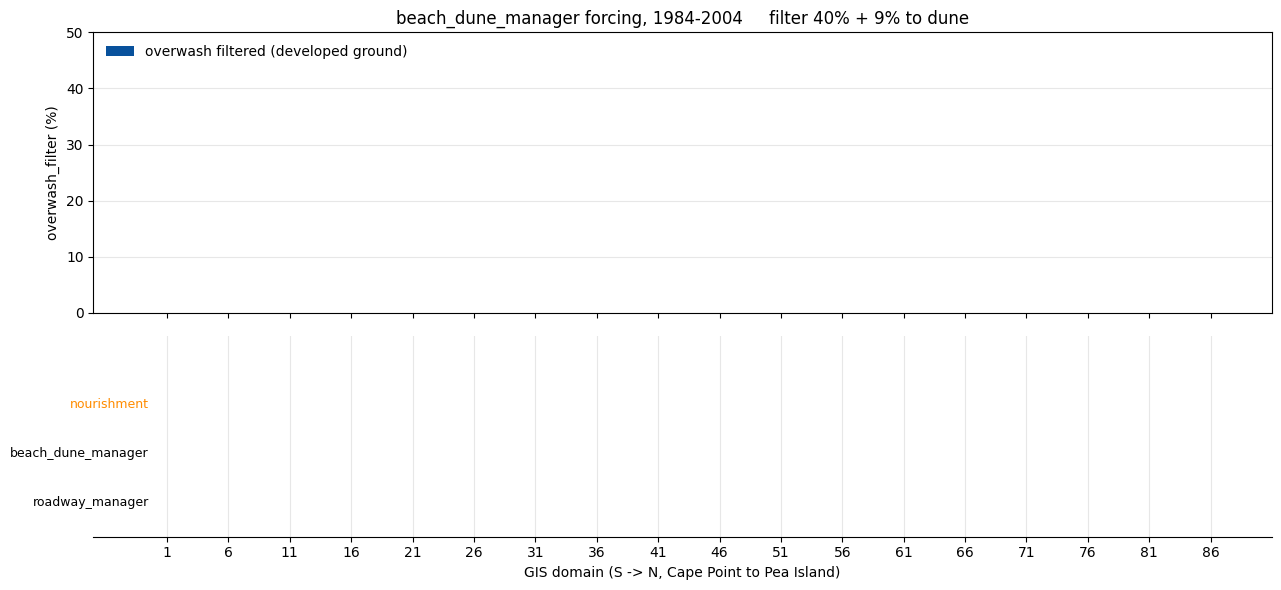

In [19]:
print(f"period                {START_YEAR}-{END_YEAR}")
if ENABLE_BEACH_DUNE_MANAGEMENT:
    print(f"overwash_filter       "
          f"{HATTERAS_BEACH_DUNE.community_overwash_filter_pct:.0f}% in "
          f"community zones, "
          f"{HATTERAS_BEACH_DUNE.default_overwash_filter_pct:.0f}% "
          f"elsewhere   (PERCENT, not a fraction)")
    print(f"overwash_to_dune      {OVERWASH_TO_DUNE:.0f}%")
    print(f"module on             {sum(BEACH_DUNE_MANAGEMENT_ON)} domains "
          f"= community zones {list(HATTERAS_COMMUNITY_ZONES)} "
          f"UNION nourished {list(BN_SCHEDULE.nourished_gis)}")
    if not ENABLE_NOURISHMENT_FILLS and BN_SCHEDULE.projects:
        print(f"                      the footprint still carries the project "
              f"extents: the fills are off, the module is not")
else:
    print(f"module on             0 domains -- "
          f"ENABLE_BEACH_DUNE_MANAGEMENT is False (section 3)")
    print(f"                      no overwash filtering, no fixed dune line, "
          f"no width-drowning check, no fill")
    print(f"                      overwash_filter handed to CASCADE is all "
          f"zero, so the array says what the run does")

print(f"\nnourishment schedule  "
      f"{len(BN_SCHEDULE_APPLIED.projects)} project(s) applied"
      + (f"   {len(BN_SCHEDULE.projects)} in period SUPPRESSED by "
         f"ENABLE_NOURISHMENT_FILLS=False"
         if not ENABLE_NOURISHMENT_FILLS and BN_SCHEDULE.projects else ""))
for _project in BN_SCHEDULE_APPLIED.projects:
    _per_m = _project.volume_m3_per_m(HATTERAS_DOMAINS.domain_spacing_m)
    print(f"  {_project.year}  {_project.name:<26} "
          f"GIS {_project.gis_domains[0]}-{_project.gis_domains[-1]:<3} "
          f"{_project.volume_cubic_yards:>9,.0f} cy -> "
          f"{_per_m:>7.1f} m^3/m per domain   "
          f"(TS index {BN_SCHEDULE_APPLIED.time_index(_project.year)})")
for _project, _reason in BN_SCHEDULE.skipped:
    print(f"  --    {_project.name:<26} skipped: {_reason}")

print(f"\npre-flight audit      {'ok' if BN_AUDIT['ok'] else 'PROBLEMS'}")
if BN_AUDIT["module_off"]:
    print(f"  scheduled but module OFF (fill would be dropped): "
          f"{BN_AUDIT['module_off']}")
for _row in BN_AUDIT["implausible_volume"]:
    print(f"  implausible volume: GIS {_row['gis']} {_row['year']} "
          f"{_row['volume_m3_per_m']:.1f} m^3/m")
for _note in BN_AUDIT["notes"]:
    print(f"  note: {_note}")

if DOUBLE_MANAGED_GIS:
    print(f"\nBOTH MODULES ON       GIS {list(DOUBLE_MANAGED_GIS)} "
          f"({len(DOUBLE_MANAGED_GIS)} domains)")
    print("  Overwash is removed twice over: RoadwayManager bulldozes and")
    print("  rewrites DomainTS, then BeachDuneManager filters what survived.")
    print("  BeachDuneManager also holds dune_migration_on False, so")
    print("  ShorelineChangeTS stays 0 -- the value RoadwayManager reads to")
    print("  decrement the setback. NC-12 stops retreating here.")
    print("  Run as published; verified against the finished run in section 12.")
elif not (ENABLE_ROADWAY_MANAGEMENT and ENABLE_BEACH_DUNE_MANAGEMENT):
    print("\nBOTH MODULES ON       none - at least one module is off, so the "
          "overlap cannot arise")
else:
    print("\nBOTH MODULES ON       none - the two footprints are disjoint "
          "this period")

_ = plot_beach_dune_management(
    OVERWASH_FILTER, BEACH_DUNE_MANAGEMENT_ON, ROADWAY_MANAGEMENT_ON,
    BN_SCHEDULE_APPLIED, DOUBLE_MANAGED_GIS, HATTERAS_DOMAINS)
plt.show()

## 7. `hard_structures` / groin -- Buxton groin field

`cascade/groin.py` attaches to a run through `cascade._groin_callback` and is
called once per model year from inside `Cascade.update()`, immediately before
the alongshore-transport solve (`cascade/cascade_groin.py:600`). Each active
year it adds `-M` to the updrift domain and `+M` to the downdrift domain of
`x_s_dt`, then hands the array on. BRIE's implicit diffusion solve spreads that
dipole in the same step, so the fillet's taper and alongshore extent are
**emergent** -- only its amplitude is imposed.

Units and sign are the ones BRIE already uses, verified rather than assumed:
`brie_coupler.py:57` converts `x_s_dt` to meters before the hook sees it and
line 344 converts back, so `M` is meters per year with no conversion in the
module. `x_s` increases landward, so `-M` updrift is a seaward advance.

### It is a forcing, not a barrier

Nothing in this module blocks alongshore transport. Littoral drift crosses GIS
5.5 in the model exactly as it would with no structure there. What the dipole
reproduces is the *shoreline signature* of blockage -- accretion one side,
starvation the other -- by moving shoreline displacement between two adjacent
cells. The pair is volume-neutral by construction: `-M` and `+M` cancel.

Three consequences, stated here rather than discovered later:

- **Trapping never saturates on state.** A real groin fills to its tip and
  bypasses; trapping shuts off because the fillet grew. Here `M` is applied at
  full strength every year, modulated only by a calendar schedule. The
  amplitude does level off -- diffusion balances injection at
  `A ~= M / (4 * r_ipl)` -- but for a reason unrelated to the physical one.
- **The year counter is the call counter.** `groin.py:230` computes
  `year = start_year + _call_count`. The callback never reads `cascade` and
  never checks `time_index`, so it assumes it is called exactly once per model
  year, in order. It cannot detect the off-by-one that section 6 documents for
  `BeachDuneManager`.
- **`install_year` is inert here.** 1969 precedes both 1984 and 2004, so
  `active` is `True` at every step of either period and `active_TS` carries no
  information. It mattered for the 1967 test runs.

One dipole also stands in for the whole Buxton groin field. At 500 m domains
the field is sub-domain scale, so that is a resolution limit rather than a
modelling choice.

### Two independent estimates of `M` disagree, and that is reported

`M` is the single tunable knob, and two lines of evidence give answers an order
of magnitude apart.

The sensitivity sweep fit `M` against a **shoreline-position** target and found
`M = 50 m/yr` (RMSE 24.0, `HAT_groin_sweep_results.csv`) -- from the 1967-2017
test setup, not this period.

The **sediment budget** says that is unaffordable. Moving `M` meters of
shoreline over a 500 m domain transfers `M * dy * (d_sf + h_b)` per year. At
`M = 50` that is 3-6 x 10^5 m3/yr depending on the active profile height,
against a reach-integrated transport-gradient loss of 5.9 x 10^5 m3/yr for the
whole of Oregon Inlet to Cape Hatteras (Inman & Dolan 1989, via Moore et al.
2010, doi:10.1029/2009JF001299). The groin would be moving something close to
the island's entire annual budget across one domain boundary, every year, while
deteriorating from 1996 and storm-damaged in 2003.

That comparison is order-of-magnitude only: 5.9 x 10^5 m3/yr is a *divergence*
over a ~60 km reach, not a gross flux past Buxton. The cell prints that caveat
with the number on every run.

The run is configured at the sweep's `M = 50` and the breach is **reported, not
corrected** -- the same treatment section 6 gives the double-managed domains.
If both estimates are right, the extra shoreline signal at D5/D6 is not groin
trapping; it is the Cape Point shoal dynamics the calibrated source/sink rates
already claim there (`+1.2` at D5, `+2.0` at D6, both accretion). Those rates
were fit to observed CoastSat LRR spanning the functional-groin era, so the
groin's signature is plausibly counted twice. Left standing pending the
source/sink re-analysis; section 12 checks it against the finished run.

### Deterioration is scheduled, not simulated

Last repair 1996, storm damage 2003, encoded as a linear ramp between them
(`deterioration_delay_years = 27`, `ramp_years = 7`). For a 1984 start the ramp
falls at run-years 12-19; for a 2004 start it has already completed, so the
groin sits at its floor from year 0. The floor itself, `0.9`, is the sweep's
paired value for `M = 50` -- it leaves the structure at 90 % strength after
failure, which the documented 1996/2003 history does not support. Printed as an
open tension rather than silently reconciled.

### What is deliberately not here

No `predict_fillet` call. Its `r_ipl` is a local variable inside BRIE's
`update()` (`brie.py:1294`), computed per domain per step from `_coast_diff`
and never stored -- and `finalize()` deletes `_coast_diff` outright. Section 11
reads it off the constructed model and prints the predicted amplitude and
extent **before** the time loop, so the emergent-extent check is pre-registered
rather than retrofitted.

### 7.1 Switches, structure, and the sediment-budget reference
Every constant the groin needs, and nothing that acts on them. The
`GROIN_ENABLED` guard fails fast here because attaching a callback to a
Cascade built from the real package is a silent no-op.


In [ ]:
from cascade.groin import GroinCallback, predict_fillet

# =============================================================================
# Switches
# =============================================================================
# GROIN_ENABLED is set in section 3, beside the scenario, so one cell decides
# what a run simulates. The guard below stays here: this is where a wrongly
# configured groin would silently do nothing.

# The pre-AST hook exists ONLY in cascade/cascade_groin.py. Attaching a callback
# to a Cascade built from the real package is a silent no-op: the run succeeds,
# the groin does nothing, and the output looks like a valid groin-on run.
if GROIN_ENABLED and not USE_SANDBOX_CASCADE:
    raise RuntimeError(
        "GROIN_ENABLED=True requires USE_SANDBOX_CASCADE=True (section 1). "
        "cascade.cascade.Cascade.update() has no _groin_callback hook, so the "
        "groin would silently do nothing.")

# =============================================================================
# Structure: the Buxton groin field
# =============================================================================
# Net alongshore transport on Hatteras is southward, so updrift = north. The
# two domains must be adjacent -- they share the blocked boundary at GIS 5.5.
GROIN_UPDRIFT_GIS = 6       # source: accretes
GROIN_DOWNDRIFT_GIS = 5     # sink:   erodes
GROIN_INSTALL_YEAR = 1969   # confirmed construction date

# --- amplitude: the only tunable knob ----------------------------------------
# Both knobs come from HAT_hindcast_config so the sweep driver can set them
# per run. They are fit JOINTLY across the two periods, not independently: over
# 1984-2004 the cumulative trapping is M*(16 + 4f), so f barely separates from
# M there, while over 2004-2024 the run sits entirely past the 2003 ramp and
# only the product M*f is identifiable. Neither window pins both on its own.
GROIN_TRAPPING_RATE_M_YR = RUN_CONFIG.groin_trapping_rate_m_yr
GROIN_M_PROVENANCE = ("joint two-period fit against the CoastSat D6-D5 "
                      "differential; see output/groin_sweep/ for the M-f "
                      "ridge and which grid bounds the solution touches")

# --- deterioration: 1996 last repair -> 2003 storm damage --------------------
GROIN_DETERIORATION_DELAY_YEARS = 1996 - GROIN_INSTALL_YEAR   # = 27
GROIN_DETERIORATION_MODE = "linear_ramp"
GROIN_DETERIORATION_RAMP_YEARS = 2003 - 1996                  # = 7
GROIN_DETERIORATION_FRACTION = RUN_CONFIG.groin_deterioration_fraction

# =============================================================================
# Sediment-budget reference
# =============================================================================
REACH_TRANSPORT_LOSS_M3_YR = 5.9e5
REACH_TRANSPORT_CITATION = ("Inman & Dolan (1989), via Moore et al. (2010), "
                            "doi:10.1029/2009JF001299")
REACH_TRANSPORT_CAVEAT = (
    "reach-integrated transport-gradient LOSS, Oregon Inlet to Cape Hatteras "
    "(~60 km) -- a divergence, not a gross flux at Buxton, so this bounds "
    "order of magnitude only")

# Active profile height, converting shoreline displacement to volume. The yaml
# carries DShoreface=22.25 with LShoreface=2640 (a 1:119 slope, consistent with
# meters), but Barrier3D's internal length unit is decameters and no conversion
# is applied at load (barrier3d.py:1181). Both candidates print here rather
# than one being asserted; section 11 resolves it from the constructed model.
GROIN_PROFILE_HEIGHT_CANDIDATES_M = (12.0, 24.0)

GROIN_PLOT_HALFWIDTH = 5   # domains either side of the groin in the QC plot

### 7.2 Build the callback
`GROIN_CB` is built unconditionally so 7.4's QC output renders either way.
`GROIN_CALLBACK` is the one attached to the model in section 11, and is `None`
when the groin is off.


In [ ]:
# =============================================================================
# Build
# =============================================================================
# Built unconditionally so the QC output below renders either way. Only
# GROIN_CALLBACK is attached to the model, in section 11.
GROIN_CB = GroinCallback(
    updrift_pad=HATTERAS_DOMAINS.gis_to_pad(GROIN_UPDRIFT_GIS),
    downdrift_pad=HATTERAS_DOMAINS.gis_to_pad(GROIN_DOWNDRIFT_GIS),
    trapping_rate_m_yr=GROIN_TRAPPING_RATE_M_YR,
    start_year=START_YEAR,
    install_year=GROIN_INSTALL_YEAR,
    n_domains=HATTERAS_DOMAINS.total_domains,
    deterioration_delay_years=GROIN_DETERIORATION_DELAY_YEARS,
    deterioration_mode=GROIN_DETERIORATION_MODE,
    deterioration_ramp_years=GROIN_DETERIORATION_RAMP_YEARS,
    deterioration_fraction=GROIN_DETERIORATION_FRACTION,
)
GROIN_CALLBACK = GROIN_CB if GROIN_ENABLED else None

### 7.3 Diagnostic and plot helpers
Two diagnostics and one plot. `groin_trapping_schedule` reads the
deterioration curve without stepping the callback, so querying it here leaves
the run's year counter at zero.


In [ ]:
def groin_trapping_schedule(callback, start_year, end_year):
    """Effective trapping rate for every model year of a period.

    Reads the callback's deterioration curve without running it.
    `_effective_trapping_rate` is a pure function of the year -- it does not
    touch `_call_count` -- so querying it here leaves the callback's year
    counter at zero for the actual run.

    Args:
        callback: A GroinCallback.
        start_year: First model year.
        end_year: Last model year, exclusive.

    Returns:
        A (years, M_eff) tuple of 1-D arrays.
    """
    years = np.arange(start_year, end_year)
    m_eff = np.array([callback._effective_trapping_rate(int(y)) for y in years])
    return years, m_eff


def implied_interception_m3_yr(m_per_yr, profile_height_m, geometry):
    """Sediment volume the dipole transfers across the groin each year.

    A shoreline displacement of `m_per_yr` over one domain implies a volume of
    `m_per_yr * dy * (d_sf + h_b)`. The dipole moves that from the downdrift
    side to the updrift side; the transfer is volume-neutral overall.

    Args:
        m_per_yr: Trapping rate M, in meters per year.
        profile_height_m: Active profile height (d_sf + h_b), in meters.
        geometry: DomainGeometry supplying the alongshore domain width.

    Returns:
        The implied transfer in cubic meters per year.
    """
    return m_per_yr * geometry.domain_spacing_m * profile_height_m


def plot_groin_setting(offset_dam, callback, geometry, updrift_gis,
                       downdrift_gis, halfwidth, periods, active_year):
    """Plots the groin's alongshore setting, its forcing, and its schedule.

    Three panels. The top two share a GIS axis spanning `halfwidth` domains
    either side of the structure: the initial shoreline the groin is imposed
    on, and the dipole imposed on it. The bottom panel is the deterioration
    schedule for every period, so the ramp's position within the active run is
    visible rather than inferred.

    Arrow direction is deliberately not drawn on the top panel: the sign
    convention of the island-offset file is not the sign convention of
    `x_s_dt`, and conflating them on one axis is how a fillet ends up drawn on
    the wrong side. The forcing panel carries the signed values instead.

    Args:
        offset_dam: Padded island-offset array, in decameters.
        callback: The GroinCallback being configured.
        geometry: DomainGeometry describing the padded array.
        updrift_gis: GIS domain that accretes.
        downdrift_gis: GIS domain that erodes.
        halfwidth: Domains either side of the groin to show.
        periods: Mapping of start year to a period dict carrying "end_year".
        active_year: The period currently selected.

    Returns:
        The matplotlib Figure.
    """
    c_shore = "#08519C"     # obs family, as elsewhere in the notebook
    c_groin = "#B71C1C"     # ANN_C_GROIN
    c_accrete = "#FF8C00"   # model-side forcing
    c_erode = "#6BAED6"

    boundary = (downdrift_gis + updrift_gis) / 2.0
    gis_lo = max(geometry.first_gis_id, downdrift_gis - halfwidth)
    gis_hi = min(geometry.last_gis_id, updrift_gis + halfwidth)
    gis_ids = np.arange(gis_lo, gis_hi + 1)
    pads = geometry.gis_to_pad(gis_ids)
    offset_m = np.asarray(offset_dam)[pads] * DAM_TO_M

    fig, (ax_shore, ax_force, ax_time) = plt.subplots(
        3, 1, figsize=(13, 9),
        gridspec_kw=dict(height_ratios=[1.5, 1, 1.2]))

    # --- top: the shoreline the groin is imposed on --------------------------
    ax_shore.plot(gis_ids, offset_m, color=c_shore, lw=2.0, marker="o", ms=4,
                  label=f"{active_year} island offset")
    ax_shore.axvline(boundary, color=c_groin, lw=1.6, ls=":",
                     label=f"Buxton groin (GIS {boundary})")
    for gis, color, label in (
            (updrift_gis, c_accrete, f"D{updrift_gis} updrift (accretes)"),
            (downdrift_gis, c_erode, f"D{downdrift_gis} downdrift (erodes)")):
        ax_shore.axvspan(gis - 0.5, gis + 0.5, color=color, alpha=0.18,
                         zorder=0, label=label)
    ax_shore.set_ylabel("Island offset (m)")
    ax_shore.set_title(
        f"Buxton groin setting, GIS {gis_lo}-{gis_hi}     "
        f"updrift D{updrift_gis} (north) / downdrift D{downdrift_gis} (south)"
        f"     M = {callback.M:.0f} m/yr")
    ax_shore.legend(loc="best", frameon=False, fontsize=9)

    # --- middle: the forcing, in x_s_dt's own sign convention ----------------
    forcing = np.zeros_like(gis_ids, dtype=float)
    forcing[gis_ids == updrift_gis] = -callback.M
    forcing[gis_ids == downdrift_gis] = +callback.M
    colors = [c_accrete if v < 0 else c_erode if v > 0 else "#DDDDDD"
              for v in forcing]
    ax_force.bar(gis_ids, forcing, width=0.9, color=colors)
    ax_force.axvline(boundary, color=c_groin, lw=1.6, ls=":")
    ax_force.axhline(0, color="k", lw=0.8)
    ax_force.set_ylim(-callback.M * 1.5, callback.M * 1.5)
    ax_force.set_ylabel("x_s_dt applied (m/yr)")
    ax_force.set_title("Injected dipole, full strength")
    ax_force.text(0.01, 0.94,
                  "(-) seaward advance = accretion\n"
                  "(+) landward retreat = erosion",
                  transform=ax_force.transAxes, ha="left", va="top",
                  fontsize=8, color="#444444")
    # Labels go INSIDE the bars. The 1.5x headroom leaves room for them there,
    # and text beyond the bar tips collides with the title and the x label.
    for _gis, _value, _text in (
            (updrift_gis, -callback.M, f"-M\nD{updrift_gis} accretes"),
            (downdrift_gis, +callback.M, f"+M\nD{downdrift_gis} erodes")):
        ax_force.text(_gis, _value * 0.5, _text, ha="center", va="center",
                      fontsize=8, color="white", fontweight="bold")

    for ax in (ax_shore, ax_force):
        ax.set_xlim(gis_lo - 0.6, gis_hi + 0.6)
        ax.set_xticks(gis_ids)
        ax.grid(alpha=0.3, axis="y")
    ax_force.set_xlabel("GIS domain (S -> N, Cape Point to Pea Island)")

    # --- bottom: deterioration schedule, every period ------------------------
    # Built from throwaway callbacks so the configured one is never stepped.
    for year in sorted(periods):
        probe = GroinCallback(
            updrift_pad=callback.updrift_pad,
            downdrift_pad=callback.downdrift_pad,
            trapping_rate_m_yr=callback.M,
            start_year=year,
            install_year=callback.install_year,
            n_domains=callback.n_domains,
            deterioration_delay_years=callback.deterioration_delay_years,
            deterioration_mode=callback.deterioration_mode,
            deterioration_ramp_years=callback.deterioration_ramp_years,
            deterioration_fraction=callback.deterioration_fraction,
        )
        years, m_eff = groin_trapping_schedule(
            probe, year, periods[year]["end_year"])
        is_active = year == active_year
        ax_time.plot(years, m_eff, lw=2.2 if is_active else 1.2,
                     alpha=1.0 if is_active else 0.45,
                     marker="o" if is_active else None, ms=3,
                     label=f"{year}-{periods[year]['end_year']}"
                           + ("  (active)" if is_active else ""))

    if callback.deterioration_year is not None:
        ax_time.axvline(callback.deterioration_year, color=c_groin, lw=1.2,
                        ls="--", alpha=0.8)
        ax_time.axvline(
            callback.deterioration_year + callback.deterioration_ramp_years,
            color=c_groin, lw=1.2, ls="--", alpha=0.8)
        ax_time.axvspan(
            callback.deterioration_year,
            callback.deterioration_year + callback.deterioration_ramp_years,
            color=c_groin, alpha=0.08,
            label=f"ramp {callback.deterioration_year:.0f}-"
                  f"{callback.deterioration_year + callback.deterioration_ramp_years:.0f}")

    ax_time.set_ylim(0, callback.M * 1.15)
    ax_time.set_ylabel("M applied (m/yr)")
    ax_time.set_xlabel("Model year")
    ax_time.set_title("Deterioration schedule, both periods     "
                      "1996 last repair -> 2003 storm damage")
    ax_time.legend(loc="best", frameon=False, fontsize=9)
    ax_time.grid(alpha=0.3)

    fig.tight_layout()
    return fig

### 7.4 Report -- configuration, sediment budget, double-count audit
The configured groin, the implied sediment transfer against the reach budget,
and the overlap with the calibrated source/sink rates. Both tensions are
reported, not corrected; section 11 resolves the profile height from the
constructed model and section 12 reports the resulting misfit.


In [ ]:
# =============================================================================
# Report
# =============================================================================
_up_pad = HATTERAS_DOMAINS.gis_to_pad(GROIN_UPDRIFT_GIS)
_down_pad = HATTERAS_DOMAINS.gis_to_pad(GROIN_DOWNDRIFT_GIS)
_years, _m_eff = groin_trapping_schedule(GROIN_CB, START_YEAR, END_YEAR)

print(f"groin                 {'ENABLED' if GROIN_ENABLED else 'disabled'}"
      f"   (module cascade.groin, hook cascade_groin.py pre-AST)")
print(f"structure             updrift GIS {GROIN_UPDRIFT_GIS} (pad {_up_pad}) "
      f"/ downdrift GIS {GROIN_DOWNDRIFT_GIS} (pad {_down_pad}), "
      f"installed {GROIN_INSTALL_YEAR}")
print(f"trapping rate M       {GROIN_TRAPPING_RATE_M_YR:.0f} m/yr")
print(f"  provenance          {GROIN_M_PROVENANCE}")
print(f"deterioration         {GROIN_DETERIORATION_MODE}, "
      f"onset {GROIN_CB.deterioration_year:.0f} "
      f"(+{GROIN_DETERIORATION_DELAY_YEARS:.0f} yr), "
      f"ramp {GROIN_DETERIORATION_RAMP_YEARS:.0f} yr, "
      f"floor {GROIN_DETERIORATION_FRACTION:.2f}")
print(f"  M over {START_YEAR}-{END_YEAR}    "
      f"{_m_eff[0]:.1f} -> {_m_eff[-1]:.1f} m/yr   "
      f"(mean {_m_eff.mean():.1f})")
if GROIN_INSTALL_YEAR <= START_YEAR:
    print(f"  note                install {GROIN_INSTALL_YEAR} predates the "
          f"run: active every step, and {START_YEAR - GROIN_INSTALL_YEAR} yr "
          f"of fillet is already in the initial shoreline")
if GROIN_DETERIORATION_FRACTION >= 0.5:
    print(f"  TENSION             floor {GROIN_DETERIORATION_FRACTION:.2f} "
          f"leaves the structure at "
          f"{GROIN_DETERIORATION_FRACTION * 100:.0f}% strength after failure; "
          f"the 1996/2003 record does not support that")

# --- sediment budget ---------------------------------------------------------
print(f"\nSEDIMENT BUDGET       reference {REACH_TRANSPORT_LOSS_M3_YR:,.0f} "
      f"m3/yr")
print(f"  source              {REACH_TRANSPORT_CITATION}")
print(f"  CAVEAT              {REACH_TRANSPORT_CAVEAT}")
print(f"  implied transfer at M = {GROIN_TRAPPING_RATE_M_YR:.0f} m/yr over "
      f"dy = {HATTERAS_DOMAINS.domain_spacing_m:.0f} m:")
for _h in GROIN_PROFILE_HEIGHT_CANDIDATES_M:
    _vol = implied_interception_m3_yr(
        GROIN_TRAPPING_RATE_M_YR, _h, HATTERAS_DOMAINS)
    _pct = 100.0 * _vol / REACH_TRANSPORT_LOSS_M3_YR
    print(f"    profile height {_h:5.1f} m ->  {_vol:>9,.0f} m3/yr "
          f"= {_pct:5.1f}% of the reach budget"
          + ("   BREACH" if _pct > 50 else ""))
print("  Not corrected. Section 11 resolves the profile height from the "
      "constructed model")
print("  rather than the yaml, and section 12 reports the resulting misfit.")

# --- double-count audit against the calibrated source/sink rates -------------
print(f"\nSOURCE/SINK OVERLAP   preset {SOURCE_SINK_PRESET!r}, "
      f"period {START_YEAR}   ((-) erosion / (+) accretion)")
for _label, _gis in (("updrift  ", GROIN_UPDRIFT_GIS),
                     ("downdrift", GROIN_DOWNDRIFT_GIS)):
    _be = DOMAIN_BE_RATES.get(_gis, 0.0)
    _dipole = -GROIN_TRAPPING_RATE_M_YR if _gis == GROIN_UPDRIFT_GIS \
        else +GROIN_TRAPPING_RATE_M_YR
    print(f"  {_label} GIS {_gis:<3} BE {_be:+6.2f} m/yr    "
          f"groin x_s_dt {_dipole:+7.1f} m/yr")
print("  The calibrated BE rates were fit to observed CoastSat LRR spanning "
      "the")
print("  functional-groin era, so the groin's signature is plausibly counted "
      "twice.")
print("  Reported pending the source/sink re-analysis; not corrected here.")

_ = plot_groin_setting(
    island_offset_dam, GROIN_CB, HATTERAS_DOMAINS,
    GROIN_UPDRIFT_GIS, GROIN_DOWNDRIFT_GIS, GROIN_PLOT_HALFWIDTH,
    HATTERAS_PERIODS, START_YEAR)
plt.show()

### 7.5 Scenario summary -- every switch, and the run name derived from them

This notebook runs one scenario at a time, and the switches that decide which
one are spread across sections 3, 5, 6 and 7. Nothing below changes the model.
It exists because `RUN_NAME_SUFFIX` used to be typed by hand: run with the
groin off, forget to retype the label, and the output lands in a directory
named for a different experiment. The suffix is now derived from the switches
themselves, so the directory name cannot disagree with what was simulated.

One switch deliberately contributes no token: background erosion. It is
implied by the source/sink preset and checked against it in 4.3, so emitting
both produced names like `..._base_noBE_...` that said the same thing twice
without saying which zero it was.

Output directories from earlier runs (`HAT_1984_2004_full_calibrated`) will not
match the derived names, and neither will runs made before the presets were
renamed. That is the trade: the old names are shorter, the new ones are true.

In [ ]:
# Every switch that changes what is simulated, and the run name derived from
# them. Ordered as the sections are: period, forcing, then management.
SCENARIO_SWITCHES = [
    ("period", f"{START_YEAR}-{END_YEAR} ({RUN_YEARS} yr)", None),
    ("source/sink preset", SOURCE_SINK_PRESET, SOURCE_SINK_PRESET),
    # No token of its own: it is implied by the preset, and checked against it
    # in 4.3. Emitting both produced names like "..._base_noBE_..." that said
    # the same thing twice without saying which zero it was.
    ("background erosion", USE_BACKGROUND_EROSION, None),
    ("roadway management", f"{sum(ROADWAY_MANAGEMENT_ON)} domains"
     if ENABLE_ROADWAY_MANAGEMENT else "off",
     "road" if ENABLE_ROADWAY_MANAGEMENT else "noroad"),
    ("historical relocations", ENABLE_HISTORICAL_ROAD_RELOCATIONS,
     "reloc" if ENABLE_HISTORICAL_ROAD_RELOCATIONS else None),
    ("beach/dune manager", f"{sum(BEACH_DUNE_MANAGEMENT_ON)} domains"
     if ENABLE_BEACH_DUNE_MANAGEMENT else "off",
     "bdm" if ENABLE_BEACH_DUNE_MANAGEMENT else "nobdm"),
    # "nonourish" only when there was fill to withhold and a module to
    # withhold it in: with beach_dune_manager off, "nobdm" already says no
    # fill, and 1984 has no project to suppress. The project count is
    # deliberately not in the name -- it is a property of the period, not of
    # the scenario, and run_index.csv carries it as nourishment_projects.
    ("nourishment fills", f"{len(BN_SCHEDULE_APPLIED.projects)} applied"
     if ENABLE_NOURISHMENT_FILLS
     else ("suppressed" if BN_SCHEDULE.projects else "none in period"),
     "nourish" if BN_SCHEDULE_APPLIED.projects
     else ("nonourish" if BN_SCHEDULE.projects and ENABLE_BEACH_DUNE_MANAGEMENT
           else None)),
    ("groin", "on" if GROIN_ENABLED else "off",
     "groin" if GROIN_ENABLED else "nogroin"),
]

RUN_NAME_SUFFIX = "_".join(
    token for _, _, token in SCENARIO_SWITCHES if token)
RUN_NAME_BASE = f"{RUN_NAME_STEM}_{RUN_NAME_SUFFIX}"

# The section 3 preview was predicted from the switches; this name is derived
# from what sections 5 and 6 actually built. A difference means a switch did
# not reach the module it names -- the failure that produces a run filed under
# a scenario it did not simulate. Raised, not warned.
if RUN_NAME_BASE != RUN_NAME_PREVIEW:
    raise AssertionError(
        f"run name disagrees with the section 3 preview\n"
        f"  section 3    {RUN_NAME_PREVIEW}\n"
        f"  section 7.5  {RUN_NAME_BASE}\n"
        f"The preview follows the switches; this follows the built modules.")

print(f"SCENARIO              {SCENARIO!r}"
      + (f"   OVERRIDDEN: {', '.join(sorted(_SCENARIO_DEPARTURES))}"
         if _SCENARIO_DEPARTURES else ""))
for _label, _value, _token in SCENARIO_SWITCHES:
    print(f"  {_label:<24} {str(_value):<22} "
          f"{'-> ' + _token if _token else ''}")
print(f"\nRUN_NAME_BASE         {RUN_NAME_BASE!r}")
print(f"                      matches the section 3 preview (asserted)")
if DOUBLE_MANAGED_GIS:
    print(f"  both managers on    GIS {list(DOUBLE_MANAGED_GIS)} "
          f"-- see section 6")
# Keyed on the module flag, not the schedule: dune_migration_on is held False
# wherever beach_dune_manager runs, fill year or not.
if GROIN_ENABLED and BEACH_DUNE_MANAGEMENT_ON[
        HATTERAS_DOMAINS.gis_to_pad(GROIN_UPDRIFT_GIS)]:
    print(f"  groin + beach/dune  updrift GIS {GROIN_UPDRIFT_GIS} is inside "
          f"the beach_dune_manager footprint;")
    print(f"                      beach_dune_manager holds dune_migration_on "
          f"False there")

## 8. CoastSat target rates -- LOESS windows

This section builds the observational target. The `calibBE` source/sink
preset in section 4.3 was fit against the curve produced here, and section 12
draws the model against it -- so what this section decides is what the model is
judged by. It emits `cs_series` for the section 12 figures and
`COASTSAT_TARGET`, a per-domain table of the target rate itself.

### Smooth at transect resolution, then aggregate

`transect_lrr_full.csv` holds one linear-regression rate per CoastSat transect:
906 transects over GIS 1-90 in each period, roughly ten per domain. LOESS runs
at **transect** resolution using along-coast distance as x, and only then
averages to domain resolution. The order matters -- averaging to domains first
would discard the within-domain structure the smoother exists to use.

Two windows are computed: 7 domains (~3.5 km) and 10 domains (~5.0 km).

### "Primary reference" is a convention, not a setting

The widest window is the target. That is *implicit*: `LoessConfig` has no field
naming a reference window, and `rate_comparison` picks `max(window_domains)`.
The old run script had an explicit `RESIDUALS_LOESS_WINDOW = 10`, which agreed
only because 10 happened to be the larger of the two. Set `window_domains` to
`(7, 12)` and the reference silently becomes 12, with nothing raising. The cell
below names `TARGET_WINDOW` explicitly so the choice is at least visible at the
point of use.

### Domains 1-10 carry no smoothed line

`skip_southern_domains = 10` suppresses LOESS across GIS 1-10: boundary effects
near the Cape dominate that zone and smoothing flattens the sharp gradient
there. Those domains are shown as raw transect scatter only.

Worth being explicit, because an earlier config comment in the run script says
otherwise: it describes raw per-domain means being *stitched* onto the widest
LOESS line so the curve stays continuous. That never ran. Both the old script
and `splice_loess_with_raw_south` drop domains `1..skip_n` for every window;
the function's `transect_domain_ids`, `transect_lrr_values` and
`is_widest_window` arguments are accepted and ignored.

So the target has two different provenances along its length, and
`COASTSAT_TARGET` labels each row accordingly: **raw per-domain mean** for GIS
1-10, **LOESS 10-domain** for GIS 11-90.

That boundary matters for section 7. The Buxton groin sits at GIS 5.5, so both
of its flanking domains fall in the unsmoothed zone -- the groin's
observational target is a raw mean over a handful of transects, not a point on
the reference curve.

### Suppression is display-only, and it leaks north

`skip_southern_domains` drops GIS 1-10 from the plotted line. It does **not**
remove them from the fit: LOESS runs over all 906 transects, and only the
result is truncated. So the southern transects the skip exists to discount
still pull the smoothed values immediately north of the cut.

Refitting with GIS 1-10 excluded outright, against the target as built:

| domain | target as built | refit without D1-10 | difference |
|---|---|---|---|
| D11 | -2.10 | -2.78 | **+0.68** |
| D12 | -1.84 | -2.18 | +0.34 |
| D13 | -1.43 | -1.60 | +0.17 |
| D15 | -0.44 | -0.53 | +0.08 |
| D16 and north | | | < 0.01 |

The leak decays within about half a window and is negligible by GIS 16, but
0.68 m/yr at GIS 11 is not nothing on a target spanning -4.8 to +1.6 -- and
GIS 9 is where NC-12 management begins. Left as built, because the calibrated
source/sink preset was fit against this curve and changing the fit domain would
invalidate it. Recorded so the choice is deliberate rather than inherited.

### The along-coast axis is reconstructed, not measured

`transect_lrr_full.csv` carries no along-coast coordinate, so
`load_transect_data` builds one: each domain's transects are spread evenly
across its 500 m band, `(domain - 1) * 500 + (rank + 0.5) * (500 / n)`. Real
positions do exist -- every one of these 906 transects appears in
`groin_analysis_chainage_all.csv` with a measured `alongshore_m` -- and they
are not quite the same. GIS 7's four transects really span 327 m of their 500 m
band, and there is a 124 m gap between the last GIS 6 transect and the first
GIS 7 one.

The reconstruction is monotonic and correct to within a few tens of meters per
domain, so the smoothed curve is close. It is kept because the alternative
makes this pipeline depend on a groin-analysis output; the fix belongs upstream
in `input_prep`, not here. Recorded so the approximation is not mistaken for
measurement.

### The groin differential

The cell prints observed updrift-minus-downdrift LRR for both periods, since
that is the observational check on the dipole direction section 7 imposes. A
positive differential means the updrift domain is doing better than the
downdrift one, which is what a functioning groin should produce.

### 8.1 Load both periods' CoastSat series
Observational data, not simulation forcing, so both periods always load and
the active one is selected from them. A `START_YEAR` with no matching dataset
fails here rather than silently plotting the wrong period.


In [ ]:
from cascade_pipeline.annotations import add_geographic_annotations
from cascade_pipeline.coastsat_loess import compute_domain_means
from cascade_pipeline.plotting.rate_comparison import DEFAULT_RATE_COMPARISON

# =============================================================================
# Datasets
# =============================================================================
# Both periods always load. This is observational data, not simulation forcing,
# and section 12 needs the non-active period available for reference styling --
# so it is deliberately NOT folded into HATTERAS_PERIODS.
COASTSAT_DATASETS = [
    CoastSatDataset(
        label="CoastSat LRR (1984-2004)",
        period_start=1984,
        csv_path=str(COASTSAT_BASE_DIR / "1984_2004" / "transect_lrr_full.csv"),
    ),
    CoastSatDataset(
        label="CoastSat LRR (2004-2024)",
        period_start=2004,
        csv_path=str(COASTSAT_BASE_DIR / "2004_2024" / "transect_lrr_full.csv"),
    ),
]

LOESS_CONFIG = LoessConfig(window_domains=(7, 10), skip_southern_domains=10)

# Named here rather than left implicit. rate_comparison resolves the reference
# window as max(window_domains); this makes that choice visible, and the
# assertion below catches a window list whose maximum is not what was intended.
TARGET_WINDOW = 10
if TARGET_WINDOW != max(LOESS_CONFIG.window_domains):
    raise ValueError(
        f"TARGET_WINDOW={TARGET_WINDOW} but rate_comparison will use "
        f"max(window_domains)={max(LOESS_CONFIG.window_domains)} as the "
        f"reference curve -- section 12 would compare against a different "
        f"curve than the one reported here.")

cs_series = build_coastsat_series(
    COASTSAT_DATASETS, active_period_start=START_YEAR,
    loess_config=LOESS_CONFIG, domains=HATTERAS_DOMAINS)

CS_ACTIVE = next((cs for cs in cs_series if cs["active"]), None)
if CS_ACTIVE is None:
    raise RuntimeError(
        f"no CoastSat dataset has period_start == START_YEAR ({START_YEAR}); "
        f"loaded: {[cs['period_start'] for cs in cs_series]}")

### 8.2 The target, as a table
`build_target_table` resolves each domain to a LOESS window or a raw rate;
`groin_differential` extracts the updrift-minus-downdrift signal that is the
observational check on the dipole section 7 imposes.


In [ ]:
# =============================================================================
# The target, as a table
# =============================================================================
def build_target_table(cs, loess_config, geometry, window):
    """Per-domain target rate, labelled with where each value came from.

    The target is not one curve: GIS 1..skip_southern_domains are raw
    per-domain means (LOESS is suppressed there), and the rest is the
    LOESS-smoothed reference window. Every row records which.

    Args:
        cs: One entry from build_coastsat_series.
        loess_config: LoessConfig used to build it.
        geometry: DomainGeometry describing the real-domain span.
        window: Reference window width, in domains.

    Returns:
        A DataFrame with gis_domain, target_lrr_m_yr, source, n_transects.

    Raises:
        ValueError: If `window` was not computed for this dataset.
    """
    match = [w for w in cs["windows"] if w["window"] == window]
    if not match:
        raise ValueError(
            f"window {window} not in {[w['window'] for w in cs['windows']]}")
    smoothed = dict(zip(match[0]["gis_x"], match[0]["smoothed"]))

    skip = loess_config.skip_southern_domains
    raw_x, raw_y = compute_domain_means(
        cs["transect_domains"], cs["transect_rates"],
        geometry.first_gis_id, skip)
    raw = dict(zip(raw_x, raw_y))
    counts = pd.Series(cs["transect_domains"]).value_counts()

    rows = []
    for gis in range(geometry.first_gis_id, geometry.last_gis_id + 1):
        if gis <= skip:
            value, source = raw.get(gis, np.nan), f"raw mean (D1-{skip})"
        else:
            value, source = smoothed.get(gis, np.nan), f"LOESS {window}-dom"
        rows.append(dict(gis_domain=gis, target_lrr_m_yr=value, source=source,
                         n_transects=int(counts.get(gis, 0))))
    return pd.DataFrame(rows)


def groin_differential(cs, updrift_gis, downdrift_gis):
    """Observed updrift-minus-downdrift mean LRR for one CoastSat period.

    The observational check on the dipole section 7 imposes: a positive
    differential means the updrift domain is retreating more slowly (or
    advancing faster) than the downdrift one, which is the signature a
    functioning groin should leave.

    Args:
        cs: One entry from build_coastsat_series.
        updrift_gis: GIS domain on the updrift side.
        downdrift_gis: GIS domain on the downdrift side.

    Returns:
        A dict of label, updrift, downdrift, differential, and per-domain
        transect counts. Rates are NaN where a domain has no transects.
    """
    lo, hi = min(updrift_gis, downdrift_gis), max(updrift_gis, downdrift_gis)
    gis_x, means = compute_domain_means(
        cs["transect_domains"], cs["transect_rates"], lo, hi)
    by_domain = dict(zip(gis_x, means))
    counts = pd.Series(cs["transect_domains"]).value_counts()
    up = by_domain.get(updrift_gis, np.nan)
    down = by_domain.get(downdrift_gis, np.nan)
    return dict(
        label=cs["label"], period_start=cs["period_start"],
        active=cs["active"], updrift=up, downdrift=down,
        differential=up - down,
        n_updrift=int(counts.get(updrift_gis, 0)),
        n_downdrift=int(counts.get(downdrift_gis, 0)),
    )


COASTSAT_TARGET = build_target_table(
    CS_ACTIVE, LOESS_CONFIG, HATTERAS_DOMAINS, TARGET_WINDOW)

### 8.3 Plot helper
`plot_coastsat_target` draws the target and its provenance. Defined
separately so it can be edited and re-run without rebuilding the table.


In [ ]:
# =============================================================================
# Plot
# =============================================================================
def plot_coastsat_target(cs, target, loess_config, geometry, annotations,
                         config, window, updrift_gis, downdrift_gis,
                         zoom_to_gis=15):
    """Plots the active period's transect scatter and its smoothed target.

    Two panels. The top is the whole island with the geographic annotation
    layer, so the target can be read against the villages and shoal zones that
    explain its structure. The bottom zooms on the unsmoothed southern zone,
    where the target is per-domain means rather than a curve and where the
    groin sits.

    Colors come from RateComparisonConfig so this figure and the section 12
    model comparison stay in the same visual language.

    Args:
        cs: The active entry from build_coastsat_series.
        target: Output of build_target_table.
        loess_config: LoessConfig used.
        geometry: DomainGeometry.
        annotations: AnnotationConfig for the geographic layer.
        config: RateComparisonConfig supplying colors and marker sizes.
        window: Reference window width, in domains.
        updrift_gis, downdrift_gis: The groin's flanking domains.
        zoom_to_gis: Last GIS domain shown in the lower panel.

    Returns:
        The matplotlib Figure.
    """
    skip = loess_config.skip_southern_domains
    # Matches rate_comparison's GIS-domain x-axis exactly, so the scatter in
    # this figure lands where it lands in the section 12 comparison.
    scatter_x = (np.asarray(cs["transect_along_coast"])
                 / geometry.domain_spacing_m + geometry.first_gis_id)
    boundary = (updrift_gis + downdrift_gis) / 2.0

    fig, (ax_full, ax_zoom) = plt.subplots(
        2, 1, figsize=(14, 9),
        gridspec_kw=dict(height_ratios=[1.7, 1]))

    # --- top: the whole island ----------------------------------------------
    ax_full.scatter(scatter_x, cs["transect_rates"], color=config.raw_color,
                    s=config.raw_scatter_size, alpha=config.raw_scatter_alpha,
                    zorder=1, linewidths=0, label="transect LRR")
    for win in cs["windows"]:
        color = config.window_colors.get(win["window"],
                                         config.window_color_default)
        mask = win["gis_x"] > skip
        is_target = win["window"] == window
        ax_full.plot(win["gis_x"][mask], win["smoothed"][mask], color=color,
                     lw=2.2 if is_target else 1.6, zorder=4 if is_target else 3,
                     label=f"LOESS {win['window']}-dom"
                           + ("  (target)" if is_target else ""))
    ax_full.axvspan(geometry.first_gis_id - 0.5, skip + 0.5, color="#AAAAAA",
                    alpha=0.16, zorder=0,
                    label=f"D1-{skip}: no LOESS (raw means)")
    add_geographic_annotations(ax_full, annotations)
    ax_full.axhline(0, color="k", lw=0.8)
    ax_full.set_ylabel("Shoreline change rate (m/yr)")
    ax_full.set_title(f"{cs['label']}     target = LOESS {window}-domain "
                      f"({window * geometry.domain_spacing_m / 1000:.1f} km) "
                      f"north of D{skip}, raw per-domain mean south of it")
    ax_full.set_xlim(geometry.first_gis_id - 1, geometry.last_gis_id + 1)
    ax_full.legend(loc="upper left", frameon=True, fontsize=8, ncol=2)
    ax_full.grid(alpha=0.3)

    # --- bottom: the unsmoothed zone, where the groin is ---------------------
    south = target[target["gis_domain"] <= zoom_to_gis]
    in_zoom = scatter_x <= zoom_to_gis + 1
    ax_zoom.scatter(scatter_x[in_zoom],
                    np.asarray(cs["transect_rates"])[in_zoom],
                    color=config.raw_color, s=config.raw_scatter_size * 3,
                    alpha=0.75, zorder=2, linewidths=0, label="transect LRR")
    raw = south[south["source"].str.startswith("raw")]
    loess = south[~south["source"].str.startswith("raw")]
    ax_zoom.step(raw["gis_domain"], raw["target_lrr_m_yr"], where="mid",
                 color="#08519C", lw=2.0, zorder=4,
                 label=f"target: raw per-domain mean (D1-{skip})")
    if len(loess):
        ax_zoom.plot(loess["gis_domain"], loess["target_lrr_m_yr"],
                     color="#08519C", lw=2.0, ls="--", zorder=4,
                     label=f"target: LOESS {window}-dom (D{skip + 1}+)")
    for gis, color in ((updrift_gis, "#FF8C00"), (downdrift_gis, "#6BAED6")):
        ax_zoom.axvspan(gis - 0.5, gis + 0.5, color=color, alpha=0.20, zorder=0)
    ax_zoom.axvline(boundary, color="#B71C1C", lw=1.6, ls=":", zorder=5,
                    label=f"Buxton groin (GIS {boundary})")
    ax_zoom.axhline(0, color="k", lw=0.8)
    ax_zoom.set_xlim(geometry.first_gis_id - 0.6, zoom_to_gis + 0.6)
    ax_zoom.set_xticks(range(geometry.first_gis_id, zoom_to_gis + 1))
    ax_zoom.set_ylabel("Shoreline change rate (m/yr)")
    ax_zoom.set_xlabel("GIS domain (S -> N, Cape Point to Pea Island)")
    ax_zoom.set_title(f"Unsmoothed southern zone, D{geometry.first_gis_id}-"
                      f"{zoom_to_gis}: the groin's target is a mean over a "
                      f"handful of transects")
    ax_zoom.legend(loc="best", frameon=True, fontsize=8)
    ax_zoom.grid(alpha=0.3)

    fig.tight_layout()
    return fig

### 8.4 Report and QC plot
How many domains came from a LOESS window versus a raw rate, the groin
differential, and the figure.


In [ ]:
# =============================================================================
# Report
# =============================================================================
_n_loess = int((COASTSAT_TARGET["source"].str.startswith("LOESS")).sum())
_n_raw = len(COASTSAT_TARGET) - _n_loess
_missing = COASTSAT_TARGET["target_lrr_m_yr"].isna().sum()

print(f"\nactive dataset        {CS_ACTIVE['label']}")
print(f"target window         LOESS {TARGET_WINDOW}-domain "
      f"({TARGET_WINDOW * HATTERAS_DOMAINS.domain_spacing_m / 1000:.1f} km)"
      f"   -- rate_comparison uses max(window_domains), asserted above")
print(f"COASTSAT_TARGET       {len(COASTSAT_TARGET)} domains: "
      f"{_n_raw} raw mean (D1-{LOESS_CONFIG.skip_southern_domains}), "
      f"{_n_loess} LOESS"
      + (f", {_missing} with no transects" if _missing else ""))
print(f"  range               "
      f"{COASTSAT_TARGET['target_lrr_m_yr'].min():+.2f} to "
      f"{COASTSAT_TARGET['target_lrr_m_yr'].max():+.2f} m/yr")
print("  This is the curve the 'calibBE' source/sink preset was fit "
      "against (section 4.3).")

print(f"\nUNSMOOTHED ZONE       D1-{LOESS_CONFIG.skip_southern_domains}, "
      f"raw per-domain means -- no LOESS line here")
for _row in COASTSAT_TARGET[
        COASTSAT_TARGET["gis_domain"]
        <= LOESS_CONFIG.skip_southern_domains].itertuples():
    _mark = ""
    if _row.gis_domain == GROIN_UPDRIFT_GIS:
        _mark = "  <- groin updrift"
    elif _row.gis_domain == GROIN_DOWNDRIFT_GIS:
        _mark = "  <- groin downdrift"
    print(f"    D{_row.gis_domain:<3} {_row.target_lrr_m_yr:+7.2f} m/yr   "
          f"n={_row.n_transects:<3}{_mark}")

print(f"\nGROIN DIFFERENTIAL    observed updrift D{GROIN_UPDRIFT_GIS} minus "
      f"downdrift D{GROIN_DOWNDRIFT_GIS}")
print("  positive = updrift doing better than downdrift = groin-like")
for _cs in cs_series:
    _d = groin_differential(_cs, GROIN_UPDRIFT_GIS, GROIN_DOWNDRIFT_GIS)
    _verdict = ("supports the dipole direction" if _d["differential"] > 0
                else "OPPOSITE to the imposed dipole")
    print(f"  {_d['label']:<28} {'(active)' if _d['active'] else '        '} "
          f"up {_d['updrift']:+6.2f}  down {_d['downdrift']:+6.2f}  "
          f"diff {_d['differential']:+6.2f} m/yr")
    print(f"    {'':<28}          n = {_d['n_updrift']} / "
          f"{_d['n_downdrift']} transects   {_verdict}")

_ = plot_coastsat_target(
    CS_ACTIVE, COASTSAT_TARGET, LOESS_CONFIG, HATTERAS_DOMAINS,
    HATTERAS_ANNOTATIONS, DEFAULT_RATE_COMPARISON, TARGET_WINDOW,
    GROIN_UPDRIFT_GIS, GROIN_DOWNDRIFT_GIS)
plt.show()

## 9. Figure configuration

The plotting *functions* are already imported in section 1 -- `make_shoreline_gif`,
`make_all_shoreline_gifs`, `plot_rate_comparison`, `plot_annotated_rate_comparison`,
`build_shoreline_matrix`, `compute_change_rate`. This section is not those. It is
the configuration they need, gathered before section 12 calls them.

### Why it is a section and not four keyword arguments in section 12

Every plotting entry point defaults to the **package** defaults, not Hatteras':

```python
plot_rate_comparison(..., domains=DEFAULT_DOMAINS, annotations=DEFAULT_ANNOTATIONS,
                     loess_config=DEFAULT_LOESS, config=DEFAULT_RATE_COMPARISON)
make_all_shoreline_gifs(..., domains=DEFAULT_DOMAINS, annotations=DEFAULT_ANNOTATIONS,
                        gif_config=DEFAULT_GIF_CONFIG)
```

`DEFAULT_ANNOTATIONS` is an `AnnotationConfig()` with every field empty --
`town_spans {}`, `village_lines {}`, `piers {}`, `groins {}`, `shoal_zones {}`.
Forget to pass `annotations=HATTERAS_ANNOTATIONS` at any one of those call sites
and that figure comes out with no villages, no piers, no groin line and no shoal
zones. Nothing raises; the figure just quietly loses its geography.

`loess_config` is the same shape of hazard with a subtler failure. `DEFAULT_LOESS`
happens to equal what section 8 configures today, so omitting it currently
changes nothing -- but section 8 owns that setting, and the moment it changes,
section 12 would keep drawing the package default and the figure would no longer
show the target section 8 reported.

`domains=DEFAULT_DOMAINS` is safe, and only by coincidence: `domains.py` notes
its field defaults happen to match this hindcast (90 real, 15 buffer, first GIS
1, 500 m).

So the two bundles below, `RATE_FIG_KWARGS` and `GIF_KWARGS`, exist to be
splatted into every call rather than retyped at each one. Two rather than one
because the GIF and rate-comparison functions take different keywords.

### Difference GIFs resolve their own baseline

A `mode="difference"` job needs a previous run's shoreline matrix to difference
against, and `make_all_shoreline_gifs` silently skips the job when
`baseline_npy` is `None`. Since section 7.5 derives run names from the active
switches, the matching no-groin run's name is computable: same scenario, `groin`
token swapped for `nogroin`. The cell looks for that run's saved matrix and uses
it if it exists, reporting either way -- so a difference GIF is either produced
or explained, never skipped in silence.

This only works because `gif_config.save_matrix` is `True`: each run writes
`<run_name>_shoreline_matrix.npy` into its own output directory, which is what
makes it available as a baseline later.

### Provenance

The plotting code was extracted from the run script into
`cascade_pipeline.plotting` -- `shoreline_gif.py` and `rate_comparison.py`, with
the shared geographic layer in `cascade_pipeline.annotations`. The roughly twenty
module-level constants became explicit dataclass configs (`GifConfig`,
`AnnotationConfig`, `RateComparisonConfig`) plus a `RunInfo` bundling
run_name/run_dir/period/Hs/sign convention, passed in rather than read off
globals -- which is what makes them importable here independent of the run
script's state. Public function names are unchanged, so this is a drop-in for any
other script that already calls them.

### 9.1 Site config every figure needs
The keyword bundles section 12 splats into its plotting calls, plus the two
sign/extent conventions. Every entry point defaults to the package defaults
and `DEFAULT_ANNOTATIONS` is empty, so an omitted keyword loses the geographic
layer without raising -- hence the bundles.


In [ ]:
from cascade_pipeline.plotting.rate_comparison import DEFAULT_RATE_COMPARISON

# =============================================================================
# Site config every figure needs
# =============================================================================
# Splat these into the section 12 plotting calls. See the markdown above: every
# entry point defaults to the package defaults, and DEFAULT_ANNOTATIONS is empty,
# so an omitted keyword loses the geographic layer without raising.
RATE_FIG_KWARGS = dict(
    domains=HATTERAS_DOMAINS,
    annotations=HATTERAS_ANNOTATIONS,
    loess_config=LOESS_CONFIG,        # section 8's, not DEFAULT_LOESS
    config=DEFAULT_RATE_COMPARISON,
)

gif_config = GifConfig(
    fps=3,
    year_stride=1,
    annotate=True,
    auto_open=False,
    keep_frames=False,
    save_matrix=True,          # lets a later run difference against this one
    ocean_at_bottom=True,      # Hatteras' real cross-shore layout
    baseline_label="no-groin baseline",
    target_label=f"observed {END_YEAR} dune line",   # section 9.4's target
)

GIF_KWARGS = dict(
    domains=HATTERAS_DOMAINS,
    annotations=HATTERAS_ANNOTATIONS,
    gif_config=gif_config,
)

# Figure-level conventions the section 12 calls read.
FLIP_SIGN_MODEL = True          # x_s_TS increases landward; flip so up = seaward
PLOT_REAL_DOMAINS_ONLY = True   # GIS 1-90 axis; False adds the buffer domains

### 9.2 Animation jobs
One dict per GIF. `"groin"` fans out into one animation per structure in
`annotations.groins`, so a new structure is picked up without editing the list.


In [ ]:
# =============================================================================
# Animation jobs
# =============================================================================
# range: "real" | "all" | "groin" | "groin_span" | (gis_lo, gis_hi)
# mode:  "position" | "displacement" | "difference"
# pad:   half-width in domains, read only by "groin" / "groin_span"
#
# "groin" fans out into one GIF per structure in annotations.groins, so new
# structures are picked up without editing this list.
GIF_JOBS = [
    dict(range="real", mode="displacement"),
    dict(range="real", mode="position"),
    dict(range="groin", mode="position", pad=9),
    dict(range="groin", mode="difference", pad=9),
]

### 9.3 Baseline for difference jobs
`scenario_run_name` rebuilds the run name from the same switch tokens section
7.5 used, so flipping `groin` cannot accidentally match inside `nogroin`. The
baseline `.npy` is located here if a no-groin run already exists.


In [ ]:
# =============================================================================
# Baseline for difference jobs
# =============================================================================
def scenario_run_name(switches, stem, **overrides):
    """Run name for a variant of the current scenario.

    Rebuilds the name from the same switch tokens section 7.5 used, with named
    switches overridden. Built from the token list rather than by editing the
    name string, so flipping "groin" cannot accidentally match inside "nogroin".

    Args:
        switches: SCENARIO_SWITCHES, as (label, value, token) triples.
        stem: RUN_NAME_STEM, the period prefix.
        **overrides: label -> replacement token. A token of None or "" drops
            that switch from the name, matching how 7.5 omits default states.

    Returns:
        The run name for that variant.

    Raises:
        KeyError: If an override names a switch that does not exist -- a typo
            would otherwise silently produce the unmodified name.
    """
    labels = {label for label, _, _ in switches}
    unknown = set(overrides) - labels
    if unknown:
        raise KeyError(f"no such switch: {sorted(unknown)}; have {sorted(labels)}")
    tokens = [overrides.get(label, token) for label, _, token in switches]
    return f"{stem}_{'_'.join(t for t in tokens if t)}"


GIF_BASELINE_NAME = None
GIF_BASELINE_NPY = None
if GROIN_ENABLED:
    GIF_BASELINE_NAME = scenario_run_name(
        SCENARIO_SWITCHES, RUN_NAME_STEM, groin="nogroin")
    _baseline = (OUTPUT_BASE_DIR / GIF_BASELINE_NAME
                 / f"{GIF_BASELINE_NAME}_shoreline_matrix.npy")
    GIF_BASELINE_NPY = str(_baseline) if _baseline.exists() else None

### 9.4 Validation target -- where the island actually ended up

A `"position"` or `"displacement"` GIF already carries a dashed grey year-0
reference. This adds the other end of the comparison: a static line showing the
**surveyed** island position in the run's end year, so how close the run gets is
readable off the animation instead of only off the rate figure.

#### Why this cannot be built from the padded offset files

The obvious construction -- `Island_Dune_Offsets_2004` minus
`Island_Dune_Offsets_1984` -- is wrong, and quietly so. `island_offset_hybrid.py`
computes each year independently as

```python
baseline         = min(mean_distances)      # :125
relative_offsets = np.subtract(mean_distances, baseline)
```

so **each year is zeroed on its own most-seaward domain**. That domain (GIS 78,
in both years) itself retreated 56.4 m between 1984 and 2004, so differencing the
two padded files subtracts a 56.4 m constant that has nothing to do with any
domain's motion. It turns a real mean retreat of +15.1 m into an apparent 41.3 m
of accretion -- the wrong sign for Hatteras.

The fix is to go back to the raw transect CSVs, whose `ORIG_LEN` is measured from
a **single fixed offshore datum** (`offshore_datum_line.geojson`, a straight N-S
line at easting 460198.45 shared by every year). Absolute distances differenced
across years are a true shoreline change; min-subtracted ones are not.

Sign follows `ORIG_LEN` being a distance *from an offshore line*: larger = farther
landward, which is the same direction as `x_s_TS`, so the change adds straight
onto the model's year-0 position with no flip.

#### What the line is, and what it is not

It is the **dune line**, the same feature that set `shoreline_offset` -- not
CoastSat's wet/dry shoreline, which section 8 already targets separately. Using
the dune line keeps the target in the same frame as the initial condition, so the
year-0 base cancels and the gap between the two lines is the model's misfit.

Buffer domains get `NaN`: their offsets are extrapolated ramps, not surveys, so
there is nothing to validate against and the line simply stops at the real span.

Only produced when a raw file exists for the run's end year. The 2004-2024 period
has no 2024 survey, so it reports "no target" and every figure falls back to the
model-only form.

In [ ]:
# =============================================================================
# Validation target -- the surveyed island position in the run's end year
# =============================================================================
# Read from the RAW transect CSVs, not the padded offset files: the padded files
# are each zeroed on their own most-seaward domain, so differencing two years
# subtracts a constant and flips the sign of the mean. See the markdown above.
RAW_OFFSET_DIR = HATTERAS_DATA_BASE / "2-brie-offset" / "raw_offsets"

# Column names in the raw dune-line intersection CSVs, matching COL_MAP in
# scripts/input_prep/2-brie-offset/island_offset_hybrid.py:50.
RAW_OFFSET_COLUMNS = dict(domain="domain_id", distance="ORIG_LEN", transect="LineID")


def load_absolute_dune_distance(year, geometry, raw_dir=RAW_OFFSET_DIR,
                                columns=RAW_OFFSET_COLUMNS):
    """Mean distance from the offshore datum to the dune line, per GIS domain.

    The absolute quantity the padded offset files are built from, BEFORE
    island_offset_hybrid.py subtracts that year's own minimum. Absolute
    distances share a fixed datum across years, so differencing two of them is
    a real shoreline change; differencing the padded files is not.

    One row per transect (`LineID`) is kept before averaging, mirroring
    island_offset_hybrid.py:108-113, so a transect sampled at many points does
    not outweigh one sampled at few.

    Args:
        year: Survey year; reads <raw_dir>/<year>_duneline_offset_raw.csv.
        geometry: DomainGeometry supplying the real-domain GIS range.
        raw_dir: Directory holding the raw per-year CSVs.
        columns: Mapping with "domain", "distance" and "transect" keys.

    Returns:
        1-D array of length geometry.num_real_domains, in meters, increasing
        LANDWARD, indexed by GIS domain. NaN where a domain has no transects.

    Raises:
        FileNotFoundError: If that year has no raw file.
        KeyError: If an expected column is missing.
    """
    path = raw_dir / f"{year}_duneline_offset_raw.csv"
    raw = pd.read_csv(path)
    missing = [c for c in columns.values() if c not in raw.columns]
    if missing:
        raise KeyError(f"{path.name}: missing column(s) {missing}; "
                       f"have {list(raw.columns)[:12]}...")

    per_transect = raw.drop_duplicates(
        subset=[columns["domain"], columns["transect"]])
    means = per_transect.groupby(columns["domain"])[columns["distance"]].mean()

    gis_ids = np.arange(geometry.first_gis_id, geometry.last_gis_id + 1)
    return means.reindex(gis_ids).to_numpy(dtype=float)


def build_shoreline_target(model_year0_m, start_year, end_year, geometry):
    """Surveyed end-year shoreline position, in the model's own x_s frame.

    Takes the model's year-0 position and adds the OBSERVED start->end change,
    so the two share a base and the gap between them is the model's misfit.
    Returns positions rather than a change because that is what
    make_shoreline_gif's `target_m` expects.

    Args:
        model_year0_m: shoreline_m[0], the run's year-0 position (raw x_s_TS
            convention, meters, increasing landward), one value per PADDED
            domain.
        start_year: Run start year; must have a raw offset file.
        end_year: Run end year; returns None if it has no raw offset file.
        geometry: DomainGeometry.

    Returns:
        (target_m, observed_change_m):
            target_m: padded array of target positions, NaN in the buffers.
            observed_change_m: real-domain change, + = landward.
        Both None if the end year was never surveyed.
    """
    if not (RAW_OFFSET_DIR / f"{end_year}_duneline_offset_raw.csv").exists():
        return None, None

    start_dist = load_absolute_dune_distance(start_year, geometry)
    end_dist = load_absolute_dune_distance(end_year, geometry)
    observed_change_m = end_dist - start_dist   # + = landward, as x_s_TS is

    target_m = np.full(geometry.total_domains, np.nan)
    real = slice(geometry.start_real_index, geometry.end_real_index)
    target_m[real] = np.asarray(model_year0_m)[real] + observed_change_m
    return target_m, observed_change_m

### 9.5 Report -- and the annotation guard
The guard is the point: a swapped-in empty `AnnotationConfig` would strip
every figure's geography silently, so it raises here where the cause is one
line away. Then the resolved config and whether the baseline was found.

In [ ]:
# =============================================================================
# Report
# =============================================================================
# A swapped-in empty AnnotationConfig would strip every figure's geography
# silently; fail here instead, where the cause is one line away.
_ann_populated = any([HATTERAS_ANNOTATIONS.town_spans,
                      HATTERAS_ANNOTATIONS.village_lines,
                      HATTERAS_ANNOTATIONS.piers,
                      HATTERAS_ANNOTATIONS.groins,
                      HATTERAS_ANNOTATIONS.shoal_zones])
if not _ann_populated:
    raise RuntimeError(
        "HATTERAS_ANNOTATIONS is empty -- every figure would render with no "
        "geographic layer and no error. Check the import in section 1.")

print(f"annotations           "
      f"{len(HATTERAS_ANNOTATIONS.town_spans)} towns, "
      f"{len(HATTERAS_ANNOTATIONS.piers)} piers, "
      f"{len(HATTERAS_ANNOTATIONS.groins)} groin(s), "
      f"{len(HATTERAS_ANNOTATIONS.shoal_zones)} shoal zones")
print(f"loess_config          windows {LOESS_CONFIG.window_domains}, "
      f"skip D1-{LOESS_CONFIG.skip_southern_domains}   (section 8's)")
print(f"gif_config            {gif_config.fps} fps, stride "
      f"{gif_config.year_stride}, ocean at "
      f"{'bottom' if gif_config.ocean_at_bottom else 'top'}, "
      f"save_matrix={gif_config.save_matrix}")
print(f"sign convention       flip_sign_model={FLIP_SIGN_MODEL} "
      f"(up = seaward), real domains only={PLOT_REAL_DOMAINS_ONLY}")

print(f"\nGIF_JOBS              {len(GIF_JOBS)} job(s)")
_diff_jobs = [j for j in GIF_JOBS if j.get("mode") == "difference"]
for _job in GIF_JOBS:
    print(f"  {_job['range']:<11} {_job['mode']:<13}"
          + (f" pad={_job['pad']}" if "pad" in _job else ""))

print(f"\nbaseline              ", end="")
if not GROIN_ENABLED:
    print("n/a - this run has the groin off, so it IS the baseline")
    if _diff_jobs:
        print(f"  {len(_diff_jobs)} difference job(s) will be skipped by "
              f"make_all_shoreline_gifs")
elif GIF_BASELINE_NPY:
    print(f"found\n  {GIF_BASELINE_NAME}\n  {GIF_BASELINE_NPY}")
else:
    print(f"NOT FOUND\n  looked for {GIF_BASELINE_NAME}")
    print(f"  under {OUTPUT_BASE_DIR}")
    if _diff_jobs:
        print(f"  {len(_diff_jobs)} difference job(s) will be SKIPPED. "
              f"Run once with GROIN_ENABLED=False to create it.")

## 10. Define `run_cascade_simulation()`

Two functions. `build_cascade` constructs the model and attaches the groin;
`run_cascade_simulation` steps it through the period, applying historical
management, and writes the run's artifacts. Both take every input explicitly
rather than closing over notebook state, so the sweep scripts can call them
too.

The split is what lets section 11 hold a built-but-unstepped `Cascade`.
BRIE's diffusivity and the groin's fillet prediction are only meaningful as
initial conditions, and a prediction printed after the run is not one.

### `run_years` is transitions, not states

The original signature took `nt` and looped `range(nt - 1)`, and `main()`
passed `nt = END_YEAR - START_YEAR`. That combination is off by one, and it
cost a model year on every run to date:

- Barrier3D seeds `_x_s_TS = [x_s]` at init (`barrier3d.py:1289`) and appends
  one entry per update, so N updates produce N+1 annual states spanning N
  years.
- `nt = 20` therefore ran 19 updates -> 20 states -> **1984 to 2003**, while
  the rate was divided by `END_YEAR - START_YEAR` = 20. Rates came out low by a
  factor of 19/20, about 5 %.
- The storm file carries time indices 1-21 and Barrier3D selects with
  `StormSeries[:,0] == time_index`, which only ever reached 19. Storm years 20
  and 21 were never applied.

This function takes **`run_years`**, the number of annual transitions, and
derives the rest: `time_step_count = run_years + 1`, and the loop runs exactly
`run_years` updates. Passing `RUN_YEARS` now means what it says, and the
denominator section 12 uses matches the span actually simulated.

That fits the preallocation exactly. `brie_coupler.py:117` writes
`TMAX = time_step_count`, so arrays hold `run_years + 1` slots; after
`run_years` updates `time_index` is `run_years + 1` and the last write lands at
`time_index - 1 = run_years`, the final valid index. One more update would
overflow.

**Both periods therefore gain a model year relative to every previous run.**
1984-2004 and 2004-2024 each now simulate 20 transitions instead of 19. The
2004 state is shared between the two periods as a boundary condition -- it is
the end state of one run and the observed initial condition of the next -- but
no transition is simulated twice.

### Nourishment is written where CASCADE reads it

`beach_dune_manager` does the nourishing, unmodified. Nothing in CASCADE is
patched. The only question is which attribute the per-year volume is written
to, and stock `Cascade.update()` answers it:

```python
# cascade_groin.py:781-789, unmodified
self._nourishments[iB3D].nourishment_volume = self._nourishment_volume[iB3D]
[self._nourish_now[iB3D], self._rebuild_dune_now[iB3D]] =     self._nourishments[iB3D].update(...)
```

CASCADE copies its own `nourishment_volume` list into each manager on every
step, then calls the manager, which spends it at `beach_dune_manager.py:788`
(`self._nourishment_volume / 100`, m^3/m -> dam^3/dam). So
`cascade.nourishment_volume` is the **designed input**, not a workaround, and
`BN_SCHEDULE.apply_to_cascade(cascade, year)` writes exactly there.

The original loop wrote the volume onto the manager instead:

```python
nourishment_obj._nourishment_volume = float(nourish_vol[iB3D])   # clobbered
```

That is the same private attribute CASCADE overwrites one line before the
manager reads it, so the value never survived to be spent.

The failure was narrower than "no nourishment happened". `nourish_now` was set
at the Cascade level, which is correct, so fills fired on the right domains in
the right years -- they just spent the `Cascade()` init default. For 2004-2024
that default was 100 m^3/m, against actual project volumes of 619.3 (Rodanthe
2014), 183.5 (Buxton 2022) and 841.0 (Avon 2022) m^3/m.

The init volume is now `[0.0] * total_domains` from section 6, deliberately:
if a scheduled fill ever fails to reach the model again, that year nourishes
nothing and section 12's verification catches it, rather than a plausible-
looking default hiding the failure. `nourishment_interval` stays `None`, so
`beach_dune_manager.py:779` (`if nourish_now or self._nourishment_counter == 0`)
can only be triggered by the historical schedule -- no automatic
renourishment enters a hindcast.

Section 12 verifies delivery by reading each manager's own
`_nourishment_volume_TS`, the volume the model actually spent, and asserts on
a mismatch.

### Historical roadway events live in the package

The event logic moved to `cascade_pipeline.roadway.apply_historical_event`,
beside the setback loading and auditing it belongs with. It returns rows; this
cell prints them. Three behaviours documented there and worth repeating:

- A relocation is a **displacement** added to the setback the model currently
  holds, which already carries the modelled retreat. An absolute setback
  double-counts it -- that is what put NC-12 into the sound in earlier
  versions.
- `road_ele` is deliberately not reset. It is initialised from the 2004
  alignment, which is already the post-relocation road, and the manager
  decrements it in the Lagrangian frame, so rebuilding at grade would be an
  exact no-op.
- CASCADE's own relocation guards are probed and **reported, then overridden**.
  These relocations happened; refusing them would be historically wrong. Every
  refusal is printed.

A `BridgeEvent` now actually switches management off, by flipping
`cascade.roadway_management_module`. The original recorded the pads in a
`terminated_road_pads` set that nothing ever read, so GIS 82-88 kept full road
management for the rest of the run after the 2022 Jug Handle Bridge. It still
does not null `cascade.roadways[pad]` -- `Cascade.update()` reads
`.drown_break` on every domain with no None check.

### Artifacts

The function is handed `run_dir` rather than deriving it, and writes the saved
model, the nourishment log and the groin diagnostics there. Section 12 does
figures only.

### 10.1 `build_cascade`
Constructs the model and attaches the groin. Nothing here executes against
this run's parameters -- section 11 supplies those.


In [ ]:
from cascade_pipeline import roadway as roadway_module


def build_cascade(
    run_years, name, storm_file, alongshore_section_count, num_cores,
    rmin, rmax, elevation_file, dune_file,
    dune_design_elevation, dune_minimum_elevation,
    road_ele, road_width, road_setback,
    overwash_filter, overwash_to_dune,
    nourishment_volume, background_erosion,
    roadway_management_on, beach_dune_manager_on,
    sea_level_rise_rate, sea_level_constant,
    sandbag_management_on, sandbag_elevation,
    enable_shoreline_offset, shoreline_offset,
    wave_height, wave_period, wave_asymmetry, wave_angle_high_fraction,
    berm_elevation, MHW, groin_callback=None,
):
    """Constructs a Cascade and attaches the groin, without stepping it.

    Separate from run_cascade_simulation so section 11 can inspect the model
    before any time step runs: BRIE's diffusivity and the shoreface depth are
    only meaningful as initial conditions, and the fillet prediction they feed
    is only a prediction if it is printed before the run.

    Args:
        run_years: Annual transitions the run will simulate. The model is built
            with time_step_count = run_years + 1, giving run_years + 1 annual
            states. See the section 10 markdown on why this is not run_years.
        name: Run name, passed to Cascade.
        storm_file, elevation_file, dune_file: Barrier3D input paths.
        alongshore_section_count: Padded domain count.
        num_cores: Cores for the parallel Barrier3D step.
        rmin, rmax: Dune growth rate bounds, per domain.
        dune_design_elevation: Rebuild target, m MHW. roadway_manager raises
            this to berm + 1.0 m on the first step if it is lower.
        dune_minimum_elevation: Rebuild trigger, m MHW. roadway_manager raises
            this to berm + 0.3 m on the first step if it is lower.
        road_ele, road_width, road_setback: Padded roadway forcing.
        overwash_filter, overwash_to_dune: beach_dune_manager forcing.
        nourishment_volume: Per-domain init volume. Every scheduled year
            overwrites it via the schedule; see section 6.
        background_erosion: Padded source/sink rates.
        roadway_management_on, beach_dune_manager_on: Per-domain module flags.
        sea_level_rise_rate, sea_level_constant: RSLR forcing.
        sandbag_management_on, sandbag_elevation: Sandbag forcing.
        enable_shoreline_offset, shoreline_offset: Island orientation, in dam.
        wave_height, wave_period, wave_asymmetry, wave_angle_high_fraction:
            Wave climate. wave_height also sets BRIE's shoreface depth,
            d_sf = 8.9 * Hs (brie.py:270).
        berm_elevation, MHW: Barrier3D datums.
        groin_callback: A GroinCallback to attach, or None.

    Returns:
        The constructed Cascade, before any update().
    """
    cascade = Cascade(
        HATTERAS_DATA_BASE,
        name,
        storm_file=storm_file,
        elevation_file=elevation_file,
        dune_file=dune_file,
        parameter_file=PARAMETER_FILE,

        berm_elevation=berm_elevation,
        MHW=MHW,

        wave_height=wave_height,
        wave_period=wave_period,
        wave_asymmetry=wave_asymmetry,
        wave_angle_high_fraction=wave_angle_high_fraction,

        sea_level_rise_rate=sea_level_rise_rate,
        sea_level_rise_constant=sea_level_constant,

        background_erosion=background_erosion,
        alongshore_section_count=alongshore_section_count,

        # run_years transitions need run_years + 1 states. TMAX is set from
        # this (brie_coupler.py:117), and the loop runs exactly run_years
        # updates, so the last write lands on the final valid index.
        time_step_count=run_years + 1,

        min_dune_growth_rate=rmin,
        max_dune_growth_rate=rmax,
        num_cores=num_cores,

        roadway_management_module=roadway_management_on,
        beach_nourishment_module=beach_dune_manager_on,
        sandbag_management_on=sandbag_management_on,
        alongshore_transport_module=True,
        community_economics_module=False,

        road_ele=road_ele,
        road_width=road_width,
        road_setback=road_setback,

        dune_design_elevation=dune_design_elevation,
        dune_minimum_elevation=dune_minimum_elevation,
        sandbag_elevation=sandbag_elevation,

        overwash_filter=overwash_filter,
        overwash_to_dune=overwash_to_dune,

        enable_shoreline_offset=enable_shoreline_offset,
        shoreline_offset=shoreline_offset,

        nourishment_volume=nourishment_volume,
        nourishment_interval=None,
    )

    if groin_callback is not None:
        cascade._groin_callback = groin_callback

    return cascade

### 10.2 `run_cascade_simulation`
Steps the model, applying the nourishment schedule and historical road events
each year, and writes the per-year records section 12 verifies against.


In [ ]:
def run_cascade_simulation(
    cascade, run_years, name, run_dir, start_year, geometry,
    alongshore_section_count,
    historical_road_events=(), relocations_enabled=True, setback_check=None,
    nourishment_schedule=None, groin_callback=None, progress=None,
):
    """Steps a built Cascade through its period and writes the run artifacts.

    Args:
        cascade: A Cascade from build_cascade, not yet stepped.
        run_years: Annual transitions to simulate; the loop runs exactly this
            many updates.
        name: Run name, used for output filenames.
        run_dir: Directory for the saved model and logs.
        start_year: Calendar year of the run's first state.
        geometry: DomainGeometry, for GIS <-> pad translation.
        alongshore_section_count: Padded domain count.
        historical_road_events: RelocationEvent / BridgeEvent sequence.
        relocations_enabled: Global toggle for relocation events.
        setback_check: {gis: measured_setback_m} reported beside relocations.
        nourishment_schedule: A NourishmentSchedule, or None for no fills.
        groin_callback: The attached GroinCallback, for diagnostics output.
        progress: Optional tqdm-like object with update() and write().
            When given, the year counter advances the bar and every event
            message is written through it, so the messages scroll above a
            live bar instead of shredding it. None falls back to a plain
            carriage-return counter, so callers without tqdm still work.

    Returns:
        The same Cascade, after the run.
    """
    nourishment_log = []
    # One emitter for everything the loop says, so the display mechanism is
    # the caller's choice and this function does not care which it is.
    emit = progress.write if progress is not None else print

    for time_step in range(run_years):
        current_year = start_year + time_step

        # --- historical beach nourishment -----------------------------------
        # apply_to_cascade rewrites BOTH nourish_now and nourishment_volume in
        # full every year, so nothing carries over. It writes the volume to
        # cascade.nourishment_volume, which stock Cascade.update() copies into
        # each BeachDuneManager before calling it -- see section 6.
        if nourishment_schedule is not None:
            applied = nourishment_schedule.apply_to_cascade(
                cascade, current_year)
            if applied:
                print(f"\n  -> nourishment {current_year}:")
                for _row in applied:
                    print(f"       GIS {_row['gis']:>3} (pad {_row['pad']:>3})  "
                          f"{_row['volume_m3_per_m']:.1f} m^3/m")
                    nourishment_log.append(dict(
                        run_name=name, time_step=time_step, **_row))
        else:
            cascade.nourish_now = np.zeros(alongshore_section_count)

        # --- historical roadway events --------------------------------------
        for _event in historical_road_events or ():
            if current_year != _event.year:
                continue
            rows = roadway_module.apply_historical_event(
                cascade, _event, geometry,
                relocations_enabled=relocations_enabled,
                setback_check=setback_check)
            if not rows:
                print(f"\n  -> {current_year} event skipped: {_event.note}")
                continue
            print(f"\n  -> {current_year}: {_event.note}")
            for _row in rows:
                if _row["kind"] == "bridge":
                    emit(f"       GIS {_row['gis']:>3} (pad {_row['pad']:>3})  "
                         f"roadway management OFF")
                    continue
                _chk = (f" | 2004 measured {_row['check_m']:.0f} m"
                        if _row["check_m"] is not None else "")
                emit(f"       GIS {_row['gis']:>3} (pad {_row['pad']:>3})  "
                     f"setback {_row['old_setback_m']:.1f} + "
                     f"{_row['displacement_m']:.0f} -> "
                     f"{_row['new_setback_m']:.1f} m{_chk}")
                for _warn in _row["warnings"]:
                    emit(f"                   [warn] {_warn}")
                if _row["warnings"]:
                    emit(f"                   -> applied anyway "
                         f"(prescribed historical event)")

        cascade.update()

        if progress is not None:
            progress.update(1)
        else:
            print(f"\rYear {time_step + 1}/{run_years}", end="", flush=True)

        if getattr(cascade, "b3d_break", False):
            print(f"\nModel stopped at year {time_step + 1} (b3d_break)")
            break

    # --- did the run do what it was configured to do? ------------------------
    _states = len(cascade.barrier3d[0].x_s_TS)
    if _states != run_years + 1:
        print(f"\n  NOTE: {_states} annual states for {run_years} run_years "
              f"(expected {run_years + 1}) -- the run ended early")
    if groin_callback is not None and len(groin_callback.year_TS) == 0:
        print("\n" + "!" * 74)
        print("WARNING: the groin callback was never called. The pre-AST hook")
        print("in cascade_groin.py is missing, so this run is identical to a")
        print("no-groin run despite GROIN_ENABLED being True.")
        print("!" * 74)

    # --- artifacts -----------------------------------------------------------
    os.makedirs(run_dir, exist_ok=True)
    # The .npz model pickle is ~160 MB and is what lets a figure be re-derived
    # without re-running, so it is written by default. Everything downstream
    # (rate CSV, shoreline matrix, metadata) is written regardless, so a run
    # skipped here is still a complete row in run_index.csv -- just one that
    # cannot be re-plotted from state.
    if RUN_CONFIG.save_model_state:
        cascade.save(run_dir)
        print(f"\n  saved: {run_dir}")
    else:
        print("\n  model state NOT saved (HAT_SAVE_MODEL_STATE=false)")

    if nourishment_log:
        _bn_csv = os.path.join(run_dir, f"{name}_nourishment_log.csv")
        pd.DataFrame(nourishment_log).to_csv(_bn_csv, index=False)
        print(f"  nourishment log ({len(nourishment_log)} events): {_bn_csv}")

    if groin_callback is not None and groin_callback.year_TS:
        _groin_csv = os.path.join(run_dir, f"{name}_groin_diagnostics.csv")
        pd.DataFrame(groin_callback.diagnostics_frame()).to_csv(
            _groin_csv, index=False)
        print(f"  groin diagnostics ({len(groin_callback.year_TS)} yrs): "
              f"{_groin_csv}")

    return cascade


print("build_cascade + run_cascade_simulation defined")
print(f"  run_years -> {RUN_YEARS} transitions, "
      f"time_step_count={RUN_YEARS + 1}, {RUN_YEARS + 1} annual states "
      f"({START_YEAR}-{END_YEAR})")
print("  nourishment via BN_SCHEDULE.apply_to_cascade -> "
      "cascade.nourishment_volume")
print("  road events via cascade_pipeline.roadway.apply_historical_event")

## 11. Initialize Cascade -- single config, no sweep

Section 10 defined the procedure; this section supplies the values sections
2-9 do not already produce and builds the model. Section 12 steps it.

The split exists so a built-but-unstepped `Cascade` can be inspected. Two of
the numbers below are only meaningful as initial conditions:

- **BRIE's diffusion number.** `r_ipl = coast_diff * dt / (2 * dy^2)` is a
  local variable inside BRIE's `update()` (`brie.py:1294`), recomputed every
  step from the local shoreline angle and never stored. `_coast_diff` itself is
  set once at init, so the cell below evaluates `r_ipl` at shore-normal
  incidence from the freshly built model. Reading it after the run would give
  the end-of-run geometry.
- **The fillet prediction.** `predict_fillet` turns the groin's `M` into a
  predicted amplitude and alongshore extent. Printing it here, before any time
  step, is what makes the extent an actual prediction rather than something
  fitted after the fact. Section 12 checks the emergent extent against it.

### Wave height sets the shoreface

`Hs = 2.5 m` is the calibration value, and it does more than force storms:
BRIE derives the shoreface depth from it directly, `d_sf = 8.9 * Hs`
(`brie.py:270`), giving 22.25 m. That is exactly the `DShoreface: 22.25` in
`Hatteras-CASCADE-parameters.yaml`, which confirms that value is **metres** --
one of the two units section 7 had to leave open. The cell resolves section 7's
implied-interception volume with it.

### Dune thresholds are floored by CASCADE, so both numbers are printed

`dune_design_elevation` and `dune_minimum_elevation` are documented as m MHW
(`cascade_groin.py:236-238`). `roadway_manager.py:723-729` raises them on the
first step:

```python
dune_design_elevation  = max(passed, BermEl * 10 + 1.0)
dune_minimum_elevation = max(passed, BermEl * 10 + 0.3)
```

The original run script passed `0.01` for the minimum, commented `# dam` --
the wrong unit for the argument, and far below the floor, so CASCADE replaced
it every time. The value below is stated in the documented unit instead, and
the cell prints both what was passed and the floor CASCADE will apply, so the
threshold that actually governs is visible rather than implicit.

That printed floor is also a live check on an unresolved units question.
`brie_coupler.py:183` writes `BermEl` as `[m NAVD88]`, Barrier3D pops it
unconverted, and then uses it in both decametre contexts
(`Dmax = Dmaxel - BermEl  # (dam)`) and metre contexts
(`MaxAvgSlope = BermEl / 10`). If `BermEl * 10 + 0.3` prints as roughly 2 m the
metre reading holds; if it prints near 17 m it does not. Flagged, not chased.

### 11.1 Parameters sections 2-9 do not produce
Dune growth bounds, rebuild thresholds, wave climate, datums, and run
identity. One configuration only -- a sweep over `Hs` is a separate script.


In [ ]:
# =============================================================================
# Parameters sections 2-9 do not produce
# =============================================================================
NUM_CORES = 1        # >1 has crashed on this configuration; leave at 1

# --- dune growth (Barrier3D logistic growth bounds) --------------------------
RMIN = [0.55] * HATTERAS_DOMAINS.total_domains
RMAX = [0.95] * HATTERAS_DOMAINS.total_domains

# --- dune rebuild thresholds, m MHW ------------------------------------------
# Both are floored by roadway_manager on the first step (see the markdown).
# Stated in the documented unit rather than the original's 0.01 "# dam".
DUNE_DESIGN_ELEVATION_M = 3.0    # rebuild target
DUNE_MINIMUM_ELEVATION_M = 0.0   # rebuild trigger: let CASCADE's berm floor
                                 # govern, explicitly rather than by accident
DUNE_DESIGN_ELEVATION = [DUNE_DESIGN_ELEVATION_M] * HATTERAS_DOMAINS.total_domains
DUNE_MINIMUM_ELEVATION = [DUNE_MINIMUM_ELEVATION_M] * HATTERAS_DOMAINS.total_domains

# --- roadway ------------------------------------------------------------------
ROAD_ELEVATION = road_elevation_full   # per-domain, m MHW, from section 5
ROAD_WIDTH = 20.0

# --- wave climate: one Hs, no sweep ------------------------------------------
# A sweep over Hs is a separate script; this notebook runs one configuration.
Hs = 2.5                              # m, calibration value
FIXED_WAVE_PERIOD = 8                 # s
FIXED_WAVE_ASYMMETRY = 0.7
FIXED_WAVE_ANGLE_HIGH_FRACTION = 0.1

# --- datums -------------------------------------------------------------------
BERM_ELEVATION = 1.7    # m NAVD88, Hatteras Island, NCDOT-derived via NC State
MHW_ELEVATION = 0.36    # m NAVD88, Duck NC gauge (NOAA 8651370)

# --- sandbags: off for the hindcast ------------------------------------------
ENABLE_SANDBAG_PLACEMENT = False
SANDBAG_MANAGEMENT_ON = [ENABLE_SANDBAG_PLACEMENT] * HATTERAS_DOMAINS.total_domains
SANDBAG_ELEVATION = 0

SEA_LEVEL_CONSTANT = True

# --- run identity, from section 9's derived name ------------------------------
# OVERWRITE is checked here, before the model is built, so a name collision
# costs nothing either way.
#
#   False  the matrix default. A directory that already holds a result
#          stops the run. 12.3 resolves the groin baseline by directory
#          name, so replacing one run's output silently redefines the
#          paired run's answer -- which is why this refuses rather
#          than asks.
#   True   iterating on one scenario: tweak a value, re-run, read the
#          figures, tweak again. The directory is EMPTIED and reused,
#          so it never mixes two trials' files, and run_index.csv's
#          row for this name is replaced. The previous trial is gone.
#          Set it back to False before running the matrix.
OVERWRITE = RUN_CONFIG.overwrite

RUN_NAME = RUN_NAME_BASE
RUN_DIR = str(OUTPUT_BASE_DIR / RUN_NAME)
# Read before the guard runs: with OVERWRITE=True the guard empties the
# directory, and a silent wipe is how a trial gets mistaken for the run
# it replaced.
_replacing = run_dir_contents(RUN_DIR)
guard_run_dir(RUN_DIR, overwrite=OVERWRITE)
print(f"\nRUN_DIR               {RUN_DIR}"
      + ("   (OVERWRITE=True)" if OVERWRITE else ""))
if _replacing:
    print(f"  replaced            {len(_replacing)} file(s) from the previous run")

### 11.2 Build
The single `build_cascade` call. Every argument comes from a section above;
none is defined here.


In [ ]:
# =============================================================================
# Build
# =============================================================================
cascade = build_cascade(
    run_years=RUN_YEARS,
    name=RUN_NAME,
    storm_file=str(STORM_FILE),
    alongshore_section_count=HATTERAS_DOMAINS.total_domains,
    num_cores=NUM_CORES,
    rmin=RMIN, rmax=RMAX,
    elevation_file=ELEVATION_FILE_PATHS,
    dune_file=DUNE_FILE_PATHS,
    dune_design_elevation=DUNE_DESIGN_ELEVATION,
    dune_minimum_elevation=DUNE_MINIMUM_ELEVATION,
    road_ele=ROAD_ELEVATION,
    road_width=ROAD_WIDTH,
    road_setback=road_setbacks_full,
    overwash_filter=OVERWASH_FILTER,
    overwash_to_dune=OVERWASH_TO_DUNE,
    nourishment_volume=NOURISHMENT_VOLUME_INIT,
    background_erosion=BACKGROUND_EROSION_RATES,
    roadway_management_on=ROADWAY_MANAGEMENT_ON,
    beach_dune_manager_on=BEACH_DUNE_MANAGEMENT_ON,
    sea_level_rise_rate=SEA_LEVEL_RISE_RATE,
    sea_level_constant=SEA_LEVEL_CONSTANT,
    sandbag_management_on=SANDBAG_MANAGEMENT_ON,
    sandbag_elevation=SANDBAG_ELEVATION,
    enable_shoreline_offset=True,
    shoreline_offset=island_offset_dam,
    wave_height=Hs,
    wave_period=FIXED_WAVE_PERIOD,
    wave_asymmetry=FIXED_WAVE_ASYMMETRY,
    wave_angle_high_fraction=FIXED_WAVE_ANGLE_HIGH_FRACTION,
    berm_elevation=BERM_ELEVATION,
    MHW=MHW_ELEVATION,
    groin_callback=GROIN_CALLBACK,
)

### 11.3 Pre-run diagnostics -- and the groin prediction
Reads the constructed model rather than the yaml, which resolves the active
profile height section 7 had to leave open. The predicted fillet amplitude and
extent are written down **before** the run; section 12 checks the emergent
extent against them. Amplitude was tuned, extent was not.


In [ ]:
# =============================================================================
# Pre-run diagnostics
# =============================================================================
def brie_r_ipl(cascade, theta_deg=0.0):
    """BRIE's diffusion number at the freshly built model's initial state.

    Reproduces `brie.py:1294`, which computes r_ipl as a local variable inside
    update() and never stores it:

        r_ipl = coast_diff[clip(round(90 - theta))] * dt / 2 / dy**2

    `_coast_diff` is the wave-climate-averaged shoreline diffusivity, built once
    in BRIE's __init__ and deleted by its finalize(). Nothing in CASCADE calls
    finalize, but the angle-dependent index changes as the shoreline evolves, so
    this is only the initial-condition value.

    Args:
        cascade: A built Cascade.
        theta_deg: Shoreline angle to evaluate at. 0 is shore-normal, the
            reference used for the fillet scaling.

    Returns:
        The dimensionless diffusion number.
    """
    brie = cascade._brie_coupler._brie
    index = int(np.clip(round(90 - theta_deg), 1, brie._wave_climl))
    return float(brie._coast_diff[index] * brie._dt / 2.0 / brie._dy ** 2)


R_IPL = brie_r_ipl(cascade)
_brie = cascade._brie_coupler._brie
_d_sf_m = float(_brie.d_sf)
_h_b_m = float(cascade.barrier3d[0].h_b_TS[0]) * DAM_TO_M
_profile_height_m = _d_sf_m + _h_b_m
_berm_floor_m = float(cascade.barrier3d[0].BermEl) * DAM_TO_M

print(f"built                 {RUN_NAME}")
print(f"  run_dir             {RUN_DIR}")
print(f"  {RUN_YEARS} transitions -> {RUN_YEARS + 1} annual states "
      f"({START_YEAR}-{END_YEAR})")
print(f"  domains             {HATTERAS_DOMAINS.total_domains} padded, "
      f"{sum(ROADWAY_MANAGEMENT_ON)} roadway, "
      f"{sum(BEACH_DUNE_MANAGEMENT_ON)} beach/dune")

print(f"\nSHOREFACE             Hs {Hs} m -> d_sf = 8.9*Hs = {_d_sf_m:.2f} m "
      f"(brie.py:270)")
print(f"  h_b at t=0          {_h_b_m:.2f} m")
print(f"  active profile      {_profile_height_m:.2f} m  "
      f"(resolves the section 7 volume diagnostic)")

print(f"\nDUNE THRESHOLDS       passed -> floor roadway_manager will apply")
print(f"  design              {DUNE_DESIGN_ELEVATION_M:.2f} -> "
      f"{max(DUNE_DESIGN_ELEVATION_M, _berm_floor_m + 1.0):.2f} m MHW")
print(f"  minimum             {DUNE_MINIMUM_ELEVATION_M:.2f} -> "
      f"{max(DUNE_MINIMUM_ELEVATION_M, _berm_floor_m + 0.3):.2f} m MHW")
print(f"  BermEl * 10         {_berm_floor_m:.2f} m   "
      + ("(consistent with the metre reading)" if _berm_floor_m < 5
         else "SUSPECT -- see the markdown on BermEl units"))

# --- groin: the prediction, made before the run ------------------------------
if GROIN_CALLBACK is not None:
    (GROIN_PREDICTED_AMPLITUDE_M,
     GROIN_PREDICTED_EXTENT_DOMAINS,
     GROIN_PREDICTED_EXTENT_M) = predict_fillet(
        trapping_rate_m_yr=GROIN_CALLBACK.M,
        r_ipl=R_IPL,
        run_years=RUN_YEARS,
        dy_m=HATTERAS_DOMAINS.domain_spacing_m,
    )
    _vol = implied_interception_m3_yr(
        GROIN_CALLBACK.M, _profile_height_m, HATTERAS_DOMAINS)
    _pct = 100.0 * _vol / REACH_TRANSPORT_LOSS_M3_YR

    print(f"\nGROIN                 attached, M = {GROIN_CALLBACK.M:.0f} m/yr, "
          f"updrift pad {GROIN_CALLBACK.updrift_pad} / "
          f"downdrift pad {GROIN_CALLBACK.downdrift_pad}")
    print(f"  r_ipl (t=0)         {R_IPL:.4f}  (shore-normal, brie.py:1294)")
    print(f"  PREDICTED amplitude {GROIN_PREDICTED_AMPLITUDE_M:.1f} m       = M / (4 * r_ipl)")
    print(f"  PREDICTED extent    {GROIN_PREDICTED_EXTENT_DOMAINS:.1f} domains "
          f"({GROIN_PREDICTED_EXTENT_M:.0f} m)   = dy * sqrt(2 * r_ipl * t)")
    print(f"  Extent does not depend on M. Section 12 checks the emergent")
    print(f"  extent against this number, written down before the run.")
    print(f"  implied transfer    {_vol:,.0f} m3/yr = {_pct:.0f}% of the "
          f"{REACH_TRANSPORT_LOSS_M3_YR:,.0f} m3/yr reach budget")
    if _pct > 50:
        print(f"                      BREACH, reported not corrected "
              f"(section 7)")
else:
    print(f"\nGROIN                 not attached (GROIN_ENABLED = "
          f"{GROIN_ENABLED})")
    print(f"  r_ipl (t=0)         {R_IPL:.4f}")

## 12. Run the loop, verify, then figures

Steps the model section 11 built, checks what it actually did, and only then
draws anything.

### Verification comes before figures, deliberately

Every check below runs against the finished model, and the nourishment check
**asserts**. A fill that never reached the model invalidates the run, and that
exact failure went unnoticed for a long time precisely because it produced
plausible-looking output -- so it stops the notebook rather than quietly
feeding a figure.

Nothing is lost when it fires. `run_cascade_simulation` saves the model and its
logs before returning, so a failed assert costs the figures, not the run.

Four checks, each testing something a previous section predicted rather than
assumed:

- **Run length.** `run_years + 1` annual states, or the run ended early.
- **Nourishment delivery** (`verify_nourishment`), read from each manager's own
  `_nourishment_volume_TS` -- the volume the model spent, not the volume the
  schedule intended. Section 6 explains why only the manager's record can tell
  those apart.
- **Frozen setbacks** (`verify_setbacks_frozen`) in the double-managed domains
  section 6 identified. `beach_dune_manager` holds `dune_migration_on` False,
  Barrier3D then leaves `ShorelineChangeTS` at 0, and `roadway_manager` only
  decrements the setback when that is non-zero -- so NC-12 should stop
  retreating there. Predicted in section 6, confirmed here.
- **Roadway survival** (`summarise_road_management`), from CASCADE's own
  `drown_break` / `relocation_break` state.

### The rate denominator is asserted, not assumed

`compute_change_rate` divides by `span_years`. Section 10's `run_years` is the
transition count, so `shoreline_m` has `run_years + 1` rows and the correct
denominator is `nt - 1 == RUN_YEARS`. That equality is checked rather than
trusted, because the version of this pipeline that divided a 19-year change by
20 looked exactly as healthy as this one.

### The groin extent check

Section 11 printed a predicted fillet extent **before** the run. Here it is
measured. Extent needs the groin's effect isolated, which needs the paired
no-groin run: this run's final shoreline minus the baseline's, with the span
where that difference exceeds `GROIN_EXTENT_THRESHOLD_FRAC` of its own peak
taken as the extent, updrift and downdrift separately.

The threshold is a choice, and it is stated in the output rather than buried.
Amplitude was tuned; extent was not, so extent is the part that can actually
fail. When no baseline exists on disk the check is skipped with a message
saying how to produce one -- run once with `GROIN_ENABLED = False`.

### Re-running this cell

The cell refuses to step a model that has already been stepped. Running it
twice would walk past `TMAX` and raise an `IndexError` from inside Barrier3D,
which is an unhelpful way to discover you needed to re-run section 11.

### 12.1 Run
The only expensive cell in the notebook. 12.2-12.5 read the finished model, so
a change to a check or a figure re-runs only those.

The guard is deliberate: Barrier3D seeds `x_s_TS` with one entry and appends
one per update, so stepping an already-stepped model would run past TMAX and
raise from deep inside Barrier3D. Re-run section 11 for a fresh model.


In [ ]:
import datetime
import time

from tqdm.auto import tqdm

from hatteras_site_config import HATTERAS_RELOCATION_CHECK_2004

GROIN_EXTENT_THRESHOLD_FRAC = 0.10   # fraction of peak effect defining "extent"

# =============================================================================
# Run
# =============================================================================
# Barrier3D seeds x_s_TS with one entry and appends one per update, so a model
# that has already been stepped has more than one. Stepping it again would run
# past TMAX and raise from deep inside Barrier3D.
if len(cascade.barrier3d[0].x_s_TS) > 1:
    raise RuntimeError(
        f"this cascade has already been stepped "
        f"({len(cascade.barrier3d[0].x_s_TS)} states). Re-run section 11 to "
        f"build a fresh model before running section 12 again.")

_t0 = time.perf_counter()
with tqdm(total=RUN_YEARS, desc=f"{RUN_NAME}", unit="yr") as _bar:
    cascade = run_cascade_simulation(
        cascade=cascade,
        run_years=RUN_YEARS,
        name=RUN_NAME,
        run_dir=RUN_DIR,
        start_year=START_YEAR,
        geometry=HATTERAS_DOMAINS,
        alongshore_section_count=HATTERAS_DOMAINS.total_domains,
        historical_road_events=HATTERAS_ROAD_EVENTS,
        relocations_enabled=ENABLE_HISTORICAL_ROAD_RELOCATIONS,
        setback_check=HATTERAS_RELOCATION_CHECK_2004,
        nourishment_schedule=BN_SCHEDULE_APPLIED,
        groin_callback=GROIN_CALLBACK,
        progress=_bar,
    )
RUN_SECONDS = time.perf_counter() - _t0
print(f"\nruntime               {RUN_SECONDS / 60:.1f} min "
      f"({RUN_SECONDS / RUN_YEARS:.1f} s per model year)")

### 12.2 Verify
Checks what the model actually did before anything is drawn: run length
against the `states - 1` denominator that produced a 5% bias in earlier runs,
nourishment read from each manager's own `_nourishment_volume_TS`, the frozen
setbacks section 6 predicted, and which roads survived.


In [ ]:
# =============================================================================
# Verify
# =============================================================================
shoreline_m = build_shoreline_matrix(cascade)
_states, _ = shoreline_m.shape

print(f"\nRUN LENGTH            {_states} annual states for {RUN_YEARS} "
      f"transitions")
if _states != RUN_YEARS + 1:
    print(f"  INCOMPLETE          expected {RUN_YEARS + 1}; the run stopped "
          f"early (b3d_break or drowning)")

# The denominator that produced a 5% bias in every earlier run. Checked, not
# trusted -- see the section 10 markdown.
assert _states - 1 == RUN_YEARS, (
    f"span mismatch: {_states} states implies {_states - 1} years elapsed, "
    f"but RUN_YEARS is {RUN_YEARS}")
change_rate = compute_change_rate(
    shoreline_m, span_years=RUN_YEARS, flip_sign=FLIP_SIGN_MODEL)
print(f"  denominator         {RUN_YEARS} yr == states - 1   (asserted)")

# --- nourishment: the model's own record, not the schedule's intent ---------
BN_REPORT = nourishment.verify_nourishment(
    cascade, BN_SCHEDULE_APPLIED, BEACH_DUNE_MANAGEMENT_ON)
print(f"\nNOURISHMENT           {'OK' if BN_REPORT['ok'] else 'FAILED'}   "
      f"(read from each manager's _nourishment_volume_TS)")
for _row in BN_REPORT["confirmed"]:
    print(f"  ok       GIS {_row['gis']:>3} {_row['year']}  "
          f"{_row['actual_m3_per_m']:>7.1f} m^3/m")
for _row in BN_REPORT["wrong_volume"]:
    print(f"  WRONG    GIS {_row['gis']:>3} {_row['year']}  expected "
          f"{_row['expected_m3_per_m']:.1f}, got "
          f"{_row['actual_m3_per_m']:.1f} m^3/m")
for _row in BN_REPORT["missing"]:
    print(f"  MISSING  GIS {_row['gis']:>3} {_row['year']}  expected "
          f"{_row['expected_m3_per_m']:.1f} m^3/m, never applied")
for _row in BN_REPORT["unexpected"]:
    print(f"  EXTRA    GIS {_row['gis']:>3} {_row['year']}  "
          f"{_row['volume_m3_per_m']:.1f} m^3/m, not scheduled")
for _note in BN_REPORT["notes"]:
    print(f"  note: {_note}")
assert BN_REPORT["ok"], "nourishment did not reach the model as scheduled"

# --- the double-management consequence section 6 predicted ------------------
if DOUBLE_MANAGED_GIS:
    print(f"\nFROZEN SETBACKS       predicted in section 6 for GIS "
          f"{list(DOUBLE_MANAGED_GIS)}")
    for _row in nourishment.verify_setbacks_frozen(
            cascade, DOUBLE_MANAGED_GIS, HATTERAS_DOMAINS):
        print(f"  GIS {_row['gis']:>3}  {_row['setback_start_m']:.0f} -> "
              f"{_row['setback_end_m']:.0f} m"
              f"{'   FROZEN as predicted' if _row['frozen'] else ''}")

# --- which road_offset survived ----------------------------------------------------
ROAD_SUMMARY = roadway.summarise_road_management(
    cascade, HATTERAS_DOMAINS, HATTERAS_FIRST_ROAD_DOMAIN,
    HATTERAS_LAST_ROAD_DOMAIN)
_drowned = [r for r in ROAD_SUMMARY if r["drowned"]]
_blocked = [r for r in ROAD_SUMMARY if r["relocation_blocked"]]
print(f"\nROADWAY               {len(ROAD_SUMMARY)} managed domains, "
      f"{len(_drowned)} drowned, {len(_blocked)} relocation-blocked")
for _row in _drowned[:10]:
    print(f"  drowned  GIS {_row['gis']:>3}  last managed "
          f"{_row['last_managed_year']}  {_row['reason']}")
if len(_drowned) > 10:
    print(f"  ... and {len(_drowned) - 10} more (full list in the CSV)")

### 12.3 Groin: the pre-registered extent check
The emergent alongshore extent against a paired no-groin baseline, compared to
the prediction made in 11.3. This is the part that could have failed --
amplitude was tuned, extent was not. Skipped, with a reason, when the groin is
off or no baseline run exists.


In [ ]:
# =============================================================================
# Groin: the pre-registered extent check
# =============================================================================
def measure_groin_extent(shoreline_m, baseline_m, geometry, updrift_gis,
                         downdrift_gis, threshold_frac):
    """Alongshore extent of the groin's effect, from a paired baseline run.

    The effect is this run's final shoreline minus the no-groin baseline's,
    sign-flipped so positive means seaward of the baseline. Extent is the
    contiguous run of domains, outward from the groin, where the effect holds
    at or above `threshold_frac` of its own peak magnitude.

    Args:
        shoreline_m: [time x domain] matrix from this run.
        baseline_m: [time x domain] matrix from the no-groin run.
        geometry: DomainGeometry describing the padded array.
        updrift_gis, downdrift_gis: The groin's flanking domains.
        threshold_frac: Fraction of the peak effect defining the edge.

    Returns:
        A dict with effect (padded array, m), peak_m, threshold_m, and the
        updrift/downdrift extents in domains and meters.
    """
    effect = -(np.asarray(shoreline_m)[-1] - np.asarray(baseline_m)[-1])
    peak = float(np.nanmax(np.abs(effect))) if effect.size else 0.0
    threshold = threshold_frac * peak

    def span(start_gis, step):
        # A zero peak means the two runs are identical, so the threshold is
        # also zero and every "abs(value) < 0" test is False -- the walk would
        # run to the end of the grid and report the whole island as fillet.
        if not np.isfinite(peak) or peak <= 0.0:
            return 0
        count, gis = 0, start_gis
        while geometry.first_gis_id <= gis <= geometry.last_gis_id:
            value = effect[geometry.gis_to_pad(gis)]
            if not np.isfinite(value) or abs(value) < threshold:
                break
            count += 1
            gis += step
        return count

    up = span(updrift_gis, +1)
    down = span(downdrift_gis, -1)
    return dict(
        effect=effect, peak_m=peak, threshold_m=threshold,
        updrift_domains=up, updrift_m=up * geometry.domain_spacing_m,
        downdrift_domains=down, downdrift_m=down * geometry.domain_spacing_m,
    )


GROIN_EXTENT = None
if GROIN_CALLBACK is None:
    print(f"\nGROIN EXTENT          skipped: groin not enabled in this run")
elif not GIF_BASELINE_NPY:
    print(f"\nGROIN EXTENT          skipped: no paired no-groin baseline")
    print(f"  expected            {GIF_BASELINE_NAME}")
    print(f"  Run once with GROIN_ENABLED = False to create it, then re-run "
          f"this cell.")
else:
    _baseline_m = np.load(GIF_BASELINE_NPY)
    GROIN_EXTENT = measure_groin_extent(
        shoreline_m, _baseline_m, HATTERAS_DOMAINS,
        GROIN_UPDRIFT_GIS, GROIN_DOWNDRIFT_GIS, GROIN_EXTENT_THRESHOLD_FRAC)
    print(f"\nGROIN EXTENT          measured against {GIF_BASELINE_NAME}")
    print(f"  peak effect         {GROIN_EXTENT['peak_m']:.1f} m   "
          f"(threshold {GROIN_EXTENT_THRESHOLD_FRAC:.0%} = "
          f"{GROIN_EXTENT['threshold_m']:.1f} m)")
    print(f"  updrift             {GROIN_EXTENT['updrift_domains']} domains "
          f"({GROIN_EXTENT['updrift_m']:.0f} m)")
    print(f"  downdrift           {GROIN_EXTENT['downdrift_domains']} domains "
          f"({GROIN_EXTENT['downdrift_m']:.0f} m)")
    print(f"  PREDICTED (sec 11)  "
          f"{GROIN_PREDICTED_EXTENT_DOMAINS:.1f} domains "
          f"({GROIN_PREDICTED_EXTENT_M:.0f} m)")
    print(f"  Amplitude was tuned; extent was not. This is the part that "
          f"could have failed.")

### 12.4 Write
The change-rate CSV, the road-management summary, the run metadata, and one
row appended to the cross-run index.

Metadata is written twice from a single structure: a `.txt` to read and a
`.json` to parse. Building both from one mapping is what keeps them from
disagreeing -- the earlier version emitted only prose, so anything comparing
runs had to re-parse it.

`[identity]` records the three things that drift silently across a batch run
over several days: `USE_SANDBOX_CASCADE` (which `Cascade` class ran),
`TOPO_DUNE_VERSION` (which extractor built the init surface), and the git
commit with a dirty flag. A dirty tree is not an error -- most runs happen
mid-edit -- but it does mean the commit alone will not reproduce the run, so
the flag is recorded rather than inferred later.

`run_index.csv`, at the root of `output/raw_runs/`, carries one row
per run: the switches, the skill metrics, and whether the run completed. It is
keyed on `run_name`, so re-running a scenario replaces its row instead of
adding a second -- a run directory holds one result, so two rows for one name
could only mean one is stale.

Skill is reported over two spans. The end domains carry the locked source/sink
values (tens of m/yr), so an island-wide RMSE for a `calibBE` or `edgeBE` run
is dominated by two domains that were pinned rather than predicted, while a
`zeroBE` run has no such term. Ranking the presets on the island-wide number
alone would mostly rank their boundary treatment, so the interior number
(GIS 2-89) is carried beside it.


In [ ]:
# =============================================================================
# Write
# =============================================================================
_shoreface_depth_m = float(cascade._brie_coupler._brie.d_sf)

run = RunInfo(
    run_name=RUN_NAME, run_dir=RUN_DIR,
    start_year=START_YEAR, end_year=END_YEAR, Hs=Hs,
    flip_sign_model=FLIP_SIGN_MODEL,
    background_erosion_on=USE_BACKGROUND_EROSION,
)

_rate_csv = os.path.join(RUN_DIR, f"{RUN_NAME}_shoreline_change_rate.csv")
pd.DataFrame({
    "gis_domain": np.arange(HATTERAS_DOMAINS.first_gis_id,
                            HATTERAS_DOMAINS.last_gis_id + 1),
    "change_rate_m_yr": change_rate[HATTERAS_DOMAINS.start_real_index:
                                    HATTERAS_DOMAINS.end_real_index],
}).to_csv(_rate_csv, index=False)
print(f"\nwrote                 {os.path.basename(_rate_csv)}")

if ROAD_SUMMARY:
    _road_csv = os.path.join(RUN_DIR, "road_management_summary.csv")
    pd.DataFrame(ROAD_SUMMARY).to_csv(_road_csv, index=False)
    print(f"                      {os.path.basename(_road_csv)}")

# --- skill against the section 8 target --------------------------------------
# Both spans are reported. The end domains carry the locked source/sink values
# (tens of m/yr), so an island-wide RMSE for a calibBE or edgeBE run is
# dominated by two domains that were pinned rather than predicted -- and a
# zeroBE run has no such term. Ranking the presets on the island-wide number
# alone would mostly rank their boundary treatment.
SKILL = skill_vs_target(change_rate, COASTSAT_TARGET, HATTERAS_DOMAINS)
print(f"\nSKILL vs CoastSat     model - target, m/yr")
print(f"  island-wide         bias {SKILL['mean_bias_m_yr']:+.3f}   "
      f"RMSE {SKILL['rmse_m_yr']:.3f}   (n={SKILL['n_domains']})")
print(f"  interior (GIS 2-89) bias {SKILL['mean_bias_interior_m_yr']:+.3f}   "
      f"RMSE {SKILL['rmse_interior_m_yr']:.3f}   "
      f"(n={SKILL['n_domains_interior']})")

# --- run metadata: the scenario, plus what distinguishes this run -----------
# One structure renders both files: the .txt to read, the .json to parse.
# Built together so they cannot disagree -- the earlier version emitted only
# prose, so anything downstream had to re-parse it.
_GIT = git_provenance(PROJECT_BASE_DIR)
_TIMESTAMP = timestamp()
GENERATED_BY = "HAT_hindcast_1984_2024.ipynb"

# --- what the source/sink preset actually was -------------------------
# The preset's name and its numbers are separate facts.
# HATTERAS_BE_RATES_EDGE is a slice of HATTERAS_BE_RATES_CALIBRATED at
# the end domains, so editing an end domain to test edgeBE changes
# calibBE too -- and both keep their names. Recording the values is what
# makes two trials of one preset tell themselves apart afterwards.
_BE_NONZERO = sum(1 for _rate in DOMAIN_BE_RATES.values() if _rate)
_BE_DIGEST = values_digest(DOMAIN_BE_RATES)
_BE_EDGE_RATES = {f"rate_gis{_gis}_m_yr": DOMAIN_BE_RATES.get(_gis, 0.0)
                  for _gis in HATTERAS_BE_EDGE_DOMAINS}

_META = {
    "identity": {
        "run_name": RUN_NAME,
        "timestamp": _TIMESTAMP,
        "generated_by": GENERATED_BY,
        "runtime_min": f"{RUN_SECONDS / 60:.1f}",
        # The three that drift silently across a multi-day batch: which
        # Cascade class ran, which extractor version built the init surface,
        # and which commit produced both.
        "use_sandbox_cascade": (USE_SANDBOX_CASCADE,
                                "cascade.cascade_groin, not cascade.cascade"),
        "topo_dune_version": TOPO_DUNE_VERSION,
        "parameter_file": PARAMETER_FILE,
        "git_commit": _GIT["commit"],
        "git_branch": _GIT["branch"],
        "git_dirty": (_GIT["dirty"],
                      "True: the commit alone does not reproduce this run"),
    },
    "scenario": {label: value for label, value, _token in SCENARIO_SWITCHES},
    "period": {
        "start_year": START_YEAR,
        "end_year": END_YEAR,
        "run_years": (RUN_YEARS, "transitions"),
        "annual_states": _states,
    },
    "wave climate": {
        "wave_height_m": Hs,
        "wave_period_s": FIXED_WAVE_PERIOD,
        "wave_asymmetry": FIXED_WAVE_ASYMMETRY,
        "wave_angle_high_frac": FIXED_WAVE_ANGLE_HIGH_FRACTION,
        "shoreface_depth_m": (f"{_shoreface_depth_m:.2f}", "8.9 * Hs"),
    },
    "sea level": {
        "rslr_m_yr": SEA_LEVEL_RISE_RATE,
        "rslr_constant": SEA_LEVEL_CONSTANT,
    },
    "dunes and roadway": {
        "rmin / rmax": f"{RMIN[0]} / {RMAX[0]}",
        "dune_design_ele_m_mhw": (DUNE_DESIGN_ELEVATION_M,
                                  "floored by roadway_manager"),
        "dune_min_ele_m_mhw": (DUNE_MINIMUM_ELEVATION_M,
                               "floored by roadway_manager"),
        "road_width_m": ROAD_WIDTH,
        "relocations_enabled": ENABLE_HISTORICAL_ROAD_RELOCATIONS,
    },
    "source/sink": {
        "preset": SOURCE_SINK_PRESET,
        "background_erosion_on": (USE_BACKGROUND_EROSION,
                                  "implied by the preset, checked in 4.3"),
        "domains_specified": len(DOMAIN_BE_RATES),
        "nonzero_domains": _BE_NONZERO,
        "values_digest": (_BE_DIGEST,
                          "changes if any rate changed, interior included"),
        **_BE_EDGE_RATES,
    },
    "groin": {"enabled": GROIN_ENABLED},
    "skill": {
        "target": (f"CoastSat LOESS {TARGET_WINDOW}-domain",
                   "raw means over GIS 1-"
                   f"{LOESS_CONFIG.skip_southern_domains}"),
        "mean_bias_m_yr": f"{SKILL['mean_bias_m_yr']:+.4f}",
        "rmse_m_yr": f"{SKILL['rmse_m_yr']:.4f}",
        "mean_bias_interior_m_yr": (
            f"{SKILL['mean_bias_interior_m_yr']:+.4f}",
            "GIS 2-89: the locked end domains excluded"),
        "rmse_interior_m_yr": f"{SKILL['rmse_interior_m_yr']:.4f}",
    },
    "verification": {
        "nourishment_ok": BN_REPORT["ok"],
        "roads_drowned": len(_drowned),
        "roads_reloc_blocked": len(_blocked),
    },
}

if GROIN_CALLBACK is not None:
    _META["groin"].update({
        "trapping_rate_m_yr": GROIN_CALLBACK.M,
        "updrift / downdrift": f"GIS {GROIN_UPDRIFT_GIS} / {GROIN_DOWNDRIFT_GIS}",
        "install_year": GROIN_CALLBACK.install_year,
        "deterioration": f"{GROIN_CALLBACK.deterioration_mode}, "
                         f"floor {GROIN_CALLBACK.deterioration_fraction}",
        "r_ipl_t0": f"{R_IPL:.4f}",
        "predicted_extent_m": f"{GROIN_PREDICTED_EXTENT_M:.0f}",
    })
    if GROIN_EXTENT is not None:
        _META["groin"]["measured_extent_m"] = (
            f"{GROIN_EXTENT['updrift_m']:.0f} updrift / "
            f"{GROIN_EXTENT['downdrift_m']:.0f} downdrift")

_meta_txt, _meta_json = write_run_metadata(
    RUN_DIR, RUN_NAME, _META,
    header=[f"CASCADE run metadata -- generated by {GENERATED_BY}, "
            f"section 12.",
            "Companion .json holds the same values, machine-readable."])
print(f"                      {_meta_txt.name}")
print(f"                      {_meta_json.name}")

# --- cross-run index: one row per run, for comparing the matrix --------------
# Keyed on run_name, so a re-run replaces its row rather than adding a second.
# This is what makes 12 runs comparable without opening 12 metadata files.
# At OUTPUT_ROOT rather than the period directory: run_name already
# carries the period stem, so one file covers the whole matrix and the
# two periods stay comparable in a single table.
RUN_INDEX_PATH = OUTPUT_ROOT / RUN_INDEX_FILENAME
_index_row = {
    "run_name": RUN_NAME,
    "timestamp": _TIMESTAMP,
    "start_year": START_YEAR,
    "end_year": END_YEAR,
    "source_sink_preset": SOURCE_SINK_PRESET,
    "be_nonzero_domains": _BE_NONZERO,
    "be_values_digest": _BE_DIGEST,
    **{f"be_{_key}": _value for _key, _value in _BE_EDGE_RATES.items()},
    "scenario": SCENARIO,
    "scenario_overridden": bool(_SCENARIO_DEPARTURES),
    "groin_enabled": GROIN_ENABLED,
    "groin_trapping_m_yr": (GROIN_CALLBACK.M if GROIN_CALLBACK is not None
                            else np.nan),
    "roadway_management": ENABLE_ROADWAY_MANAGEMENT,
    "relocations_enabled": ENABLE_HISTORICAL_ROAD_RELOCATIONS,
    "beach_dune_management": ENABLE_BEACH_DUNE_MANAGEMENT,
    "nourishment_fills": ENABLE_NOURISHMENT_FILLS,
    "bdm_domains": int(sum(BEACH_DUNE_MANAGEMENT_ON)),
    "nourishment_projects": len(BN_SCHEDULE_APPLIED.projects),
    "Hs_m": Hs,
    "rslr_m_yr": SEA_LEVEL_RISE_RATE,
    "annual_states": _states,
    "run_complete": _states == RUN_YEARS + 1,
    "mean_bias_m_yr": SKILL["mean_bias_m_yr"],
    "rmse_m_yr": SKILL["rmse_m_yr"],
    "mean_bias_interior_m_yr": SKILL["mean_bias_interior_m_yr"],
    "rmse_interior_m_yr": SKILL["rmse_interior_m_yr"],
    "nourishment_ok": BN_REPORT["ok"],
    "roads_drowned": len(_drowned),
    "roads_reloc_blocked": len(_blocked),
    "groin_extent_updrift_m": (GROIN_EXTENT["updrift_m"]
                               if GROIN_EXTENT is not None else np.nan),
    "groin_extent_downdrift_m": (GROIN_EXTENT["downdrift_m"]
                                 if GROIN_EXTENT is not None else np.nan),
    "runtime_min": round(RUN_SECONDS / 60, 1),
    "use_sandbox_cascade": USE_SANDBOX_CASCADE,
    "topo_dune_version": TOPO_DUNE_VERSION,
    "git_commit": _GIT["commit"][:12],
    "git_dirty": _GIT["dirty"],
}
RUN_INDEX = append_run_index(RUN_INDEX_PATH, _index_row)
print(f"                      {RUN_INDEX_FILENAME}  "
      f"({len(RUN_INDEX)} runs indexed)")


### 12.5 Figures
Site config arrives via section 9's bundles; omitting them would silently
strip the geographic layer.


In [ ]:
# =============================================================================
# Figures
# =============================================================================
# Site config arrives via section 9's bundles; omitting them would silently
# strip the geographic layer (DEFAULT_ANNOTATIONS is empty).
plot_rate_comparison(
    change_rate, cs_series, run,
    real_domains_only=PLOT_REAL_DOMAINS_ONLY,
    sea_level_rise_rate_m_yr=SEA_LEVEL_RISE_RATE,
    save_path=os.path.join(
        RUN_DIR, f"{RUN_NAME}_shoreline_change_rate"
        f"{'_REAL_DOMAINS_ONLY' if PLOT_REAL_DOMAINS_ONLY else ''}.png"),
    show=True, **RATE_FIG_KWARGS)

plot_annotated_rate_comparison(
    change_rate, cs_series, run,
    sea_level_rise_rate_m_yr=SEA_LEVEL_RISE_RATE,
    save_path=os.path.join(RUN_DIR, f"{RUN_NAME}_annotated.png"),
    show=True, **RATE_FIG_KWARGS)

# Section 9.4's validation target, resolved now that the run has a year 0.
# Buffers are NaN, so the comparison below is over the real domains only.
SHORELINE_TARGET_M, OBSERVED_CHANGE_M = build_shoreline_target(
    shoreline_m[0], START_YEAR, END_YEAR, HATTERAS_DOMAINS)

print()
if SHORELINE_TARGET_M is None:
    print(f"target                none -- no {END_YEAR} dune-line survey in "
          f"{RAW_OFFSET_DIR.name}/; GIFs draw the model alone")
else:
    _real = slice(HATTERAS_DOMAINS.start_real_index, HATTERAS_DOMAINS.end_real_index)
    _modeled = (shoreline_m[-1] - shoreline_m[0])[_real]
    _misfit = _modeled - OBSERVED_CHANGE_M
    print(f"target                observed {END_YEAR} dune line "
          f"({np.count_nonzero(~np.isnan(OBSERVED_CHANGE_M))} real domains)")
    print(f"  observed change     mean {np.nanmean(OBSERVED_CHANGE_M):+7.1f} m   "
          f"({np.nanmin(OBSERVED_CHANGE_M):+.1f} to "
          f"{np.nanmax(OBSERVED_CHANGE_M):+.1f})   + = landward")
    print(f"  modeled change      mean {_modeled.mean():+7.1f} m   "
          f"({_modeled.min():+.1f} to {_modeled.max():+.1f})")
    print(f"  misfit              mean {np.nanmean(_misfit):+7.1f} m   "
          f"RMSE {np.sqrt(np.nanmean(_misfit ** 2)):.1f} m")

GIF_PATHS = make_all_shoreline_gifs(
    shoreline_m, run, GIF_JOBS,
    baseline_npy=GIF_BASELINE_NPY,
    target_m=SHORELINE_TARGET_M, **GIF_KWARGS)

print(f"\ndone                  {RUN_DIR}")

### 12.6 Animations, inline
`make_all_shoreline_gifs` writes the GIFs to `RUN_DIR` and returns their paths;
this plays them here. Each embedded animation is written into the `.ipynb`
itself, so `GIF_INLINE_MAX_MB` caps how large a file gets inlined -- anything
over that is named, not embedded.

Re-runnable on its own: with no GIFs made this session it falls back to
whatever `RUN_DIR` already holds, so a finished run can be reviewed without
stepping the model again.


In [ ]:
# =============================================================================
# Animations, inline
# =============================================================================
# Section 2.5 downscales its PNGs with PIL before displaying them; an animated
# GIF cannot be resampled that way without re-encoding every frame, so the
# file's own bytes are embedded and the width is set on the <img> tag instead.
GIF_DISPLAY_WIDTH = 900   # rendered width; source frames are ~1000-2000 px
GIF_INLINE_MAX_MB = 4.0   # per file -- embedded animations live in the .ipynb


def show_gif(path, width=GIF_DISPLAY_WIDTH, max_mb=GIF_INLINE_MAX_MB):
    """Plays one saved GIF inline, embedded as a data URI.

    Args:
        path: Path to the .gif.
        width: Display width in pixels.
        max_mb: Files larger than this are reported but not embedded, so one
            long high-stride animation cannot bloat the notebook.

    Returns:
        True if the animation was embedded, False if it was skipped.
    """
    path = Path(path)
    size_mb = path.stat().st_size / 1e6
    print(f"{path.name}  ({size_mb:.1f} MB)")
    if size_mb > max_mb:
        print(f"  over GIF_INLINE_MAX_MB={max_mb} -- not embedded; open {path}")
        return False
    data = base64.b64encode(path.read_bytes()).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{data}" width="{width}">'))
    return True


# Fall back to what is already on disk, so this cell alone re-displays a
# finished run without re-running section 12.1.
_gifs = [Path(p) for p in GIF_PATHS] or sorted(Path(RUN_DIR).glob("*.gif"))
if not _gifs:
    print(f"no GIFs in {RUN_DIR} -- check the [GIF] messages from section 12.5")
for _gif in _gifs:
    show_gif(_gif)
